# Analyze KISTEP's performance on the benchmark dataset of the ANDI challenge 2

This notebook analyzes the performance of our pipeline to characterize heterogeneous single-trajectories from the [AnDi 2 challenge](https://andi-challenge.org/challenge-2024/).

In [1]:
#| export

from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve

import re, shutil, numpy as np, pandas as pd
from tqdm.auto import tqdm, trange
from fastai.vision.all import *
from torch.utils.data import Dataset #, DataLoader

In [2]:
import andi_datasets
print(andi_datasets.__version__)

2.1.5


In [1357]:
! ls ../../data/figures/

In [12]:
def save_plot(fname: str, fig):
    path_fig = Path("../../data/figures/")
    fig.savefig(path_fig/(fname+".pdf"), dpi=300, bbox_inches='tight', pad_inches=0.00);
    fig.savefig(path_fig/(fname+".svg"), bbox_inches='tight');
    print(f'Saved {path_fig/fname}')

In [10]:
dvc = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'); dvc

device(type='cuda')

Prediction files will be saved in the following root path:

In [42]:
path_analysis = Path('../../data/analysis/')
path_analysis.mkdir(exist_ok=True)

# Let's download the data from the [2nd AnDi Challenge](https://codalab.lisn.upsaclay.fr/competitions/16618)

In [ ]:
#| export

def get_challenge_data(url, data_path):
    """Download the available public data from the url and save it in the desired path."""
    data_path = Path(data_path)
    data_path.mkdir(exist_ok=True)
    temp = (data_path.parent/"temp").with_suffix(".zip")
    urlretrieve(url, temp)
    # TODO download progress bar
    with ZipFile(temp, "r") as zipped_file:
        zipped_file.extractall(data_path)
    temp.unlink()

In [43]:
# where to download
data_path = Path("../../data/raw/")
data_path.mkdir(exist_ok=True)

In [ ]:
# url_starting_kit = "https://codalab.lisn.upsaclay.fr/my/datasets/download/338ee871-3adf-401b-add8-abe82579c58b"

In [ ]:
# get_challenge_data(url_starting_kit, data_path/"starting_kit")

In [ ]:
# url_challenge = "https://codalab.lisn.upsaclay.fr/my/datasets/download/1086ae21-a81b-47cd-9899-089d2527bfc1"

In [ ]:
# get_challenge_data(url_challenge, data_path/"challenge")

In [ ]:
# benchmark dataset
url_benchmark = "https://zenodo.org/records/14281479/files/andi2_benchmark_dataset.zip?download=1"

In [ ]:
# get_challenge_data(url_benchmark, data_path/"benchmark")

In [15]:
public_data_path = data_path/"benchmark"  #"challenge"

path_results = path_analysis/ "benchmark"
path_results.mkdir(exist_ok=True)

# Single-point and segment predictions

## Load STEP models, preprocessing, and ruptures

In [5]:
from step.data import *
from step.utils import *
from step.models import *

from tqdm.auto import tqdm, trange
from fastai.vision.all import *

dim = 2

In [6]:
from tqdm.contrib import tenumerate, tzip, tmap as tqmap

In [7]:
dls = DataLoaders.from_dsets([], []) # Empty train and validation datasets

In [ ]:
# STEPalpha: Anomalous exponent model
with default_device():
    model_alpha = XResAttn(dim, n_class=1, stem_szs=(32,), conv_blocks=[1, 1, 1],
                 block_szs=[128, 256, 512], dropout=0., pos_enc=False, n_encoder_layers=4,
                 dim_ff=512, nhead_enc=8, norm=False, linear_layers=[],yrange=(-0.1,2.1))
    # Create the learner
    learn_alpha  = Learner(dls, model_alpha,  loss_func=L1LossFlat(), model_dir=MODEL_PATH)
    # load the weights
    model_alpha_path = Path('xresattn_alpha_2d_varlen_relpolar_yrange_m01_21_big22E2')
    model_alpha_name = model_alpha_path.name
    learn_alpha.load(model_alpha_path)
    learn_alpha.model.eval();

In [9]:
# STEP_log10D: Diffusion coefficient model
with default_device():
    model_log_d = XResAttn(dim, n_class=1, stem_szs=(64,), conv_blocks=[1, 1, 1],
                 block_szs=[128, 256, 512], dropout=0., pos_enc=False, 
                 n_encoder_layers=4, dim_ff=512, nhead_enc=8,
                 linear_layers=[], norm=False, yrange=(-6.5,2.5))# (-10.5,4.5)) # #(-10.1, 2.1))
    learn_log_d = Learner(dls, model_log_d, loss_func=MSELossFlat(), model_dir=MODEL_PATH)

    model_log_d_path = Path('xresattn_2d_varlen_relpolar_log10r_yrange_m65_25_big17E2')

    learn_log_d.load(model_log_d_path)
    model_log_d_name = model_log_d_path.name
    learn_log_d.model.eval();

In [10]:
# STEPstates: States model
with default_device():
    model_state = XResAttn(dim, n_class=4, stem_szs=(32,), conv_blocks=[1, 1, 1], block_szs=[128, 256, 512], dropout=0.,
                     pos_enc=False, n_encoder_layers=4, dim_ff=512, nhead_enc=8, linear_layers=[])
# Create the learner
learn_state  = Learner(dls, model_state,  loss_func=L1LossFlat(), model_dir=MODEL_PATH)
# load the weights
learn_state.load('xresattn_states_2d_varlen')
learn_state.model.eval();

In [11]:
def get_angle(from_vec, # T, d=2
              to_vec,   # T, d=2
              ):
    x1, y1 = from_vec[...,0], from_vec[...,1]
    x2, y2 = to_vec[...,0], to_vec[...,1]
    dot = x1*x2 + y1*y2      # Dot product between [x1, y1] and [x2, y2]
    det = x1*y2 - y1*x2      # Determinant (cross2d) # 2.53 micros, njit 256 ns
    return np.arctan2(det, dot)

# We want a relative description of the trajectory
# the modulus of the displacement Delta r, and the change of angle between successive displacements Delta theta 
def cartesian_to_relative_polar(trajs_cart):
    """
    Converts 2D trajectories in cartesian coordinates to
    a relative representation of polar coordinates.

    Parameters:
    - cartesian_coordinates:
    A numpy array of shape (N, T, 2) where
    N is the number of trajectories,
    T is the number of time steps, and
    2 represents the x and y coordinates.

    Returns:
    - An array containing:
    the radius (rho) of each point, and
    the angle from previous direction (theta) of each point in radians.
    """
    # take displacements of the trajectory
    disps_cart = trajs_cart[:, 1:] - trajs_cart[:, :-1]
    # Allocate
    polar_coords = np.zeros_like(disps_cart)

    # Calculate the magnitude (rho) of each point
    polar_coords[...,0] = np.hypot(disps_cart[..., 0], disps_cart[..., 1])  #  dr

    # Calculate the angle (theta) between segments
    v1,v2 = trajs_cart[:,1:-1]-trajs_cart[:,:-2], trajs_cart[:,2:]-trajs_cart[:,1:-1]
    polar_coords[:,1:,1] = get_angle(v1,v2) # d theta

    return polar_coords

In [12]:
def pred(model, x):
    with torch.no_grad():
        return to_detach(model(x))#.squeeze()

In [13]:
def create_batches(trajs, lengths, bs=2**6):
    """ Create a list of trajectories grouped in batches of the same length (Buckets).
        trajs is a fastai list L.
    """
    lengths_u, lengths_idx, lengths_counts = np.unique(lengths, return_inverse=True, return_counts=True, )
    batches = []
    for j,l in enumerate(lengths_u): # tenumerate
        indices = np.flatnonzero(lengths_idx==j)  # indices of trajs with length l
        batches_num = int(np.floor(lengths_counts[j]/bs))  # possible complete batches of batch size bs
        if batches_num==0:
            batches.append(torch.concat((*trajs[indices],)).to(default_device()))
        else:
            for i in range(batches_num):
                batches.append(torch.concat((*trajs[indices[bs*i:bs*(i+1)]],)).to(default_device()))
            if lengths_counts[j]%bs:
                batches.append(torch.concat((*trajs[indices[bs*(i+1):]],)).to(default_device()))
    return batches

def flat_batches(batched_list, lengths, bs=2**6, f=lambda x: x):
    """Flattens the list of batches with the same ordering of the initial list"""
    lengths_u, lengths_idx, lengths_counts = np.unique(lengths, return_inverse=True, return_counts=True, )
    flat = [None for i in range(len(lengths_idx))]
    batches_size = [b.shape[0] for b in batched_list]
    assert max(batches_size)<=bs
    b = 0  # batch idx
    for j,l in enumerate(lengths_u): # tenumerate
        indices = np.flatnonzero(lengths_idx==j)  # indices of trajs with length l
        batches_num = int(np.floor(lengths_counts[j]/bs))  # possible complete batches of batch size bs
        if batches_num==0:
            for k,i in enumerate(indices): flat[i] = f(batched_list[b][k])
            b+=1
        else:
            for bn in range(batches_num):
                for k,i in enumerate(indices[bs*bn:bs*(bn+1)]): flat[i] = f(batched_list[b][k])
                b+=1
            if lengths_counts[j]%bs:
                for k,i in enumerate(indices[bs*(bn+1):]): flat[i] = f(batched_list[b][k])
                b+=1
    #print('Number of batches:', b)
    return flat

In [14]:
import ruptures as rpt
# https://centre-borelli.github.io/ruptures-docs/code-reference/detection/kernelcpd-reference/#ruptures.detection.kernelcpd.KernelCPD
def find_segments(pred_d, pred_alpha, pred_state, # T
                  pen=1, # penalty, beta
                  **kwargs):
    pred = np.stack((pred_d , pred_alpha, pred_state), axis=-1) # T, 2
    alg = rpt.KernelCPD(**kwargs).fit(pred) # Shape (n_samples, n_features) or (n_samples,).
    cps = np.concatenate(([0], alg.predict(pen=pen)))
    Ds, alphas, states = [], [], []
    for i, j in zip(cps[:-1], cps[1:]):
        alpha_seg, D_seg = pred_alpha[i:j].mean(), pred_d[i:j].mean()
        # majority vote for states
        states_u, states_u_counts = np.unique(pred_state[i:j], return_counts=True)
        states_seg = states_u[0]  if len(states_u)==1 else states_u[np.argmax(states_u_counts)]
        alphas.append(alpha_seg)
        Ds.append(D_seg)
        states.append(states_seg)
    #residence_time = cps[1:] - cps[:-1] # segment_length

    return Ds, alphas, states, cps #,residence_time

## Predict and save each FOV of each experiment

In [19]:
! ls {public_data_path}/track_2

exp_1  exp_2  exp_3  exp_4  exp_5  exp_6  exp_7  exp_8	exp_9


In [ ]:
#! ls {public_data_path}/track_2/exp_1

In [414]:
# Define the number of experiments and number of FOVS
N_EXP  = 9  #  12  # 13
N_FOVS = 30

# We only do track 2 here
track = 2

# The results go in the same folders generated above
path_track = path_results / f'track_{track}'

for exp in trange(1 if N_EXP==9 else 0, N_EXP+1 if N_EXP==9 else N_EXP):  # to match benchmark numbering
    path_exp = path_track / f'exp_{exp}'
    # the folder has to exist for writing the results file therein
    path_exp.mkdir(exist_ok=True,parents=True)
    for fov in range(N_FOVS):
        # We read the corresponding csv file from the public data and extract the indices of the trajectories:
        df = pd.read_csv(public_data_path/f'track_{track}/exp_{exp}/trajs_fov_{fov}.csv', engine='pyarrow')

        # DATA PREPARATION----------------------------------------------------
        # df to trajs in numpy array
        traj_idx, lengths = np.unique(df['traj_idx'].values, return_counts=True)
        trajs = np.array_split(df[['x','y']].values, np.cumsum(lengths)[:-1]) # assumes data is ordered by trajs_idx, alternative using mask
        trajs_t = L([torch.tensor(traj, dtype=torch.float).unsqueeze(0).to(default_device()) for traj in trajs])
        trajs_polar = L([torch.tensor(cartesian_to_relative_polar(traj[None]), dtype=torch.float).to(default_device()) for traj in trajs])

        # create batches
        bs = 10
        trajs_batches = create_batches(trajs_t,     lengths, bs=bs)
        trajs_polars  = create_batches(trajs_polar, lengths, bs=bs)


        # apply STEP in batches to predict alpha, log10D, state   -------------
        preds_a_b = [pred(learn_alpha.model, t)  for t in trajs_polars]
        preds_d_b = [pred(learn_log_d.model, torch.log10(torch.maximum(t,torch.tensor(1e-10)))) for t in trajs_polars]
        preds_s_b = [pred(learn_state.model, t) for t in trajs_batches]

        preds_a = flat_batches(preds_a_b, lengths, bs=bs, f=lambda x: x.numpy().squeeze()) # N, T-1 # T
        preds_d = flat_batches(preds_d_b, lengths, bs=bs, f=lambda x: x.numpy().squeeze()) # N, T-1 from STEPlog10D
        preds_s = flat_batches(preds_s_b, lengths, bs=bs, f=lambda x: x.numpy().squeeze()) # N, T
        # save point-wise predictions
        np.savez_compressed(path_exp/f"fov_{fov}_point",
                            # training had the mistake to predict next alpha from current diplacement
                            # to amend it, we repeat twice the first and take out the last
                            preds_a=np.array([np.clip(np.concatenate([a[0:1].repeat(2),a[:-1]]),0.,1.999) for a in preds_a],dtype=object),
                            # with correct training, we should repeat only the last value
                            # preds_a=np.array([np.clip(np.concatenate([a,a[-1:]]),0.,1.999) for a in preds_a],dtype=object),
                            # the same happens with d
                            preds_d=np.array([10**np.concatenate([a[0:1].repeat(2),a[:-1]]) for a in preds_d],dtype=object),
                            # preds_d=np.array([10**np.concatenate([a,a[-1:]]) for a in preds_d],dtype=object),
                            preds_s=np.array(preds_s,dtype=object))

        preds_seg_a, preds_seg_d, preds_seg_s, preds_seg_cps = [], [], [], []
        # Loop over each index
        for idx in traj_idx:
            idx = int(idx)
            # apply ruptures with find_segment -------------------------------v
            seg_d, seg_a, seg_s, cps = find_segments(preds_d[idx], # log10D T-1
                                                     np.clip(preds_a[idx],0.,1.999), #[1:], T-1
                                                     np.argmax(preds_s[idx][1:], axis=-1), # T-1
                                                     min_size=4, pen=5, kernel="rbf") # pen=5
            seg_d, seg_a, seg_s = *map(np.array, [seg_d, seg_a, seg_s]),

            # avoid too close values in segments
            keep_cps = np.logical_or(np.abs(np.diff(seg_a))>0.1 ,np.abs(np.diff(seg_d))>0.1)
            seg_a = np.concatenate((seg_a[0:1], seg_a[1:][keep_cps]))
            seg_d = np.concatenate((seg_d[0:1], seg_d[1:][keep_cps]))
            seg_s = np.concatenate((seg_s[0:1], seg_s[1:][keep_cps]))
            cps   = np.concatenate((cps[1:-1][keep_cps],cps[-1:])) if np.any(keep_cps) else cps[-1:]

            # to be consistent with the prediction alpha>=1.9 is directed motion
            if np.any(seg_a>=1.9):    seg_s[np.argwhere(seg_a>=1.9)]=3

            preds_seg_a.append(seg_a), preds_seg_d.append(seg_d)
            preds_seg_s.append(seg_s), preds_seg_cps.append(cps)
        np.savez_compressed(path_exp/f"fov_{fov}_segment",
                           preds_seg_a=np.array(preds_seg_a,dtype=object),
                           preds_seg_d=np.array([10**log10d for log10d in preds_seg_d],dtype=object),
                           preds_seg_s=np.array(preds_seg_s,dtype=object),
                           preds_seg_cps=np.array(preds_seg_cps,dtype=object))

    print('Saved at', path_exp)

  0%|          | 0/9 [00:00<?, ?it/s]

Saved at ../../data/analysis/benchmark/track_2/exp_1
Saved at ../../data/analysis/benchmark/track_2/exp_2
Saved at ../../data/analysis/benchmark/track_2/exp_3
Saved at ../../data/analysis/benchmark/track_2/exp_4
Saved at ../../data/analysis/benchmark/track_2/exp_5
Saved at ../../data/analysis/benchmark/track_2/exp_6
Saved at ../../data/analysis/benchmark/track_2/exp_7
Saved at ../../data/analysis/benchmark/track_2/exp_8
Saved at ../../data/analysis/benchmark/track_2/exp_9


# Point-wise analysis

## Load single-point and segment predictions and save them for each experiment in a file

In [1149]:
def distance_to_closest_index(array, # 1d array
                              idxs,  # 1d array, or empty
                             ):
    if idxs.shape[0]==0:
        return np.ones(array.shape, dtype=int)*array.shape[-1]
    else:
        d = np.empty(array.shape,dtype=int)
        for i, a in enumerate(array):
            # all distances, TODO compute only distances to previous and next index
            ds = idxs-a  # positive distance for changes that happen later
            # negative distance for changes that happened before
            d_min_idx = np.argmin(np.abs(ds))
            d[i] = ds[d_min_idx]
        return d

In [ ]:
# load for the whole experiment (all the FOVs aggregated)
# and save true, pred, and true_seg, pred_seg
track = 2
for exp in [8]: #trange(1 if N_EXP==9 else 0, N_EXP+1 if N_EXP==9 else N_EXP):  # to match benchmark numbering
# exp = 9
    true_exp_a, true_exp_K, true_exp_s,  true_exp_d_cp = [],[],[],[]
    pred_exp_a, pred_exp_K, pred_exp_s = [],[],[]
    true_exp_seg_a, true_exp_seg_K, true_exp_seg_s, true_exp_cps_idx_ = [],[],[],[]
    pred_exp_seg_a, pred_exp_seg_K, pred_exp_seg_s, pred_exp_cps_idx_ = [],[],[],[]
    exp_attr = (true_exp_a, true_exp_K, true_exp_s,  true_exp_d_cp,
                pred_exp_a, pred_exp_K, pred_exp_s,
                true_exp_seg_a, true_exp_seg_K, true_exp_seg_s, true_exp_cps_idx_,
                pred_exp_seg_a, pred_exp_seg_K, pred_exp_seg_s, pred_exp_cps_idx_)

    for fov in range(N_FOVS):
    # fov = 0
        df = pd.read_csv(public_data_path/f'track_{track}/exp_{exp}/trajs_fov_{fov}.csv', engine='pyarrow')
        traj_idx, lengths = np.unique(df['traj_idx'].values, return_counts=True)
        # assumes data is ordered by trajs_idx, alternative using mask
        true = np.array(np.array_split(df[['alpha','D','state']].values,
                                       np.cumsum(lengths)[:-1]), dtype=object) # Ntrajsinfov,T, F
        print('Number of trajs in FOV:', len(true))
        plt.hist(np.log10(np.concatenate([t[:,1] for t in true])), histtype='step');
        true_a = np.array([t[:,0] for t in true], dtype=object)
        true_K = np.array([np.clip(t[:,1], 1e-12, 1e6) for t in true], dtype=object) # clip to keep in challenge range, avoiding zeros
        true_s = np.array([t[:,2].astype(int) for t in true], dtype=object)
        true_cps_idx = np.array([np.argwhere((traj[:-1] != traj[1:]).sum(1) != 0).flatten()#+[len(traj)-1]
                                 for traj in true], dtype=object)
        if 0 in true_cps_idx.shape:
            print(f"exp {exp} has no cps, only length")
            true_cps_idx_ = np.array([np.array(len(traj)-1, dtype=int)
                                      for i,traj in enumerate(true)], dtype=object)
        else:
            true_cps_idx_ = np.array([np.append(true_cps_idx[i],len(traj)-1)
                                      for i,traj in enumerate(true)], dtype=object)
        # distance to closest change point
        true_d_cp = np.array([distance_to_closest_index(np.arange(true_a[i].shape[-1]), true_cps_idx[i]+1)
                     for i in range(len(true_a))], dtype=object)


        path_exp = path_results / f'track_{track}' / f'exp_{exp}'
        with np.load(path_exp/f"fov_{fov}_point.npz", allow_pickle=True) as f:
            preds_a = f['preds_a']
            preds_K = f['preds_d']
            preds_s_ = f['preds_s']
        preds_s = np.array([np.argmax(s,axis=-1) for s in preds_s_], dtype=object)


        # ------------- Segments ----------------------------------------------
        true_seg_a = np.array([t_a[true_cps_idx_[i]] for i, t_a in enumerate(true_a)], dtype=object)
        true_seg_K = np.array([t_a[true_cps_idx_[i]] for i, t_a in enumerate(true_K)], dtype=object)
        true_seg_s = np.array([t_a[true_cps_idx_[i]] for i, t_a in enumerate(true_s)], dtype=object)
        with np.load(path_exp/f"fov_{fov}_segment.npz", allow_pickle=True) as f:
            preds_seg_a  = f['preds_seg_a']
            preds_seg_K  = f['preds_seg_d']
            preds_seg_s  = f['preds_seg_s']
            preds_seg_cps= f['preds_seg_cps']  # represents indices, for segment lengths add 1

        # add fov to exp
        fov_attr = (true_a, true_K, true_s,  true_d_cp,
                    preds_a, preds_K, preds_s,
                    true_seg_a, true_seg_K, true_seg_s, true_cps_idx_,
                    preds_seg_a, preds_seg_K, preds_seg_s, preds_seg_cps)
        *map(lambda x: x[0].append(x[1]), list(zip(exp_attr, fov_attr))),

    # concatenate trajs from different FOVs
    (true_exp_a, true_exp_K, true_exp_s,  true_exp_d_cp,
     pred_exp_a, pred_exp_K, pred_exp_s,
     true_exp_seg_a, true_exp_seg_K, true_exp_seg_s, true_exp_cps_idx_,
     pred_exp_seg_a, pred_exp_seg_K, pred_exp_seg_s, pred_exp_cps_idx_
    ) = *map(lambda x: np.concatenate(x, axis=0), exp_attr),
    print(f'Exp. {exp} has {len(true_exp_a)} trajectories')
    # save exp
    # save point-wise true and pred
    # np.savez_compressed(path_exp/"point",
    #                     true_exp_a=true_exp_a, true_exp_K=true_exp_K, true_exp_s=true_exp_s,
    #                     true_exp_d_cp=true_exp_d_cp,
    #                     pred_exp_a=pred_exp_a, pred_exp_K=pred_exp_K, pred_exp_s=pred_exp_s,)
    # # save segment
    # np.savez_compressed(path_exp/"segment",
    #                     true_exp_seg_a=true_exp_seg_a, true_exp_seg_K=true_exp_seg_K,
    #                     true_exp_seg_s=true_exp_seg_s, true_exp_cps_idx_=true_exp_cps_idx_,
    #                     pred_exp_seg_a=pred_exp_seg_a, pred_exp_seg_K=pred_exp_seg_K,
    #                     pred_exp_seg_s=pred_exp_seg_s, pred_exp_cps_idx_=pred_exp_cps_idx_)
    # print(f'Saved at {path_exp}')

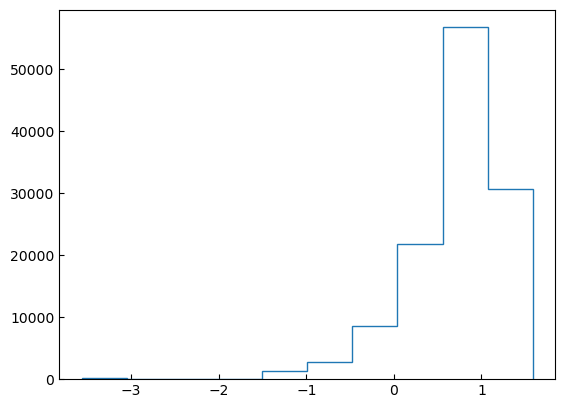

In [1473]:
plt.hist(np.log10(np.concatenate(true_exp_K)), histtype='step');

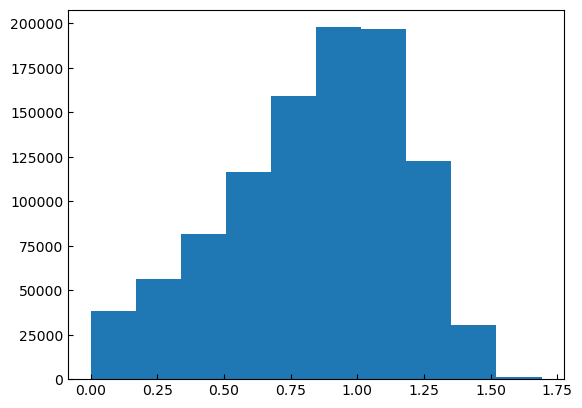

In [1484]:
from scipy.stats import truncnorm
plt.hist(np.log10(truncnorm.rvs(1e-12,1e6,loc=1,scale=np.sqrt(var),size=1000_000)));

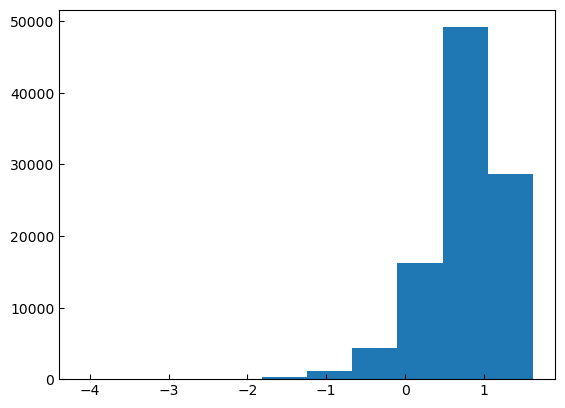

In [1485]:
from scipy.stats import truncnorm
mean=1
lower=1e-12
upper=1e6
var=100
size=100_000
samples_andi = truncnorm.rvs((lower-mean)/np.sqrt(var),
                                                (upper-mean)/np.sqrt(var),
                                                loc = mean,
                                                scale = np.sqrt(var),
                                                size = size)
plt.hist(np.log10(samples_andi));

In [1487]:
np.sum(samples_andi<0)

0

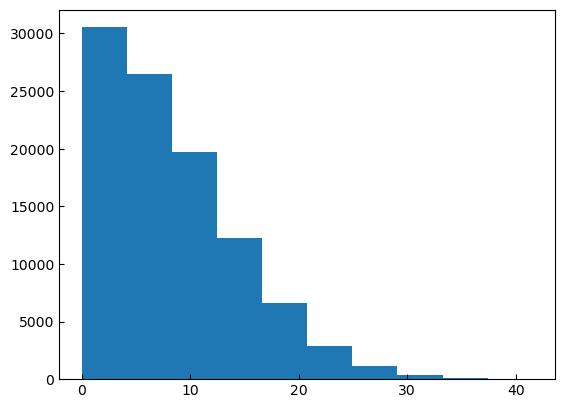

In [1488]:
plt.hist(samples_andi);

In [1151]:
exp=1
# load point
with np.load(path_exp/"point.npz", allow_pickle=True) as f:
    true_a=f['true_exp_a']; true_K=f['true_exp_K']; true_s=f['true_exp_s']
    true_d_cp=f['true_exp_d_cp']
    pred_a=f['pred_exp_a']; pred_K=f['pred_exp_K']; pred_s=f['pred_exp_s']

# load segment
with np.load(path_exp/"segment.npz", allow_pickle=True) as f:
    true_seg_a=f['true_exp_seg_a']; true_seg_K=f['true_exp_seg_K']
    true_seg_s=f['true_exp_seg_s']; true_cps_idx_=f['true_exp_cps_idx_']
    pred_seg_a=f['pred_exp_seg_a']; pred_seg_K=f['pred_exp_seg_K']
    pred_seg_s=f['pred_exp_seg_s']; pred_cps_idx_=f['pred_exp_cps_idx_']
pred_seg_cps = pred_cps_idx_

flat_true_d_cp = np.concatenate(true_d_cp)
pred_seg_restime = np.array([np.diff(np.concatenate(([0],cps+1)))
                              for cps in pred_seg_cps], dtype=object)

# metrics
error_a = np.array([pa-ta for (pa,ta) in zip(pred_a, true_a)], dtype=object)
flat_true_a  = np.concatenate(true_a)
flat_pred_a = np.concatenate(pred_a)
flat_error_a = flat_pred_a - flat_true_a

error_K = np.array([pa-ta for (pa,ta) in zip(pred_K, true_K)], dtype=object)
flat_true_K  = np.concatenate(true_K)
flat_pred_K = np.concatenate(pred_K)
flat_error_K = flat_pred_K - flat_true_K

error_s = np.array([np.argmax(pa,axis=-1)-ta for (pa,ta) in zip(pred_s, true_s)], dtype=object)
flat_true_s  = np.concatenate(true_s)
flat_pred_s = np.concatenate(pred_s)
flat_error_s = flat_pred_s - flat_true_s

error_seg_a = np.array([pa.repeat(pred_seg_restime[i])-ta for i,(pa,ta) in enumerate(zip(pred_seg_a, true_a))], dtype=object)
flat_pred_seg_a = np.concatenate([p.repeat(pred_seg_restime[i]) for i,p in enumerate(pred_seg_a)])
flat_error_seg_a = flat_pred_seg_a - flat_true_a

error_seg_K = np.array([pa.repeat(pred_seg_restime[i])-ta for i,(pa,ta) in enumerate(zip(pred_seg_K, true_K))], dtype=object)
flat_pred_seg_K = np.concatenate([p.repeat(pred_seg_restime[i]) for i,p in enumerate(pred_seg_K)])
flat_error_seg_K = flat_pred_seg_K - flat_true_K

flat_pred_seg_s = np.concatenate([p.repeat(pred_seg_restime[i]) for i,p in enumerate(pred_seg_s)])

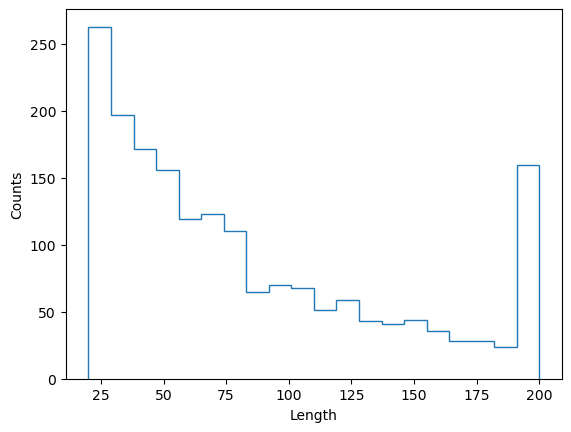

In [644]:
# plt.hist(lengths,20, histtype='step'); plt.gca().set(xlabel='Length', ylabel='Counts');
plt.hist([len(a) for a in pred_a] ,20, histtype='step'); plt.gca().set(xlabel='Length', ylabel='Counts');

## alpha

In [ ]:
i+=1
plt.plot(true_a[i]);
plt.plot(pred_a[i]);
plt.plot(pred_seg_a[i].repeat(pred_seg_restime[i]), label='seg pred');
# plt.plot(true_d_cp[i]);
# for cp in true_cps_idx_[i][:-1]: plt.axvline(cp+1);

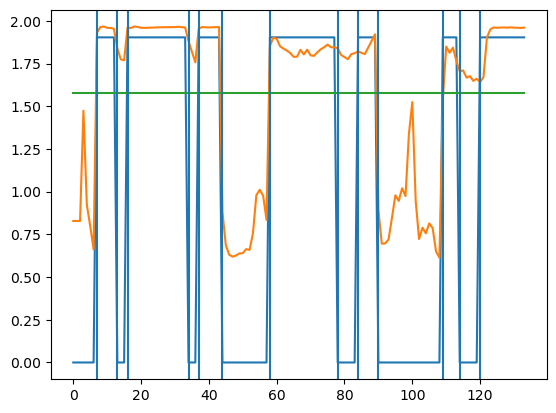

In [647]:
i=1
plt.plot(true_a[i]);
plt.plot(pred_a[i]);
plt.plot(pred_seg_a[i].repeat(pred_seg_restime[i]), label='seg pred');
# plt.plot(true_d_cp[i]);
for cp in true_cps_idx_[i][:-1]: plt.axvline(cp+1);

In [651]:
# k-worst alpha prediction
k = 4
mean_error_a = mse_a = np.array([e.mean()**2 for e in error_a])
k_worst_i = np.argpartition(mean_error_a, -k)[-k:]
k_worst_i = k_worst_i[np.argsort(mean_error_a[k_worst_i])][::-1]
k_worst_i, mean_error_a[k_worst_i]

(array([ 393, 1819,  410, 1168]),
 array([2.94702951, 1.90125079, 1.42374372, 1.26128574]))

In [652]:
# k-best alpha prediction
k_best_i = np.argpartition(mean_error_a, k)[:k]
k_best_i = k_best_i[np.argsort(mean_error_a[k_best_i])]
k_best_i, mean_error_a[k_best_i]

(array([491, 263, 979, 237]),
 array([3.10464847e-10, 5.84261687e-09, 9.58345002e-08, 5.45547024e-07]))

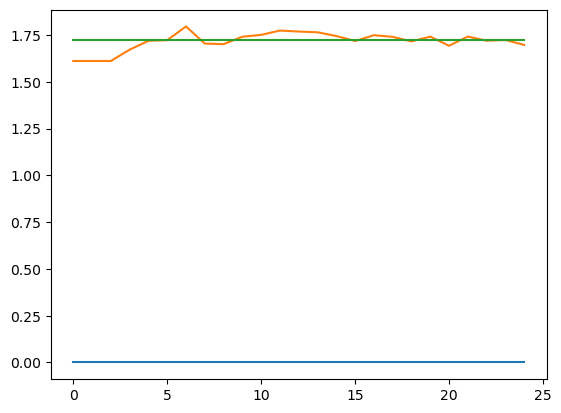

In [657]:
i=k_worst_i[0]
plt.plot(true_a[i]);
plt.plot(pred_a[i]);
plt.plot(pred_seg_a[i].repeat(pred_seg_restime[i]), label='seg pred');
# plt.plot(true_d_cp[i]);
for cp in true_cps_idx_[i][:-1]: plt.axvline(cp+1);

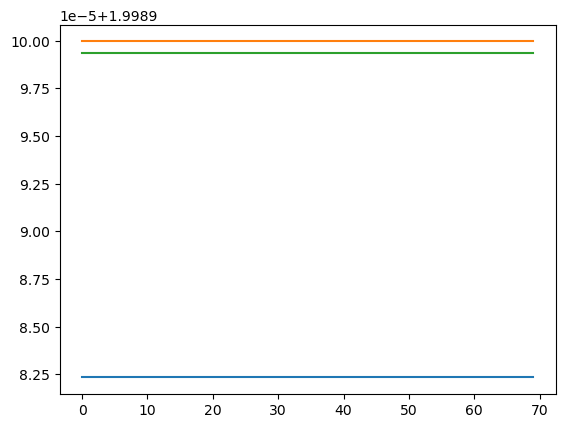

In [658]:
i=k_best_i[0]
plt.plot(true_a[i]);
plt.plot(pred_a[i]);
plt.plot(pred_seg_a[i].repeat(pred_seg_restime[i]), label='seg pred');
# plt.plot(true_d_cp[i]);
for cp in true_cps_idx_[i][:-1]: plt.axvline(cp+1);

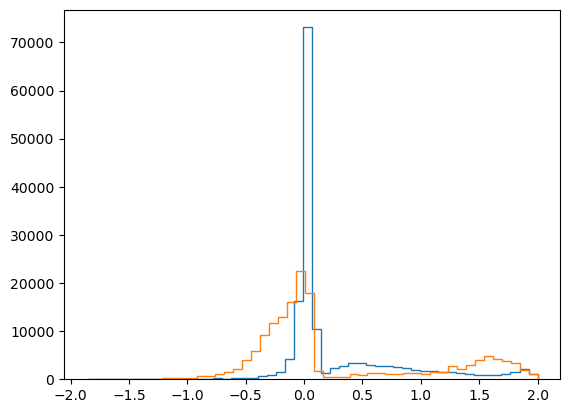

In [659]:
# error distribution
plt.hist(flat_error_a, 50, histtype='step');
plt.hist(flat_error_seg_a, 50, histtype='step');

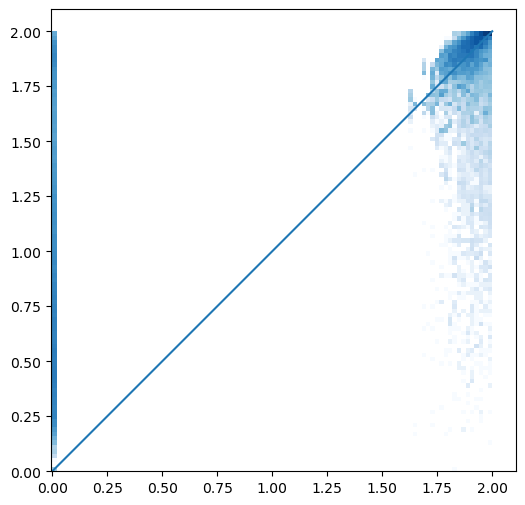

In [660]:
fig, ax = plt.subplots(figsize=(6,6))
plt.hist2d(flat_true_a,flat_pred_a, 100, cmap='Blues', norm='log');
plt.plot([0,2],[0,2]); plt.axis('equal');

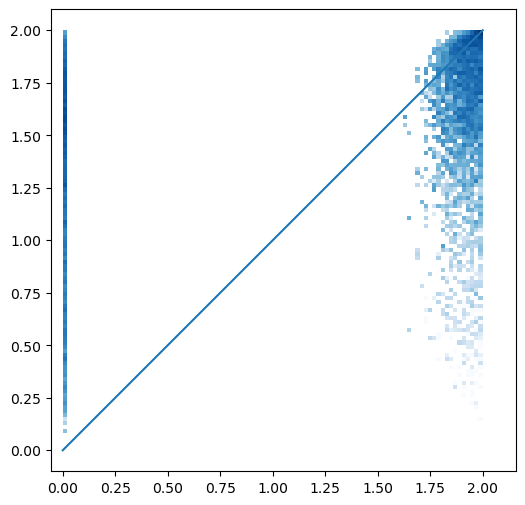

In [661]:
fig, ax = plt.subplots(figsize=(6,6))
plt.hist2d(flat_true_a,flat_pred_seg_a, 100, cmap='Blues', norm='log');
plt.plot([0,2],[0,2]); plt.axis('equal');

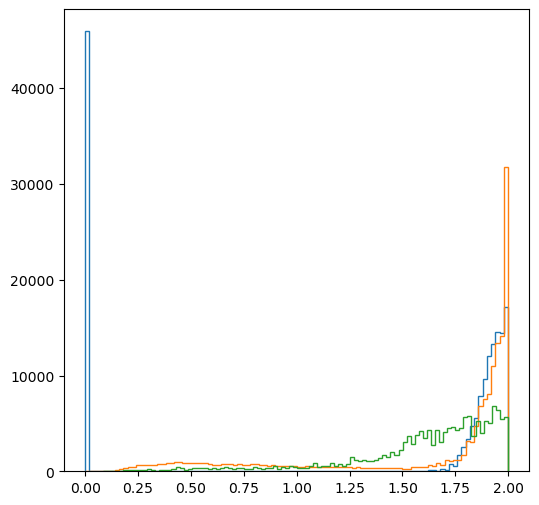

In [662]:
fig, ax = plt.subplots(figsize=(6,6))
plt.hist(flat_true_a,100, histtype='step')
plt.hist(flat_pred_a, 100, histtype='step');
plt.hist(flat_pred_seg_a, 100, histtype='step');

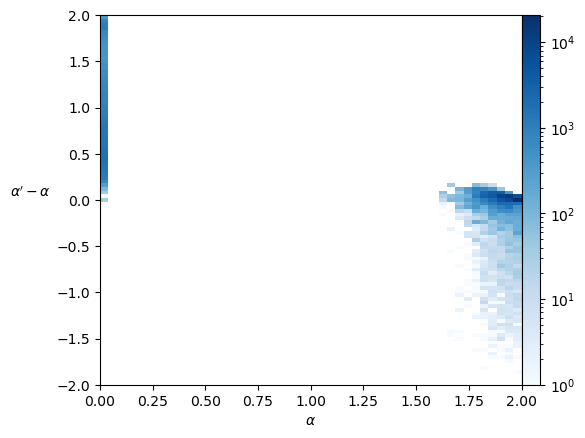

In [663]:
plt.hist2d(flat_true_a,flat_error_a, bins=[51,101], range=[[0,2],[-2,2]], cmap='Blues', norm='log');
plt.colorbar(pad=0);
plt.xlabel(r'$\alpha$'); plt.ylabel(r"$\alpha'-\alpha$", rotation=0, ha='right');

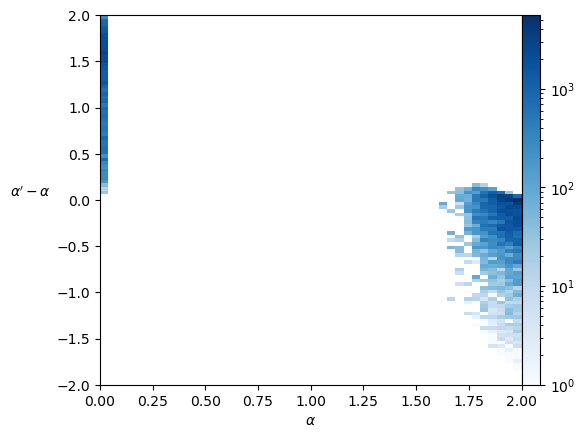

In [664]:
plt.hist2d(flat_true_a,flat_error_seg_a, bins=[51,101], range=[[0,2],[-2,2]], cmap='Blues', norm='log');
plt.colorbar(pad=0);
plt.xlabel(r'$\alpha$'); plt.ylabel(r"$\alpha'-\alpha$", rotation=0, ha='right');

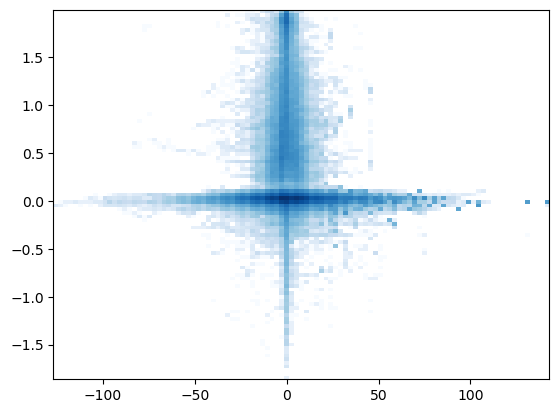

In [665]:
plt.hist2d(flat_true_d_cp,flat_error_a, 101, cmap='Blues', norm='log');

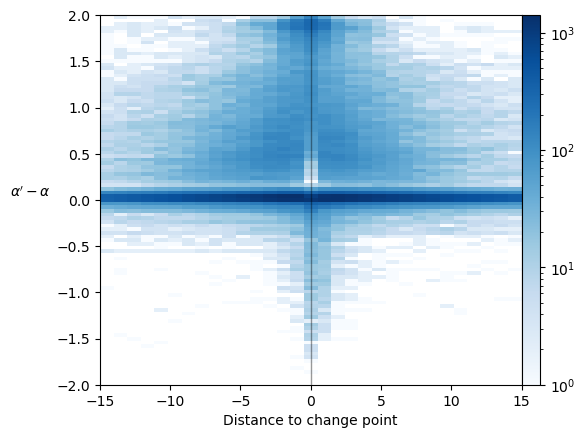

In [666]:
plt.hist2d(flat_true_d_cp,flat_error_a, bins=[31,101], range=[[-15,15],[-2,2]], cmap='Blues', norm='log');
plt.colorbar(pad=0); plt.axvline(0, c='k', lw=1, alpha=0.4);
plt.xlabel('Distance to change point'); plt.ylabel(r"$\alpha'-\alpha$", rotation=0, ha='right');

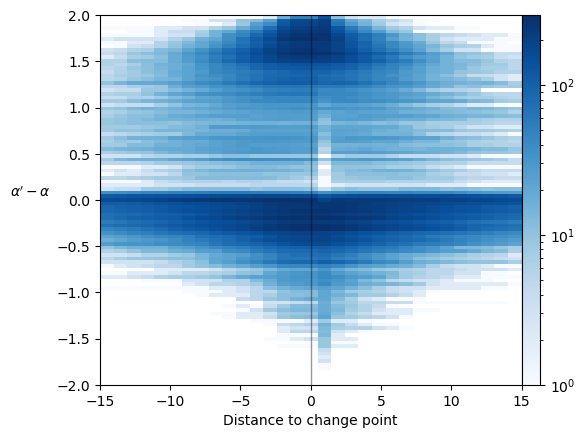

In [667]:
plt.hist2d(flat_true_d_cp,flat_error_seg_a, bins=[31,101], range=[[-15,15],[-2,2]], cmap='Blues', norm='log');
plt.colorbar(pad=0); plt.axvline(0, c='k', lw=1, alpha=0.4);
plt.xlabel('Distance to change point'); plt.ylabel(r"$\alpha'-\alpha$", rotation=0, ha='right');

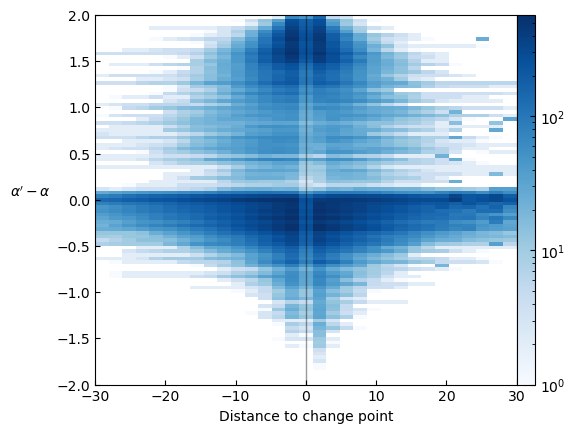

In [1437]:
plt.hist2d(flat_true_d_cp,flat_error_seg_a, bins=[31,101], range=[[-30,30],[-2,2]], cmap='Blues', norm='log');
plt.colorbar(pad=0); plt.axvline(0, c='k', lw=1, alpha=0.4);
plt.xlabel('Distance to change point'); plt.ylabel(r"$\alpha'-\alpha$", rotation=0, ha='right');

In [668]:
# MSE, MAE
print(np.mean(flat_error_a**2), np.mean(np.abs(flat_error_a)))
print(np.mean(flat_error_seg_a**2), np.mean(np.abs(flat_error_seg_a)))

0.3367775169558061 0.3101214552131537
0.6446213314450411 0.5358088546194792


## Generalized diffusion coefficient K

In [669]:
# k-worst K prediction
k = 4
mean_error_K = np.array([e.mean() for e in error_K])
k_worst_i = np.argpartition(mean_error_K, -k)[-k:]
k_worst_i = k_worst_i[np.argsort(mean_error_K[k_worst_i])][::-1]
k_worst_i, mean_error_K[k_worst_i]

(array([ 956,   79,  286, 1593]),
 array([120.0015378 , 113.56621373, 109.93336815, 108.14082978]))

In [670]:
# k-best K prediction
k = 4
k_best_i = np.argpartition(np.abs(mean_error_K), k)[:k]
k_best_i = k_best_i[np.argsort(mean_error_K[k_best_i])]
k_best_i, mean_error_K[k_best_i]

(array([ 751, 1548,  393, 1282]),
 array([3.16226784e-07, 3.16226784e-07, 3.16226784e-07, 3.16227725e-07]))

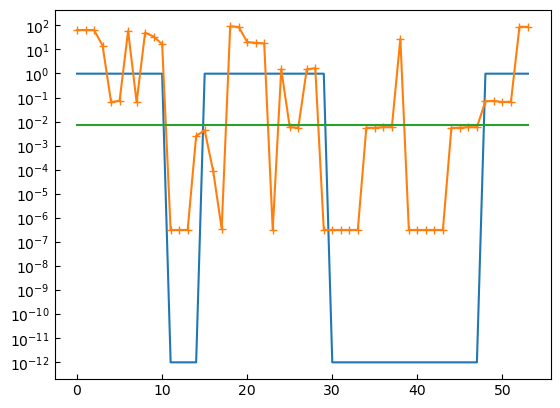

In [1518]:
i=0
plt.plot(true_K[i]);
plt.plot(pred_K[i],'+-');
plt.plot(pred_seg_K[i].repeat(pred_seg_restime[i]));
plt.yscale('symlog', linthresh=1e-12);

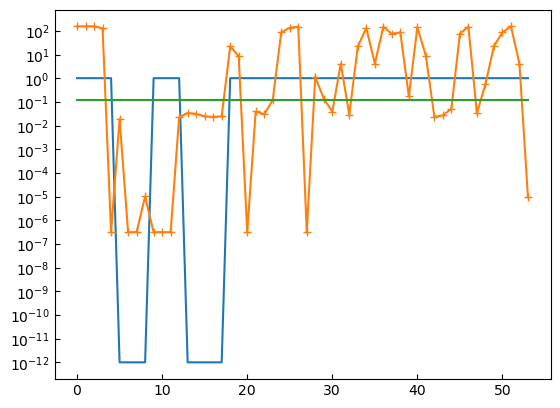

In [1559]:
i+=1
plt.plot(true_K[i]);
plt.plot(pred_K[i],'+-');
plt.plot(pred_seg_K[i].repeat(pred_seg_restime[i]));
plt.yscale('symlog', linthresh=1e-12);

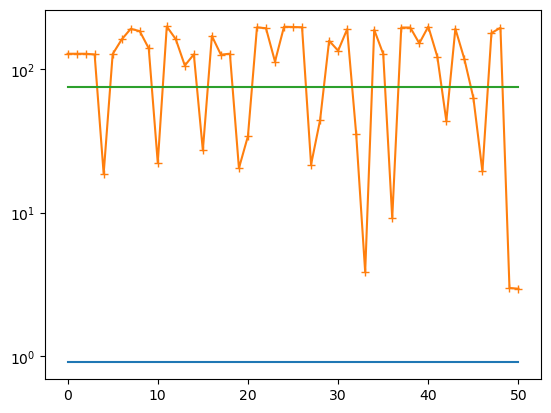

In [672]:
i=k_worst_i[0]
plt.plot(true_K[i]);
plt.plot(pred_K[i],'+-');
plt.plot(pred_seg_K[i].repeat(pred_seg_restime[i]));
plt.yscale('symlog', linthresh=1e-12);

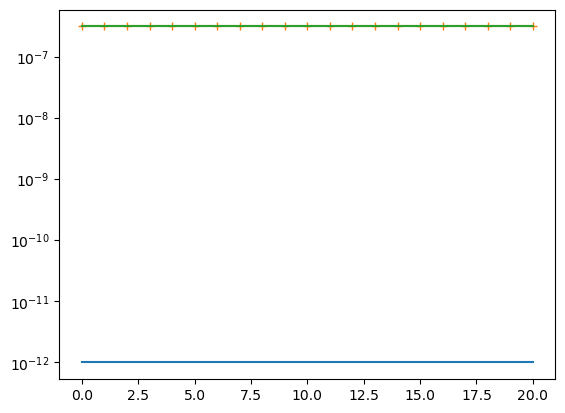

In [673]:
i=k_best_i[0]
plt.plot(true_K[i]);
plt.plot(pred_K[i],'+-');
plt.plot(pred_seg_K[i].repeat(pred_seg_restime[i]));
plt.yscale('symlog', linthresh=1e-12);

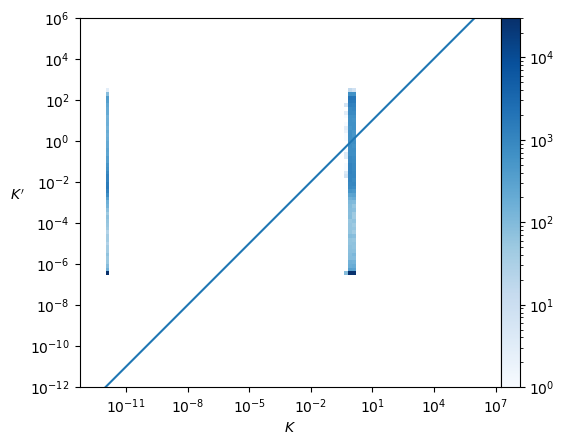

In [674]:
bins_K = np.geomspace(1e-12,1e6,100) #np.concatenate([[0],np.geomspace(1e-12,1e6,100)])
bins_K_sym = np.concatenate([-np.geomspace(1e6,1e-12,50),np.geomspace(1e-12,1e6,50)])
h = plt.hist2d(flat_true_K,flat_pred_K, bins=[bins_K,bins_K],  cmap='Blues', norm='log');
plt.gca().set_xscale('log'); plt.gca().set_yscale('log');
plt.xlabel(r'$K$'); plt.ylabel(r"$K'$", rotation=0, ha='right');
plt.plot([1e-12,1e6],[1e-12,1e6]); plt.axis('equal');
plt.colorbar(h[-1],pad=0);

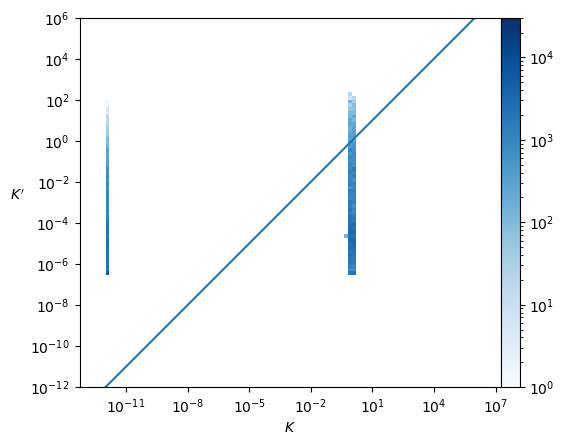

In [675]:
bins_K = np.geomspace(1e-12,1e6,100) #np.concatenate([[0],np.geomspace(1e-12,1e6,100)])
bins_K_sym = np.concatenate([-np.geomspace(1e6,1e-12,50),np.geomspace(1e-12,1e6,50)])
plt.hist2d(flat_true_K,flat_pred_seg_K, bins=[bins_K,bins_K],  cmap=h[-1].cmap, norm=h[-1].norm);
plt.gca().set_xscale('log'); plt.gca().set_yscale('log');
plt.xlabel(r'$K$'); plt.ylabel(r"$K'$", rotation=0, ha='right');
plt.plot([1e-12,1e6],[1e-12,1e6]); plt.axis('equal');
plt.colorbar(pad=0);

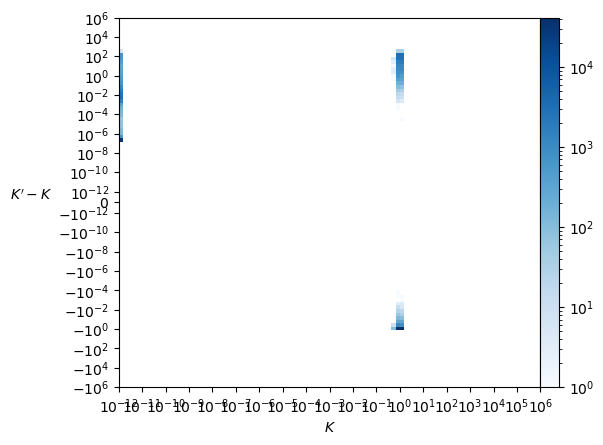

In [676]:
bins_K = np.geomspace(1e-12,1e6,100) #np.concatenate([[0],np.geomspace(1e-12,1e6,100)])
bins_K_sym = np.concatenate([-np.geomspace(1e6,1e-12,50),np.geomspace(1e-12,1e6,50)])
plt.hist2d(flat_true_K,flat_error_K, bins=[bins_K,bins_K_sym],  cmap='Blues', norm='log');
plt.gca().set_xscale('symlog', linthresh=1e-12);
plt.gca().set_yscale('symlog', linthresh=1e-12);
plt.colorbar(pad=0);
plt.xlabel(r'$K$'); plt.ylabel(r"$K'-K$", rotation=0, ha='right');

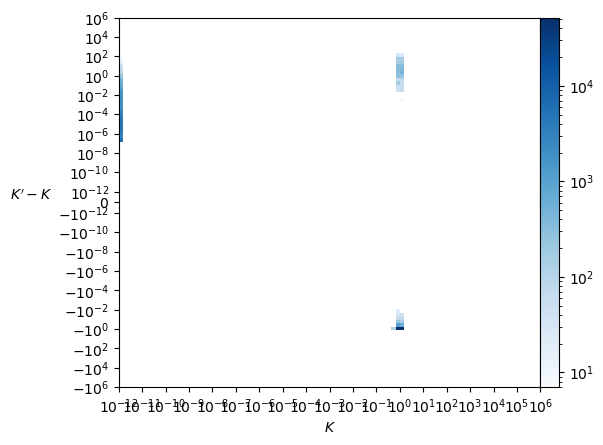

In [677]:
bins_K = np.geomspace(1e-12,1e6,100) #np.concatenate([[0],np.geomspace(1e-12,1e6,100)])
bins_K_sym = np.concatenate([-np.geomspace(1e6,1e-12,50),np.geomspace(1e-12,1e6,50)])
plt.hist2d(flat_true_K,flat_error_seg_K, bins=[bins_K,bins_K_sym],  cmap='Blues', norm='log');
plt.gca().set_xscale('symlog', linthresh=1e-12);
plt.gca().set_yscale('symlog', linthresh=1e-12);
plt.colorbar(pad=0);
plt.xlabel(r'$K$'); plt.ylabel(r"$K'-K$", rotation=0, ha='right');

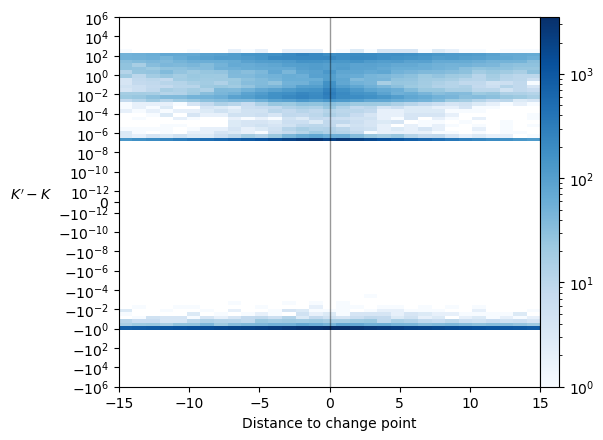

In [678]:
plt.hist2d(flat_true_d_cp,flat_error_K, bins=[31,bins_K_sym],  range=[[-15,15],None],cmap='Blues', norm='log');
plt.gca().set_yscale('symlog', linthresh=1e-12);
plt.colorbar(pad=0); plt.axvline(0, c='k', lw=1, alpha=0.4);
plt.xlabel('Distance to change point'); plt.ylabel(r"$K'-K$", rotation=0, ha='right');

In [679]:
flat_true_d_cp.shape, flat_error_seg_K.shape

((154517,), (154517,))

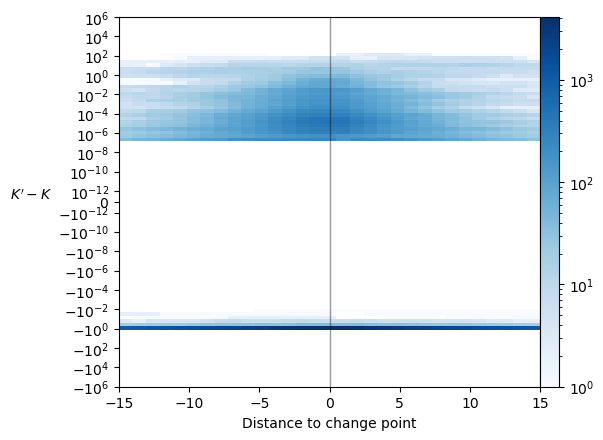

In [680]:
plt.hist2d(flat_true_d_cp,flat_error_seg_K, bins=[31,bins_K_sym],  range=[[-15,15],None],cmap='Blues', norm='log');
plt.gca().set_yscale('symlog', linthresh=1e-12);
plt.colorbar(pad=0); plt.axvline(0, c='k', lw=1, alpha=0.4);
plt.xlabel('Distance to change point'); plt.ylabel(r"$K'-K$", rotation=0, ha='right');

In [681]:
# squared logarithmic error for the generalized diffusion coefficient
flat_sle_K = (np.log(flat_pred_K+1) - np.log(flat_true_K+1))**2
flat_sle_seg_K = (np.log(flat_pred_seg_K+1) - np.log(flat_true_K+1))**2
# MSLE
print(np.mean(flat_sle_K), np.mean(flat_sle_seg_K))

1.7830971069039392 0.38351937930445257


In [682]:
# male
np.mean(np.abs(np.log(flat_pred_K/flat_true_K))), np.mean(np.abs(np.log(flat_pred_seg_K/flat_true_K)))

(11.65484434585982, 11.300153299405368)

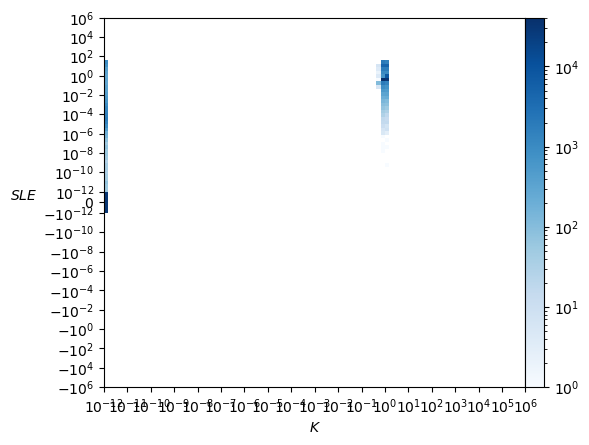

In [683]:
bins_K = np.geomspace(1e-12,1e6,100) #np.concatenate([[0],np.geomspace(1e-12,1e6,100)])
bins_K_sym = np.concatenate([-np.geomspace(1e6,1e-12,50),np.geomspace(1e-12,1e6,50)])
plt.hist2d(flat_true_K,flat_sle_K, bins=[bins_K,bins_K_sym],  cmap='Blues', norm='log');
plt.gca().set_xscale('symlog', linthresh=1e-12);
plt.gca().set_yscale('symlog', linthresh=1e-12);
plt.colorbar(pad=0);
plt.xlabel(r'$K$'); plt.ylabel(r"$SLE$", rotation=0, ha='right');

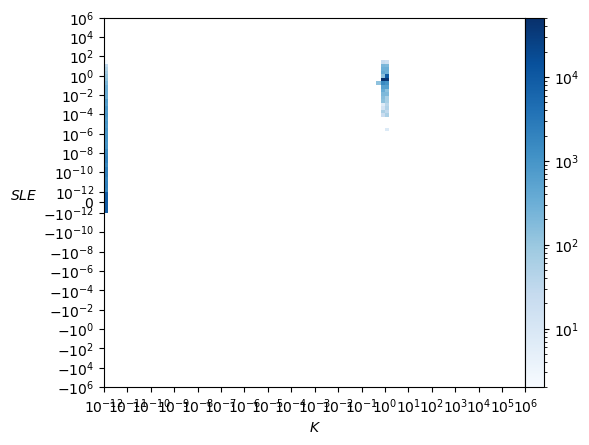

In [684]:
bins_K = np.geomspace(1e-12,1e6,100) #np.concatenate([[0],np.geomspace(1e-12,1e6,100)])
bins_K_sym = np.concatenate([-np.geomspace(1e6,1e-12,50),np.geomspace(1e-12,1e6,50)])
plt.hist2d(flat_true_K,flat_sle_seg_K, bins=[bins_K,bins_K_sym],  cmap='Blues', norm='log');
plt.gca().set_xscale('symlog', linthresh=1e-12);
plt.gca().set_yscale('symlog', linthresh=1e-12);
plt.colorbar(pad=0);
plt.xlabel(r'$K$'); plt.ylabel(r"$SLE$", rotation=0, ha='right');

## states

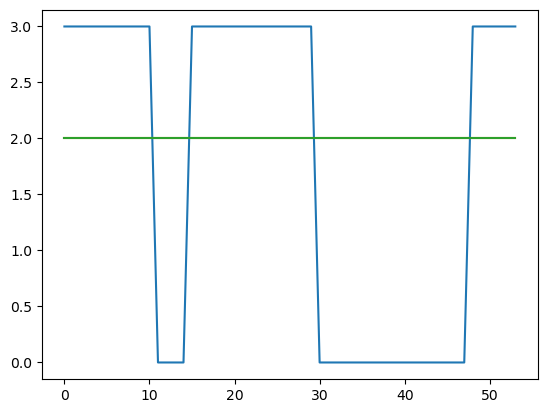

In [685]:
i=0
plt.plot(true_s[i]);
plt.plot(pred_s[i]);
plt.plot(pred_seg_s[i].repeat(pred_seg_restime[i]));

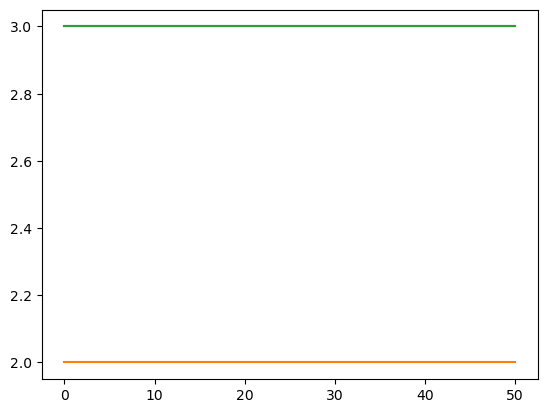

In [686]:
i=k_worst_i[0]
plt.plot(true_s[i]);
plt.plot(pred_s[i]);
plt.plot(pred_seg_s[i].repeat(pred_seg_restime[i]));

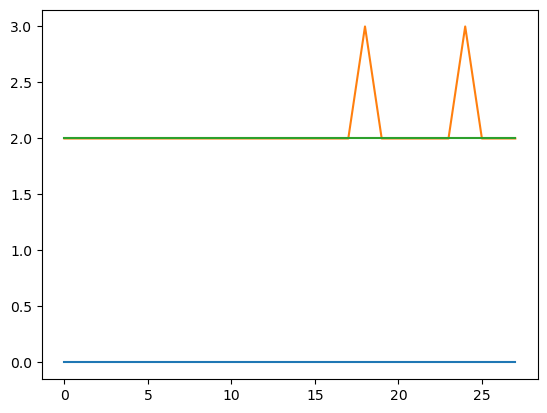

In [687]:
i=k_best_i[3]
plt.plot(true_s[i]);
plt.plot(pred_s[i]);
plt.plot(pred_seg_s[i].repeat(pred_seg_restime[i]));

In [688]:
# F1 states
from sklearn.metrics import f1_score
print(f1_score(flat_true_s, flat_pred_s, labels=np.arange(4), average='micro'))
print(f1_score(flat_true_s, flat_pred_s, labels=np.arange(4), average=None))

0.26281897784709773
[0.02032599 0.         0.39723962 0.0733584 ]


/home/gfernandez/miniforge3/envs/test2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [689]:
f1_trajs = [f1_score(ts, ps, labels=np.arange(4), average='micro')
            for (ts,ps) in zip(true_s, pred_s)]

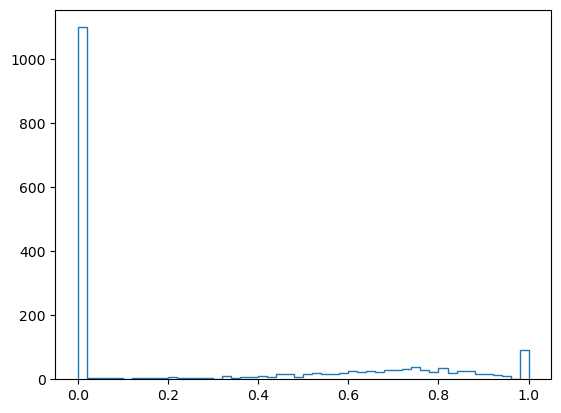

In [690]:
plt.hist(f1_trajs, 50, histtype='step');

In [691]:
# F1 states
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(flat_true_s, flat_pred_s, labels=np.arange(4)); cm

array([[  472,     0, 45135,   345],
       [    0,     0,     0,     0],
       [    5,     0, 37416,   228],
       [   14,     0, 68180,  2722]])

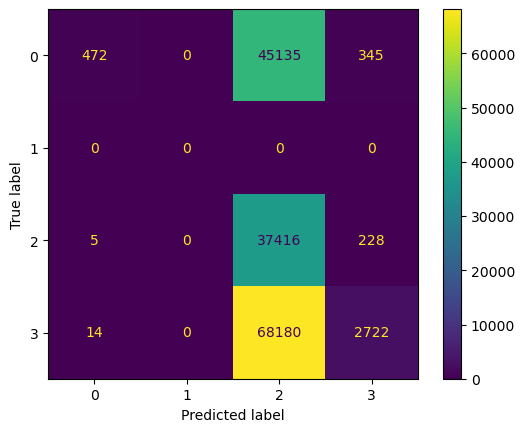

In [692]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=np.arange(4),)
disp.plot();

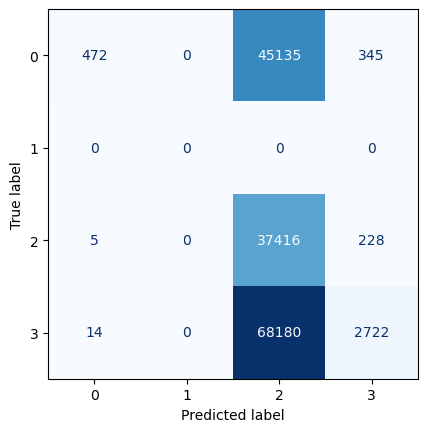

In [693]:
ConfusionMatrixDisplay.from_predictions(flat_true_s, flat_pred_s, labels=np.arange(4), colorbar=False, cmap='Blues');

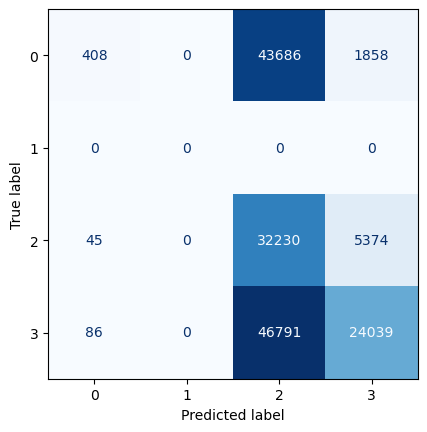

In [694]:
ConfusionMatrixDisplay.from_predictions(flat_true_s, flat_pred_seg_s, labels=np.arange(4), colorbar=False, cmap='Blues');

In [1249]:
true_s[-1].shape, pred_s[-1].shape

((105,), (105,))

  0%|          | 0/9 [00:00<?, ?it/s]

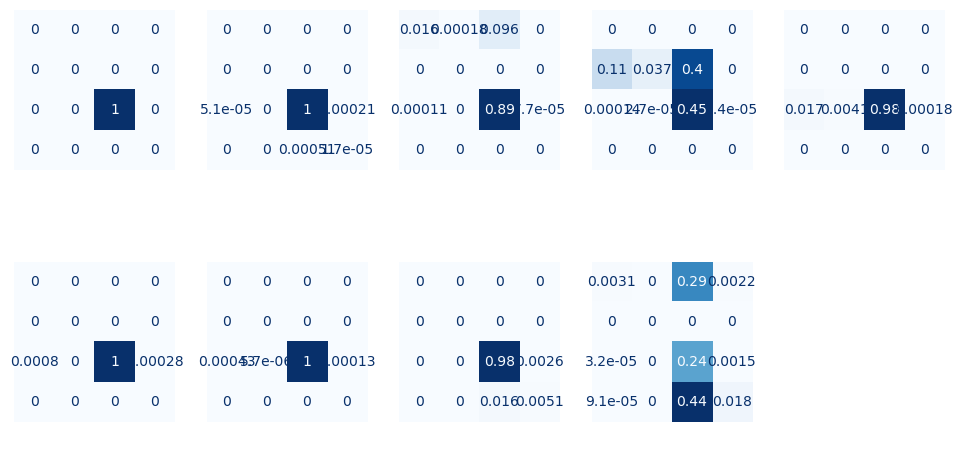

In [1256]:
fig,axs = plt.subplots(2,5, figsize=(12,6))
axs = axs.flatten()
# load point
for exp in trange(1,N_EXP+1):
    path_exp = path_results / f'track_{track}' / f'exp_{exp}'
    with np.load(path_exp/"point.npz", allow_pickle=True) as f:
        true_s=f['true_exp_s']
        pred_s=f['pred_exp_s']
        flat_true_s = np.concatenate(true_s)
        flat_pred_s = np.concatenate(pred_s)
        ConfusionMatrixDisplay.from_predictions(flat_true_s, flat_pred_s,
                                                labels=np.arange(4), ax=axs[exp-1],
                                                colorbar=False, cmap='Blues',normalize='all');
for ax in axs: ax.set_axis_off()

## Save metrics point-wise and plot

In [1163]:
from sklearn.metrics import mean_squared_log_error as msle, f1_score
path_results = path_analysis/ "benchmark"
track = 2
m_a, m_K, m_s = [], [], []
mae_a, msle_K, f1_s = [], [], []

# load point
for exp in trange(1,N_EXP+1):
    path_exp = path_results / f'track_{track}' / f'exp_{exp}'
    with np.load(path_exp/"point.npz", allow_pickle=True) as f:
        true_a=f['true_exp_a']; true_K=f['true_exp_K']; true_s=f['true_exp_s']
        # true_d_cp=f['true_exp_d_cp']
        pred_a=f['pred_exp_a']; pred_K=f['pred_exp_K']; pred_s=f['pred_exp_s']

    # metrics
    mae_a_traj = np.array([np.mean(np.abs(pa-ta)) for (pa,ta) in zip(pred_a, true_a)])
    mae_a_ = mae_a_traj.mean()

    msle_K_traj = np.array([msle(ta,pa) for (pa,ta) in zip(pred_K, true_K)])
    msle_K_ = msle_K_traj.mean()

    f1_s_traj = np.array([f1_score(ta.astype(int),pa.astype(int), average='micro')
                        for (pa,ta) in zip(pred_s, true_s)])
    f1_s_ = f1_score(np.concatenate(true_s).astype(int),
                    np.concatenate(pred_s).astype(int), average='micro')

    # if exp==8:
    #     true_cps_idx_ = np.stack(true_cps_idx_)[:,None]
    #     true_seg_a = true_seg_a[:,None]
    #     true_seg_K = true_seg_K[:,None]
    #     true_seg_s = true_seg_s[:,None]
    # metrics
    m_a.append(mae_a_traj); m_K.append(msle_K_traj); m_s.append(f1_s_traj)
    mae_a.append(mae_a_); msle_K.append(msle_K_); f1_s.append(f1_s_)

np.savez_compressed(path_results/'metrics_point',
                    m_a=np.array(m_a, dtype=object),
                    m_K=np.array(m_K, dtype=object),
                    m_s=np.array(m_s, dtype=object),
                    mae_a=np.array(mae_a),
                    msle_K=np.array(msle_K),
                    f1_s=np.array(f1_s))

  0%|          | 0/9 [00:00<?, ?it/s]

In [1366]:
with np.load(path_results/'metrics_point.npz', allow_pickle=True) as f:
    m_a=f['m_a']; m_K=f['m_K']; m_s=f['m_s']
    mae_a=f['mae_a']; msle_K=f['msle_K']; f1_s=f['f1_s']

  0%|          | 0/9 [00:00<?, ?it/s]

Saved ../../data/figures/MSLEK_vs_MAEalpha_point


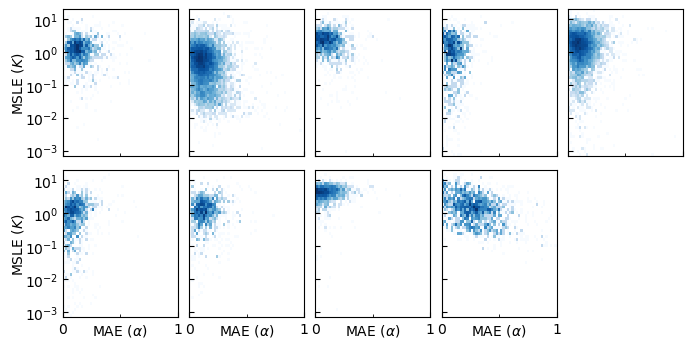

In [370]:
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

for exp in trange(N_EXP):
    m_a_, m_K_ = m_a[exp], m_K[exp]
    # mae_a_, msle_K_ = mae_a[exp], msle_K[exp]
    axs_K[exp].hist2d(m_a_, m_K_,bins=[51,np.geomspace(7e-4,20,51)],
                        range=[[0,1],None], cmap='Blues', norm='log')
for ax in axs_K[[0,5]]:
    ax.set_ylabel(r'MSLE $(K)$', labelpad=-1);
    ax.set_yticks([1e-2,10],[r'$10^{-2}',r'$10$'])
    ax.set_xticks([0,1],['0','1'])
for ax in axs_K:
    ax.tick_params(direction='in',); ax.set_yscale('log');
    ax.minorticks_off()

for ax in axs_K[-4:]:
    ax.set_xlabel(r'MAE $(\alpha)$', labelpad=-10);
    ax.set_xticks(ticks=[0.5], labels=[], minor=True)
save_plot("MSLEK_vs_MAEalpha_point", fig_K)

In [1450]:
true_a[0].shape, pred_a[0].shape

((200,), (200,))

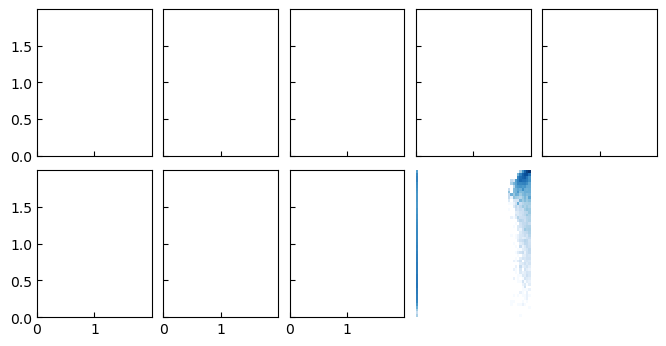

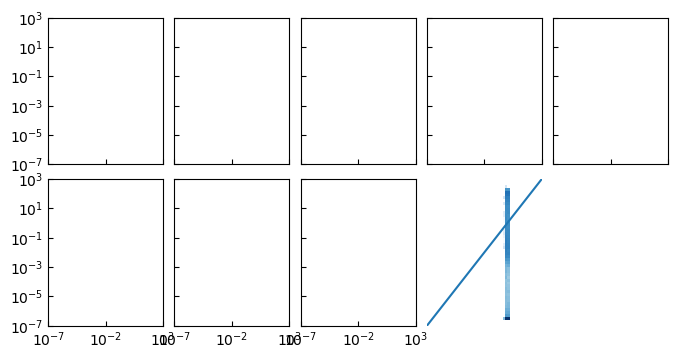

In [1967]:
path_results = path_analysis/ "benchmark"
track = 2

fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]

fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

# load point
for exp in [9]:#trange(1,N_EXP+1):
    path_exp = path_results / f'track_{track}' / f'exp_{exp}'
    with np.load(path_exp/"point.npz", allow_pickle=True) as f:
        true_a=f['true_exp_a']; true_K=f['true_exp_K']; true_s=f['true_exp_s']
        # true_d_cp=f['true_exp_d_cp']
        pred_a=f['pred_exp_a']; pred_K=f['pred_exp_K']; pred_s=f['pred_exp_s']

    axs_a[exp-1].hist2d(np.concatenate(true_a), np.concatenate(pred_a),bins=51, #range=[[0,1],None],
                        cmap='Blues', norm='log')
    axs_a[exp-1].set_axis_off()
    axs_K[exp-1].hist2d(np.concatenate(true_K), np.concatenate(pred_K),
                        bins=np.geomspace(1e-7,1e3,51), #range=[[0,1],None],
                        cmap='Blues', norm='log')
    axs_K[exp-1].plot([1e-12,1e6],[1e-12,1e6]);
    axs_K[exp-1].set_xscale('log'); axs_K[exp-1].set_yscale('log');
    axs_K[exp-1].set_axis_off()

In [1966]:
for exp in [9]: #trange(1,N_EXP+1):
    path_exp = path_results / f'track_{track}' / f'exp_{exp}'
    with np.load(path_exp/"segment.npz", allow_pickle=True) as f:
        true_seg_a=f['true_exp_seg_a']; true_seg_K=f['true_exp_seg_K']
        true_seg_s=f['true_exp_seg_s']; true_cps_idx_=f['true_exp_cps_idx_']
        pred_seg_a=f['pred_exp_seg_a']; pred_seg_K=f['pred_exp_seg_K']
        pred_seg_s=f['pred_exp_seg_s']; pred_cps_idx_=f['pred_exp_cps_idx_']
    pred_seg_cps = pred_cps_idx_
    if exp==8:
        true_cps_idx_ = np.stack(true_cps_idx_)[:,None]
        true_seg_a = true_seg_a[:,None]
        true_seg_K = true_seg_K[:,None]
        true_seg_s = true_seg_s[:,None]

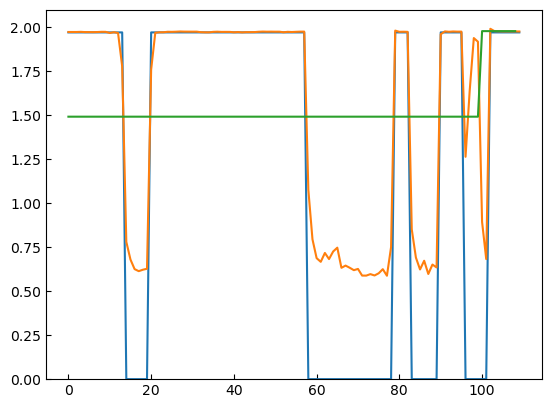

In [1968]:
i+=1;
plt.plot(true_a[i]);plt.plot(pred_a[i]); plt.ylim(0,2.1);
plt.plot(pred_seg_a[i].repeat(np.diff(np.concatenate((np.zeros(1,dtype=int),pred_cps_idx_[i])))));

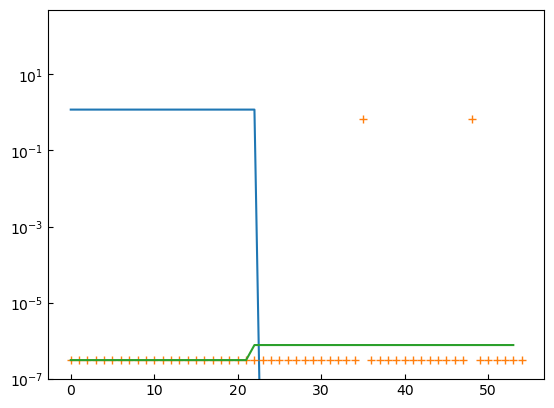

In [1969]:
i+=1;
plt.semilogy(true_K[i]);plt.plot(pred_K[i],'+'); plt.ylim(1e-7,5e2);
plt.plot(pred_seg_K[i].repeat(np.diff(np.concatenate((np.zeros(1,dtype=int),pred_cps_idx_[i])))));

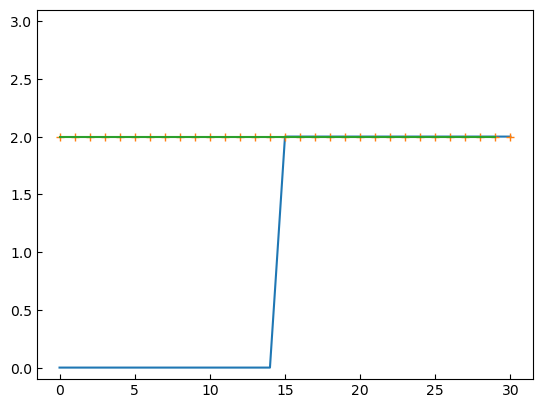

In [2041]:
i+=1;
plt.plot(true_s[i]);plt.plot(pred_s[i],'+'); plt.ylim(-0.1,3.1);
plt.plot(pred_seg_s[i].repeat(np.diff(np.concatenate((np.zeros(1,dtype=int),pred_cps_idx_[i])))));

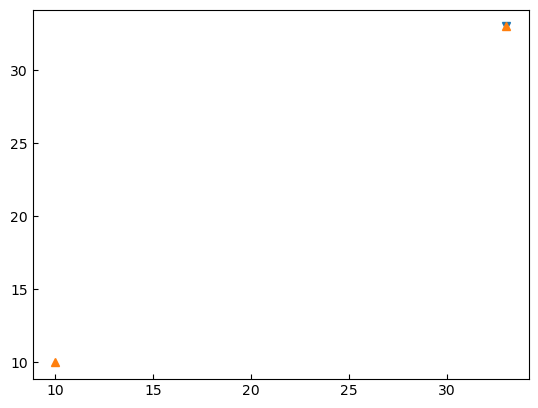

In [2106]:
i+=1;plt.plot(true_cps_idx_[i],true_cps_idx_[i], 'v');
plt.plot(pred_cps_idx_[i],pred_cps_idx_[i],'^');

  0%|          | 0/9 [00:00<?, ?it/s]

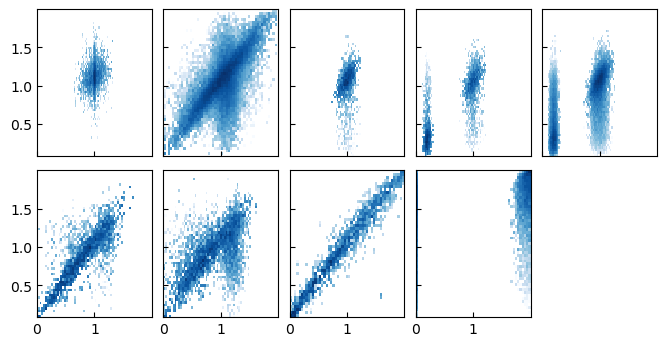

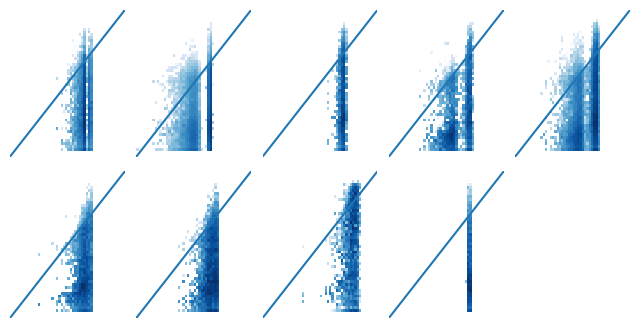

In [1517]:
# load segment
path_results = path_analysis/ "benchmark"
track = 2

fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove(); axs_a = axs_a.flatten()[:-1]

fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove(); axs_K = axs_K.flatten()[:-1]

for exp in trange(1,N_EXP+1):
    path_exp = path_results / f'track_{track}' / f'exp_{exp}'
    with np.load(path_exp/"segment.npz", allow_pickle=True) as f:
        true_seg_a=f['true_exp_seg_a']; true_seg_K=f['true_exp_seg_K']
        true_seg_s=f['true_exp_seg_s']; true_cps_idx_=f['true_exp_cps_idx_']
        pred_seg_a=f['pred_exp_seg_a']; pred_seg_K=f['pred_exp_seg_K']
        pred_seg_s=f['pred_exp_seg_s']; pred_cps_idx_=f['pred_exp_cps_idx_']
    pred_seg_cps = pred_cps_idx_
    if exp==8:
        true_cps_idx_ = np.stack(true_cps_idx_)[:,None]
        true_seg_a = true_seg_a[:,None]
        true_seg_K = true_seg_K[:,None]
        true_seg_s = true_seg_s[:,None]
    x = np.concatenate([true_seg_a[i].repeat(np.diff(np.concatenate((np.zeros(1, dtype=int),
                                                                     true_cps_idx_[i])))) for i in range(len(true_seg_a))])
    y = np.concatenate([pred_seg_a[i].repeat(np.diff(np.concatenate((np.zeros(1, dtype=int),
                                                                     pred_cps_idx_[i])))) for i in range(len(pred_seg_a))])
    axs_a[exp-1].hist2d(x,y,bins=51, #range=[[0,1],None],
                        cmap='Blues', norm='log')

    x = np.concatenate([true_seg_K[i].repeat(np.diff(np.concatenate((np.zeros(1, dtype=int),
                                                                     true_cps_idx_[i])))) for i in range(len(true_seg_K))])
    y = np.concatenate([pred_seg_K[i].repeat(np.diff(np.concatenate((np.zeros(1, dtype=int),
                                                                     pred_cps_idx_[i])))) for i in range(len(pred_seg_K))])
    axs_K[exp-1].hist2d(x,y,
                        bins=np.geomspace(1e-7,1e3,51), #range=[[0,1],None],
                        cmap='Blues', norm='log')
    axs_K[exp-1].plot([1e-12,1e6],[1e-12,1e6]);
    axs_K[exp-1].set_xscale('log'); axs_K[exp-1].set_yscale('log');
    axs_K[exp-1].set_axis_off()

In [1512]:
true_seg_a[0].repeat(np.diff(np.concatenate((np.zeros(1, dtype=int),true_cps_idx_[0])))).shape, pred_seg_a[0].repeat(np.diff(np.concatenate((np.zeros(1, dtype=int),pred_cps_idx_[0])))).shape

((199,), (199,))

In [1510]:
np.diff(np.concatenate((np.zeros(1, dtype=int),true_cps_idx_[0])))#.shape

array([ 3,  8, 44,  8, 22,  7,  6, 12, 33,  4, 24, 21,  7])

# Segment metrics with local score function

In [21]:
from andi_datasets.utils_challenge import run_single_task, listdir_nohidden

In [36]:
track=2
path_submit = '../../data/submit/20250203/res'
public_data_path = str(public_data_path)
exp_folders = sorted(list(listdir_nohidden(public_data_path+f'/track_{track}')))
exp_nums = [int(re.findall(r'\d+', name)[0]) for name in exp_folders]

In [37]:
exp_nums

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [40]:
out = run_single_task(exp_nums, track, path_submit, public_data_path)

In [41]:
out

([3.6090526312035816,
  0.22113934857515485,
  0.1981224598053357,
  0.43225699770466935,
  0.9179530137146839],
    Exp  num_trajs   RMSE CP    JSC CP     alpha         K     state
 0    1       1280  4.280723  0.151405  0.151035  0.166674  1.000000
 1    2       8983  4.037153  0.198683  0.160221  0.043252  0.998232
 2    3       1348  3.158938  0.255864  0.187944  0.463744  0.814219
 3    4       1192  3.309561  0.206295  0.158008  0.318170  0.599147
 4    5       6485  3.542504  0.259015  0.196207  0.357265  0.984009
 5    6       1172  4.567717  0.144548  0.147398  0.231864  0.998280
 6    7       1222  4.476668  0.185368  0.199399  0.259927  0.998803
 7    8       1524  0.000000  0.366400  0.107816  3.596420  0.975722
 8    9       1857  3.612483  0.182552  0.559034  0.452456  0.371010)

In [43]:
pd.set_option('display.float_format', '{:.3g}'.format)

In [58]:
scores = out[1]

In [59]:
scores.loc['mean'] = scores.mean()

In [139]:
scores

,Exp,num_trajs,RMSE CP,JSC CP,alpha,K,state
0,1,1.28e+03,4.28,0.151,0.151,0.167,1
1,2,8.98e+03,4.04,0.199,0.16,0.0433,0.998
2,3,1.35e+03,3.16,0.256,0.188,0.464,0.814
3,4,1.19e+03,3.31,0.206,0.158,0.318,0.599
4,5,6.48e+03,3.54,0.259,0.196,0.357,0.984
5,6,1.17e+03,4.57,0.145,0.147,0.232,0.998
6,7,1.22e+03,4.48,0.185,0.199,0.26,0.999
7,8,1.52e+03,0,0.366,0.108,3.6,0.976
8,9,1.86e+03,3.61,0.183,0.559,0.452,0.371
mean,5,2.78e+03,3.44,0.217,0.207,0.654,0.86


In [137]:
scores_repro = pd.DataFrame(data=np.array([rmse_cps_e, jsc_cps_e, m_exp_a, m_exp_K, m_exp_s]).T,columns=scores.columns[2:])
scores_repro.loc['mean'] = scores_repro.mean()

In [138]:
scores_repro

,RMSE CP,JSC CP,alpha,K,state
0,4.28,0.151,0.151,0.166,1
1,4.04,0.199,0.16,0.0432,0.998
2,3.16,0.256,0.189,0.463,0.813
3,3.31,0.206,0.159,0.318,0.6
4,3.54,0.259,0.196,0.357,0.984
5,4.57,0.145,0.148,0.232,0.998
6,4.48,0.185,0.199,0.26,0.999
7,0,0.366,0.108,3.6,0.976
8,3.61,0.183,0.563,0.451,0.369
mean,3.44,0.217,0.208,0.655,0.86


# Segment metrics

Jaccard similarity coefficient (JSC) over the whole experiment:

$JSC = \frac{TP}{TP + FN + FP}.$

That is a notion of the correct number of change points.

For the predicted CPs classified as true positives TP,
we also compute the root mean square error (RMSE), defined as:

$RMSE = \sqrt{\frac{1}{N}\sum (t_{(GT), i} - t_{(P), j})^2},$

where the sum is over the paired CP with a distance smaller than the threshold εCP.

The RMSE of the TP gives a notion of the distance from the predicted change point to the correct one.

In [70]:
thresholds = andi_datasets.utils_challenge._get_error_bounds()
threshold_error_alpha, threshold_error_D, threshold_error_s, threshold_cp, threshold_ensemble_alpha, threshold_ensemble_D = thresholds
thresholds

(2, 100000.0, 0, 10, 1.999, 1000000.0)

In [159]:
from andi_datasets.utils_challenge import jaccard_index

def single_changepoint_error_nolen(GT, preds, threshold=10):
    '''
    Given the groundtruth and predicted changepoints for a single trajectory,
    first handles the empty cases, i.e., when there a no change points,
    then, solves the assignment problem between changepoints,
    and returns the RMSE of the true positive pairs and the Jaccard index.
    
    Parameters
    ----------
    GT : list
        List of groundtruth change points.
    preds : list
        List of predicted change points.
    threshold : float
        Distance from which predictions are considered to have failed.
        They are then assigned this number in the RMSE.
    
    Returns
    -------
    tuple
        - TP_rmse: root mean square error of the true positive change points.
        - Jaccard Index of the ensemble predictions        
        
    '''
    if len(GT)==0:  # when there is no true_cp:
        if len(preds)==0:    return 0,1  # perfect RMSE, F1
        else:
            FP = len(preds)
            return min(FP,threshold), 0
    elif len(preds)==0:  # when there is one or more true_cp but preds is empty
        FN = len(GT)
        return min(FN,threshold), 0
    else: # there are one or more preds and true cps:
        assignment, _ = changepoint_assignment(GT, preds) # only if true_cp and pred_cp are non empty
        assignment = np.array(assignment)
        
        TP, FP, FN = 0, 0, 0
        TP_rmse = []
        for p in assignment.transpose():
            if np.abs(GT[p[0]] - preds[p[1]]) < threshold:
                TP += 1
                TP_rmse.append((GT[p[0]] - preds[p[1]])**2)
            else: # if the cp candidate is not in threshold
                # cp_candidate is a False Positive
                FP += 1
                # and the prediction missed a cp, hence, there is a False Negative
                FN += 1

        # Checking false positive and missed events
        if len(preds) > len(GT):
            FP += len(preds) - len(GT)
        elif len(preds) < len(GT):
            FN += len(GT) - len(preds)

        # Calculating RMSE
        TP_rmse = np.sqrt(np.mean(TP_rmse)) if len(TP_rmse) > 0 else threshold
        
        return TP_rmse, jaccard_index(TP, FP, FN)

In [ ]:
from andi_datasets.utils_challenge import single_changepoint_error, ensemble_changepoint_error, changepoint_assignment
from andi_datasets.utils_challenge import segment_property_errors, metric_anomalous_exponent, metric_diffusion_coefficient, metric_diffusive_state
# load segment
path_results = path_analysis/ "benchmark"
track = 2
N_EXP = 9 # 12
rmse_cps, jsc_cps = [], []
rmse_cps_e, jsc_cps_e = [], []
m_a, m_K, m_s = [], [], []
m_exp_a, m_exp_K, m_exp_s = [], [], []

for exp in trange(1,N_EXP+1):
    path_exp = path_results / f'track_{track}' / f'exp_{exp}'
    with np.load(path_exp/"segment.npz", allow_pickle=True) as f:
        true_seg_a=f['true_exp_seg_a']; true_seg_K=f['true_exp_seg_K']
        true_seg_s=f['true_exp_seg_s']; true_cps_idx_=f['true_exp_cps_idx_']
        pred_seg_a=f['pred_exp_seg_a']; pred_seg_K=f['pred_exp_seg_K']
        pred_seg_s=f['pred_exp_seg_s']; pred_cps_idx_=f['pred_exp_cps_idx_']
    # for ensemble change-point metrics takeout the length as in
    # https://github.com/AnDiChallenge/andi_datasets/blob/master/andi_datasets/utils_challenge.py#L1485
    if exp==8:
        true_cps_idx_ = np.stack(true_cps_idx_)[:,None]
        true_seg_a = true_seg_a[:,None]
        true_seg_K = true_seg_K[:,None]
        true_seg_s = true_seg_s[:,None]

    true_cps_idx = [t[:-1] for t in true_cps_idx_]
    pred_cps_idx = [p[:-1] for p in pred_cps_idx_]
    # metrics
    paired_seg_a, paired_seg_K, paired_seg_s = zip(*[segment_property_errors(
                true_cps_idx_[i], true_seg_a[i], true_seg_K[i], true_seg_s[i],
                pred_cps_idx_[i], pred_seg_a[i], pred_seg_K[i], pred_seg_s[i],return_pairs=True)
                for i in trange(len(true_seg_a))])
    m_exp_a.append(metric_anomalous_exponent(*np.concatenate(paired_seg_a).T)) # mean over the whole experiment
    m_exp_K.append(metric_diffusion_coefficient(*np.concatenate(paired_seg_K).T))
    m_exp_s.append(metric_diffusive_state(*np.concatenate(paired_seg_s).T))
    # mean over each trajectory
    m_seg_a, m_seg_K, m_seg_s = zip(*[segment_property_errors(
                true_cps_idx_[i], true_seg_a[i], true_seg_K[i], true_seg_s[i],
                pred_cps_idx_[i], pred_seg_a[i], pred_seg_K[i], pred_seg_s[i])
                for i in trange(len(true_seg_a))])
    # cps
    # single-trajectory RMSE, JSC
    TP_rmse, JSC = zip(*[single_changepoint_error_nolen(true_cps_, seg_cps_, threshold=threshold_cp) # without length
                         # single_changepoint_error(true_cps_, seg_cps_, threshold=threshold_cp) # with length
                         # for true_cps_, seg_cps_ in zip(true_cps_idx_, pred_cps_idx_)])
                         for true_cps_, seg_cps_ in zip(true_cps_idx, pred_cps_idx)])
    # ensemble RMSE, JSC
    TP_rmse_e, JSC_e = ensemble_changepoint_error(true_cps_idx, pred_cps_idx, threshold=threshold_cp);

    rmse_cps.append(TP_rmse); jsc_cps.append(JSC)
    rmse_cps_e.append(TP_rmse_e); jsc_cps_e.append(JSC_e)
    m_a.append(m_seg_a); m_K.append(m_seg_K); m_s.append(m_seg_s)

In [164]:
np.savez_compressed(path_results/'metrics_segments',
                    rmse_cps=np.array(rmse_cps, dtype=object),
                    jsc_cps=np.array(jsc_cps, dtype=object),
                    rmse_cps_e=np.array(rmse_cps_e, dtype=object),
                    jsc_cps_e=np.array(jsc_cps_e, dtype=object),
                    m_a=np.array(m_a, dtype=object),
                    m_K=np.array(m_K, dtype=object),
                    m_s=np.array(m_s, dtype=object),
                    m_exp_a=np.array(m_exp_a, dtype=object),
                    m_exp_K=np.array(m_exp_K, dtype=object),
                    m_exp_s=np.array(m_exp_s, dtype=object))

In [508]:
from andi_datasets.utils_challenge import single_changepoint_error, ensemble_changepoint_error, changepoint_assignment

In [695]:
# single-trajectory RMSE, JSC
TP_rmse, JSC = zip(*[single_changepoint_error(true_cps_, seg_cps_,)
                    for true_cps_, seg_cps_ in zip(true_cps_idx_, pred_seg_cps)])

In [696]:
# ensemble RMSE, JSC
TP_rmse_e, JSC_e = ensemble_changepoint_error(true_cps_idx_, pred_seg_cps); TP_rmse_e, JSC_e

(1.138143793802565, 0.27245508982035926)

In [2109]:
true_cps_idx_, pred_seg_cps

(array([array([10, 14, 29, 47, 53]),
        array([  6,  12,  15,  33,  36,  43,  57,  77,  83,  89, 108, 113, 119,
               133])                                                           ,
        array([ 5,  8, 20, 26]), ..., array([ 6, 20, 25, 53]), array([28]),
        array([ 27,  31,  37,  46,  68,  73,  88, 107, 140])], dtype=object),
 array([array([53]), array([133]), array([26]), ..., array([24, 53]),
        array([28]), array([ 10, 125, 140])], dtype=object))

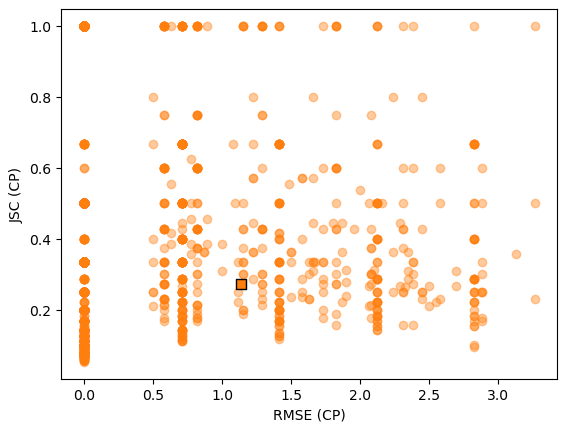

In [697]:
plt.scatter(TP_rmse, JSC, c = 'C1', alpha = 0.4)
plt.scatter(TP_rmse_e, JSC_e , c = 'C1', s = 50, marker = 's', edgecolors = 'k')
plt.setp(plt.gca(), xlabel = 'RMSE (CP)', ylabel = 'JSC (CP)');
#plt.gca().invert_xaxis()

In [361]:
with np.load(path_results/'metrics_segments.npz', allow_pickle=True) as f:
    rmse_cps=f['rmse_cps'];     jsc_cps=f['jsc_cps']
    rmse_cps_e=f['rmse_cps_e']; jsc_cps_e=f['jsc_cps_e']
    m_seg_a=f['m_a']; m_seg_K=f['m_K']; m_seg_s=f['m_s']

  0%|          | 0/9 [00:00<?, ?it/s]

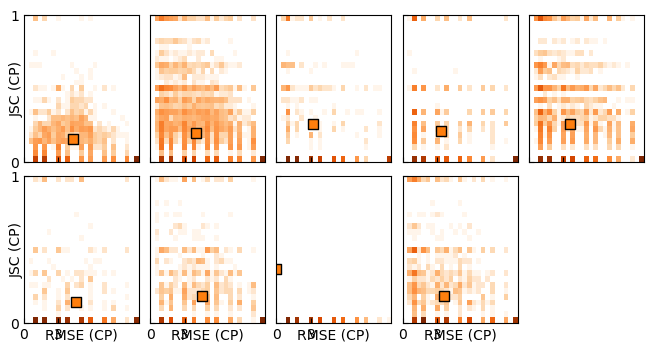

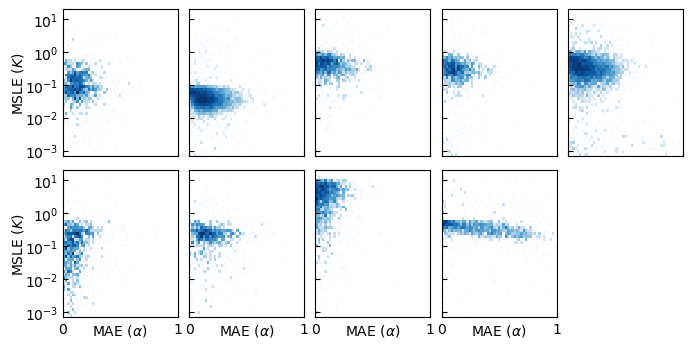

In [362]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

for exp in trange(N_EXP):
    rmse_cps_, jsc_cps_, rmse_cps_e_, jsc_cps_e_ = rmse_cps[exp], jsc_cps[exp], rmse_cps_e[exp], jsc_cps_e[exp]
    m_seg_a_, m_seg_K_ = m_seg_a[exp], m_seg_K[exp]
    # axs_a[exp].scatter(rmse_cps_,jsc_cps_, c='C1', alpha=0.2)
    axs_a[exp].hist2d(rmse_cps_,jsc_cps_, 25, range=[[0.01,10],[0,1]], cmap='Oranges', norm='log')
    axs_a[exp].scatter(rmse_cps_e_,jsc_cps_e_, c='C1', s=50, marker='s', edgecolors='k')
    axs_K[exp].hist2d(m_seg_a_, m_seg_K_,bins=[51,np.geomspace(7e-4,20,51)],
                        range=[[0,1],None], cmap='Blues', norm='log')
for ax in axs_a[[0,5]]:
    ax.set_ylabel('JSC (CP)', labelpad=-10); #rotation=0, );
    ax.set_yticks([0,1],['0','1'])
    ax.set_xticks([0,3],['0','3'])
for ax in axs_K[[0,5]]:
    ax.set_ylabel(r'MSLE $(K)$', labelpad=-1);
    ax.set_xticks([0,1],['0','1'])
for ax in axs_a[-4:]: ax.set_xlabel('RMSE (CP)', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'MAE $(\alpha)$', labelpad=-10);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',); ax.set_yscale('log');
    ax.minorticks_off()

# save_plot("JSCCP_vs_RMSECP_segment", fig_a)
# save_plot("MSLEK_vs_MAEalpha_segment", fig_K)

  0%|          | 0/9 [00:00<?, ?it/s]

Saved ../../data/figures/JSCCP_vs_RMSECP_segment
Saved ../../data/figures/MSLEK_vs_MAEalpha_segment


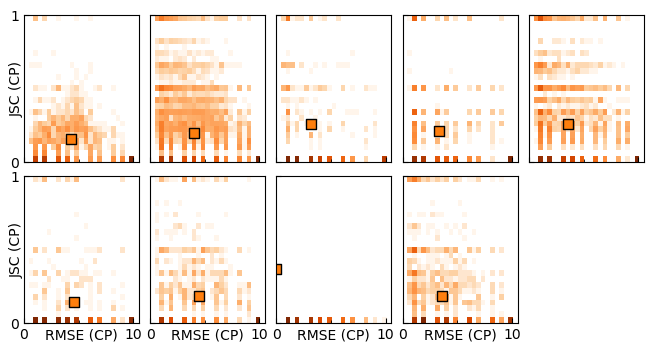

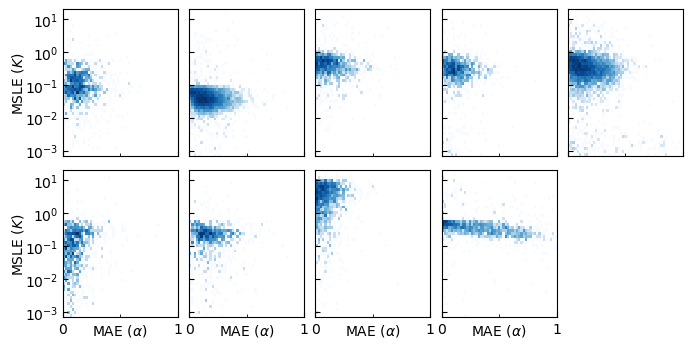

In [369]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

for exp in trange(N_EXP):
    rmse_cps_, jsc_cps_, rmse_cps_e_, jsc_cps_e_ = rmse_cps[exp], jsc_cps[exp], rmse_cps_e[exp], jsc_cps_e[exp]
    m_seg_a_, m_seg_K_ = m_seg_a[exp], m_seg_K[exp]
    # axs_a[exp].scatter(rmse_cps_,jsc_cps_, c='C1', alpha=0.2)
    axs_a[exp].hist2d(rmse_cps_,jsc_cps_, 25, range=[[0.01,10.5],[0,1]], cmap='Oranges', norm='log')
    axs_a[exp].scatter(rmse_cps_e_,jsc_cps_e_, c='C1', s=50, marker='s', edgecolors='k')
    axs_K[exp].hist2d(m_seg_a_, m_seg_K_,bins=[51,np.geomspace(7e-4,20,51)],
                        range=[[0,1],None], cmap='Blues', norm='log')
for ax in axs_a[[0,5]]:
    ax.set_ylabel('JSC (CP)', labelpad=-10); #rotation=0, );
    ax.set_yticks([0,1],['0','1'])
    ax.set_xticks([0,10],['0','10'])
for ax in axs_K[[0,5]]:
    ax.set_ylabel(r'MSLE $(K)$', labelpad=-1);
    ax.set_xticks([0,1],['0','1'])
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',); ax.set_yscale('log');
    ax.minorticks_off()
for ax in axs_a[-4:]:
    ax.set_xlabel('RMSE (CP)', labelpad=-10);
    ax.set_xticks(ticks=[5], labels=[], minor=True)
for ax in axs_K[-4:]:
    ax.set_xlabel(r'MAE $(\alpha)$', labelpad=-10);
    ax.set_xticks(ticks=[0.5], labels=[], minor=True)

#save_plot("JSCCP_vs_RMSECP_segment", fig_a)
#save_plot("MSLEK_vs_MAEalpha_segment", fig_K)

In [322]:
from andi_datasets.utils_challenge import segment_property_errors

In [551]:
segment_property_errors??

Signature:
segment_property_errors(
    GT_cp,
    GT_alpha,
    GT_D,
    GT_s,
    preds_cp,
    preds_alpha,
    preds_D,
    preds_s,
    return_pairs=False,
    T=None,
)
Source:   
def segment_property_errors(GT_cp, GT_alpha, GT_D, GT_s,
                            preds_cp, preds_alpha, preds_D, preds_s,
                            return_pairs = False,
                            T = None):
    '''
    Given predicionts over change points and the value of diffusion parameters in the generated
    segments, computes the defined metrics.
    
    Parameters
    ----------
    GT_cp : list, int, float
        Groundtruth change points
    GT_alpha : list, float
        Groundtruth anomalous exponent
    GT_D : list, float
        Groundtruth diffusion coefficient
    GT_s : list, float
        Groundtruth diffusive state
    preds_cp : list, int, float
        Predicted change points
    preds_alpha : list, float
        Predicted anomalous exponent
    preds_D : list, float
     

In [553]:
true_cps_idx_[i].shape, true_a[i][true_cps_idx_[i]].shape, pred_seg_cps[i].shape, pred_seg_a[i].shape

((5,), (5,), (1,), (1,))

In [698]:
m_seg_a, m_seg_K, m_seg_s = zip(*[segment_property_errors(true_cps_idx_[i], true_seg_a[i], true_seg_K[i], true_seg_s[i],
                                        pred_seg_cps[i], pred_seg_a[i], pred_seg_K[i], pred_seg_s[i],)
                    for i in trange(len(true_seg_a))])

  0%|          | 0/1857 [00:00<?, ?it/s]

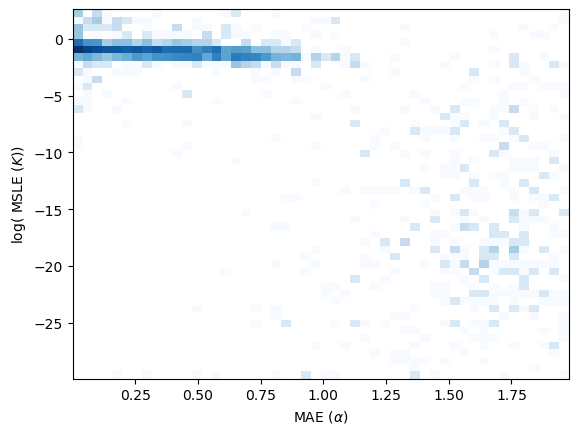

In [701]:
plt.hist2d(m_seg_a, np.log(m_seg_K), 50, cmap='Blues', norm='log');
plt.xlabel(r'MAE ($\alpha$)'); plt.ylabel(r'$\log($ MSLE $(K))$');
#plt.gca().invert_xaxis(); plt.gca().invert_yaxis();

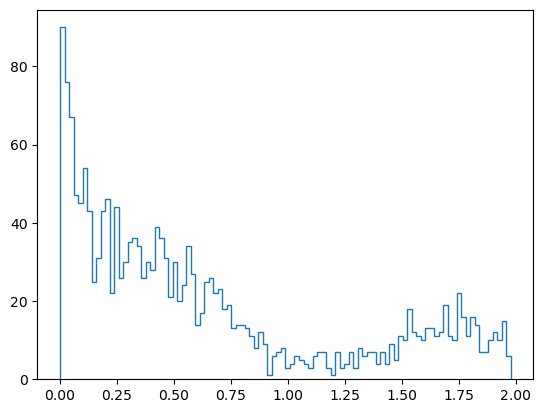

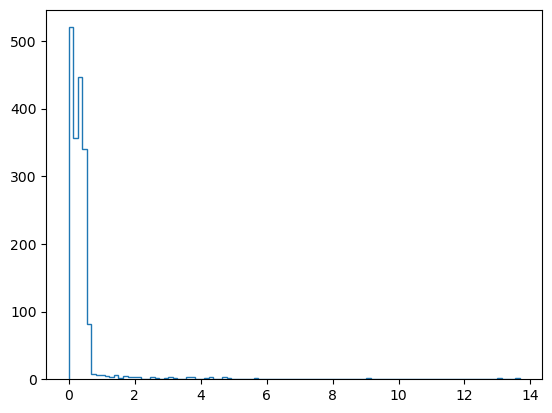

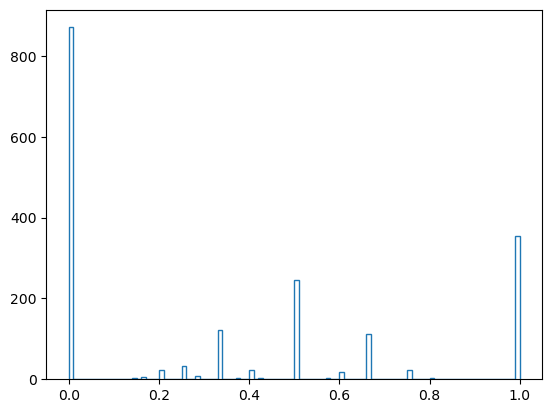

In [700]:
for m in [m_seg_a, m_seg_K, m_seg_s]:
    plt.figure();plt.hist(m,100, histtype='step');

## Comparison point vs segment and ensemble across experiments

In [331]:
path_results = path_analysis/ "benchmark"

In [332]:
with np.load(path_results/'metrics_point.npz', allow_pickle=True) as f:
    m_a=f['m_a']; m_K=f['m_K']; m_s=f['m_s']
    mae_a=f['mae_a']; msle_K=f['msle_K']; f1_s=f['f1_s']

In [333]:
with np.load(path_results/'metrics_segments.npz', allow_pickle=True) as f:
    rmse_cps=f['rmse_cps'];     jsc_cps=f['jsc_cps']
    rmse_cps_e=f['rmse_cps_e']; jsc_cps_e=f['jsc_cps_e']
    m_seg_a=f['m_a']; m_seg_K=f['m_K']; m_seg_s=f['m_s']
    m_exp_a=f['m_exp_a']; m_exp_K=f['m_exp_K']; m_exp_s=f['m_exp_s']

In [334]:
with np.load(path_results/"metrics_ensemble.npz", allow_pickle=True) as f:
    w1_a=f['w1_a']; w1_K=f['w1_K']; dists=f['dists']

In [335]:
plt.rcParams.update({
    # 'axes.spines.right':False,
    # 'axes.spines.top':  False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    })

  0%|          | 0/9 [00:00<?, ?it/s]

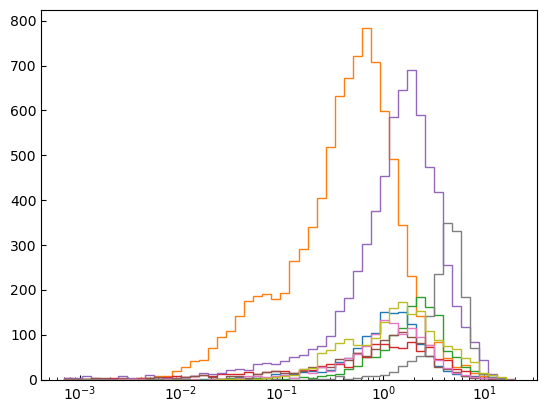

In [1237]:
for exp in trange(N_EXP):
    # point
    plt.hist(m_K[exp],np.geomspace(7e-4,20,51), histtype='step',); # not well computed density in logspace
plt.xscale('log')

  0%|          | 0/9 [00:00<?, ?it/s]

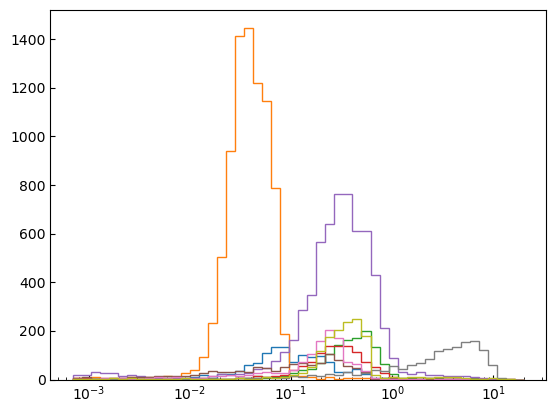

In [1241]:
for exp in trange(N_EXP):
    # point
    plt.hist(m_seg_K[exp],np.geomspace(7e-4,20,51), histtype='step',); # not well computed density in logspace
plt.xscale('log')

  0%|          | 0/9 [00:00<?, ?it/s]

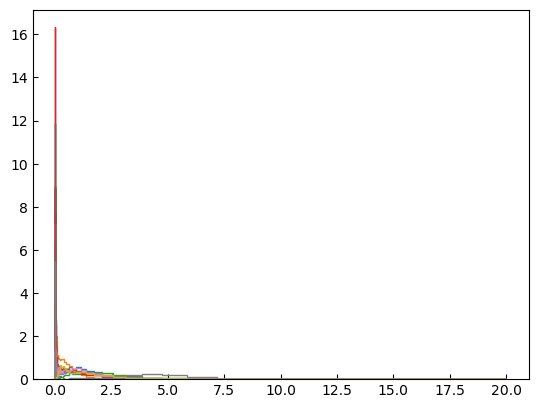

In [1235]:
for exp in trange(N_EXP):
    # point
    plt.hist(m_K[exp],np.geomspace(7e-4,20,51), histtype='step', density=True); # not well computed density in logspace

  0%|          | 0/9 [00:00<?, ?it/s]

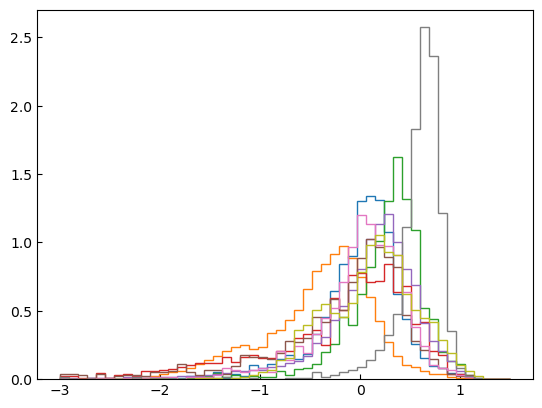

In [1238]:
for exp in trange(N_EXP):
    # point
    plt.hist(np.log10(m_K[exp]),np.linspace(-3,1.5,51), histtype='step', density=True); # not well computed density in logspace

  0%|          | 0/9 [00:00<?, ?it/s]

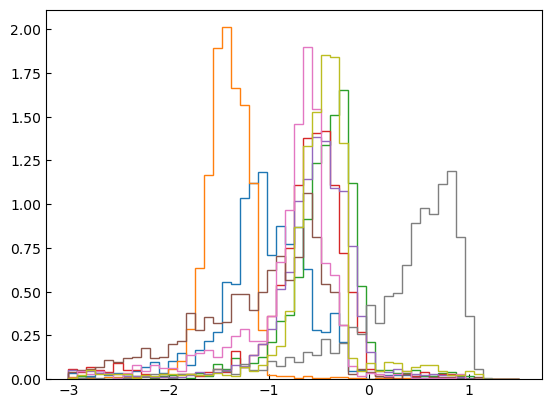

In [1240]:
for exp in trange(N_EXP):
    # point
    plt.hist(np.log10(m_seg_K[exp]),np.linspace(-3,1.5,51), histtype='step', density=True); # not well computed density in logspace

  0%|          | 0/9 [00:00<?, ?it/s]

Saved ../../data/figures/RMSECP_JSCCP_W1alpha_W1K_segment


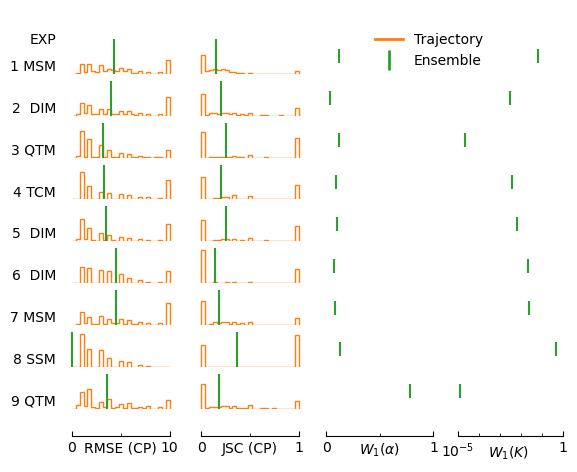

In [421]:
fig,axs = plt.subplots(9,4,sharex='col', sharey='col')
from matplotlib.lines import Line2D
exp_model = ["MSM", " DIM", "QTM", "TCM", " DIM", " DIM","MSM","SSM","QTM"]
legend_h = [
            # Line2D([0], [0], color='C2', marker='o',lw=0, label='Ensemble',),
            Line2D([0], [0], color='C1', lw=2, label='Trajectory',),
            Line2D([0], [0], color='C2', marker='|', ms=15, markeredgewidth=2, lw=0, label='Ensemble',),
           ]
# gray lines across experiments, in the whole figure
# axs[-1,0].plot([0.183]*2, [0.064, 0.88], color='gray', lw=1,
#                  transform=fig.transFigure, clip_on=False, zorder=-10, alpha=0.6)
# axs[-1,1].plot([0.383]*2, [0.064, 0.88], color='gray', lw=1,
#                  transform=fig.transFigure, clip_on=False, zorder=-10, alpha=0.6)
for exp in trange(N_EXP):
    rmse_cps_, jsc_cps_, rmse_cps_e_, jsc_cps_e_ = rmse_cps[exp], jsc_cps[exp], rmse_cps_e[exp], jsc_cps_e[exp]
    axs[exp,0].hist(rmse_cps_, 25, color='C1', range=[0.01,10], histtype='step', density=True)
    axs[exp,0].axvline(rmse_cps_e_, c='C2') # the mean of the ensemble
    # axs[exp,0].axvline(np.mean(rmse_cps_), c='C3') # the mean of means of trajectories
    axs[exp,1].hist(jsc_cps_, 25, color='C1', range=[0,1], histtype='step', density=True)
    axs[exp,1].axvline(jsc_cps_e_, c='C2')
    # axs[exp,1].axvline(np.mean(jsc_cps_), c='C3')

    distance_a_exp_, distance_d_exp_ = w1_a[exp], w1_K[exp]
    axs[exp,2].scatter(distance_a_exp_,1, c='C2', marker='|', s=100 )#  facecolors='none',#fillstyle='none')
    axs[exp,3].scatter(np.log10(distance_d_exp_),1, c='C2',  marker='|', s=100)
    # print(distance_a_exp_, distance_d_exp_)
    # style
    axs[exp,0].text(-0.1,0, f"{exp+1} {exp_model[exp]}", va='bottom',ha='right', transform=axs[exp,0].transAxes)

# Hide all unnecesary spines
for ax in axs[:-1,1:].flatten(): ax.set_axis_off()
for ax in axs[:-1,0].flatten():
    ax.spines[['left','bottom','right', 'top']].set_visible(False)
    ax.tick_params(which='both',bottom=False,left=False,labelbottom=False,labelleft=False)
for ax in axs[-1,:].flatten():
    ax.spines[['left','right', 'top']].set_visible(False)
    ax.tick_params(left=False,labelleft=False)
    # Disjoin bottom spine by moving it outwards
    ax.spines[['bottom']].set_position(('outward', 20))

for ax in axs[-1,[1,2]]:
    # Set axis / spine lengths
    ax.spines['bottom'].set_bounds(0,1)
    ax.set_xticks(ticks=[0,1], labels=['0', '1'])
    ax.set_xticks(ticks=[0.5], labels=[], minor=True)

axs[0,0].text(-0.1,0.85,"EXP", ha='right', transform=axs[0,0].transAxes);
axs[-1,0].set_xlabel(r'RMSE (CP)', labelpad=-10)
axs[-1,1].set_xlabel(r'JSC (CP)', labelpad=-10)
axs[-1,2].set_xlabel(r'$W_1(\alpha)$', labelpad=-10);
axs[-1,3].set_xlabel(r'$W_1(K)$', labelpad=-11);

axs[-1,0].spines['bottom'].set_bounds(0,10)
axs[-1,0].set_xticks(ticks=[0,10],);
axs[-1,0].set_xticks(ticks=[5],labels=[], minor=True);

axs[-1,3].spines['bottom'].set_bounds(-5,0)
axs[-1,3].set_xticks(ticks=[-5,0],labels=[r'$10^{-5}$','1']);
axs[-1,3].set_xticks(ticks=[-4,-3,-2,-1],labels=[], minor=True);

fig.legend(handles=legend_h, loc=(0.64,0.845), frameon=False, );
# save_plot("RMSECP_JSCCP_W1alpha_W1K_segment", fig)

  0%|          | 0/9 [00:00<?, ?it/s]

Saved ../../data/figures/MAEalpha_MSLEK_F1state_point_vs_segment


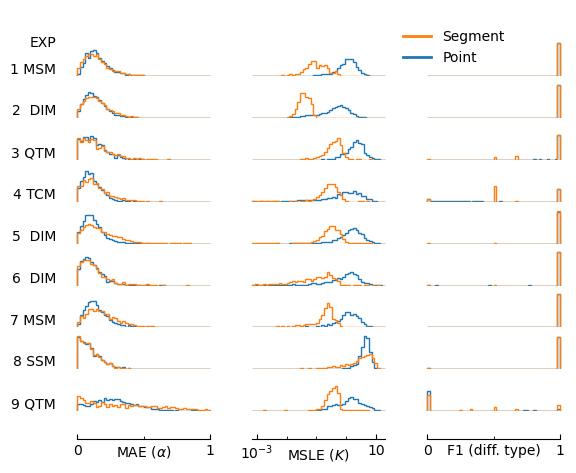

In [417]:
fig,axs = plt.subplots(9,3,sharex='col', sharey='col')
from matplotlib.lines import Line2D
legend_h = [
            Line2D([0], [0], color='C1', lw=2, label='Segment',),
            Line2D([0], [0], color='C0', lw=2, label='Point',),
           ]
# Hide all unnecesary spines
for ax in axs[:-1,1:].flatten(): ax.set_axis_off()
for ax in axs[:-1,0].flatten():
    ax.spines[['left','bottom','right', 'top']].set_visible(False)
    ax.tick_params(which='both',bottom=False,left=False,labelbottom=False,labelleft=False)
for ax in axs[-1,:].flatten():
    ax.spines[['left','right', 'top']].set_visible(False)
    ax.tick_params(left=False,labelleft=False)
    # Disjoin bottom spine by moving it outwards
    ax.spines[['bottom']].set_position(('outward', 20))
for ax in axs[-1,[0,2]]:
    # Set axis / spine lengths
    ax.spines['bottom'].set_bounds(0,1)
    ax.set_xticks(ticks=[0,1], labels=['0', '1'])
    ax.set_xticks(ticks=[0.5], labels=[], minor=True)

axs[0,0].text(-0.1,0.85,"EXP", ha='right', transform=axs[0,0].transAxes);
axs[-1,0].set_xlabel(r'MAE $(\alpha)$', labelpad=-10)
axs[-1,1].set_xlabel(r'MSLE $(K)$', labelpad=-11)
axs[-1,2].set_xlabel(r'F1 (diff. type)', labelpad=-10);

for exp in trange(N_EXP):
    # point
    axs[exp,0].hist(m_a[exp],np.linspace(0,1,51),  histtype='step', density=True);
    axs[exp,1].hist(np.log10(m_K[exp]),np.linspace(np.log10(7e-4),np.log10(20),51),
                    histtype='step', density=True); # not well computed density in logspace
    axs[exp,2].hist(m_s[exp],np.linspace(0,1,51), histtype='step', density=True);
    # segments
    axs[exp,0].hist(m_seg_a[exp],np.linspace(0,1,51),  histtype='step', density=True);
    axs[exp,1].hist(np.log10(m_seg_K[exp]),np.linspace(np.log10(7e-4),np.log10(20),51),
                    histtype='step', density=True);  # not well computed density in logspace
    axs[exp,2].hist(m_seg_s[exp],np.linspace(0,1,51), histtype='step', density=True);
    # style
    axs[exp,0].text(-0.1,0, f"{exp+1} {exp_model[exp]}", va='bottom',ha='right', transform=axs[exp,0].transAxes)

axs[-1,1].spines['bottom'].set_bounds(np.log10(7e-4),np.log10(20))
axs[-1,1].set_xticks(ticks=[-3,1], labels=[r'$10^{-3}$', '10']);
axs[-1,1].set_xticks(ticks=[-2,-1,0],labels=[], minor=True);
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles=legend_h, loc=(0.69,0.85),frameon=False);
save_plot("MAEalpha_MSLEK_F1state_point_vs_segment", fig)

# Ensemble

In [176]:
from andi_datasets.utils_challenge import run_ensemble_task, listdir_nohidden

In [177]:
track=2
path_submit = '../../data/submit/20250203/res'
exp_folders = sorted(list(listdir_nohidden(str(public_data_path)+f'/track_{track}')))
exp_nums = [int(re.findall(r'\d+', name)[0]) for name in exp_folders]

In [178]:
exp_nums

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [179]:
out = run_ensemble_task(exp_nums, track, path_submit, public_data_path)

In [180]:
out

((0.17095147612217923, 0.06456365397809982),
    Exp  alpha        K
 0    0  0.122   0.0685
 1    1 0.0323  0.00294
 2    2  0.117 2.32e-05
 3    3 0.0954  0.00378
 4    4  0.106  0.00673
 5    5 0.0722   0.0223
 6    6 0.0816   0.0255
 7    7  0.132    0.451
 8    8  0.781 1.24e-05)

In [181]:
pd.set_option('display.float_format', '{:.3g}'.format)

In [182]:
scores_e = out[1]

In [183]:
scores_e.loc['mean'] = scores_e.mean()

In [184]:
scores_e

,Exp,alpha,K
0,0,0.122,0.0685
1,1,0.0323,0.00294
2,2,0.117,2.32e-05
3,3,0.0954,0.00378
4,4,0.106,0.00673
5,5,0.0722,0.0223
6,6,0.0816,0.0255
7,7,0.132,0.451
8,8,0.781,1.24e-05
mean,4,0.171,0.0646


In [196]:
scores_e_repro = pd.DataFrame(data=np.array([distance_a_exp, distance_d_exp]).T,columns=scores_e.columns[1:])
scores_e_repro.loc['mean'] = scores_e_repro.mean()

In [197]:
scores_e_repro

,alpha,K
0,0.122,0.0685
1,0.0323,0.00294
2,0.117,2.32e-05
3,0.0954,0.00378
4,0.106,0.00673
5,0.0722,0.0223
6,0.0816,0.0255
7,0.132,0.451
8,0.781,1.24e-05
mean,0.171,0.0646


In the ensemble task, you must provide the diffusive properties of each state present in the dataset. The submission file should have the following structure:

|model: modelXXX;      |  num_state: YYY     |                      |     |
|:--------------------:|:-------------------:|:--------------------:|:---:|
| $\mu_\alpha^1$;      | $\mu_\alpha^2$;     | $\mu_\alpha^3$;      | ... |
| $\sigma_\alpha^1$;   | $\sigma_\alpha^2$;  | $\sigma_\alpha^3$;   | ... |
| $\mu_K^1$;           | $\mu_K^2$;          | $\mu_K^3$;           | ... |        
| $\sigma_K^1$;        | $\sigma_K^2$;       | $\sigma_K^3$;        | ... |
| $N_1$;               | $N_2$;              | $N_3$;               | ... |

The first row contains the diffusion model prediction for the experiment and the number of diffusive states. Below, every column contains the properties for each of the predicted diffusive states:

- $\mu_\alpha^i$, $\sigma_\alpha^i$: mean and variance of the anomalous diffusion exponent.
- $\mu_K^i$, $\sigma_K^i$: mean and variance of the diffusion coefficient.
- $N_i$: relative weight of the state (e.g. time spent in it).

It is important to use `;` as delimiter of the file.

For the model prediction, the available diffusion models are (and should be written as):

In [ ]:
from andi_datasets.datasets_phenom import datasets_phenom
print(datasets_phenom().avail_models_name)

['single_state', 'multi_state', 'immobile_traps', 'dimerization', 'confinement']


Both $\alpha$ and $D$ are bound to some minimal and maximal values:

In [ ]:
from andi_datasets.models_phenom import models_phenom
print(f' Min, max D: {models_phenom().bound_D}\n',
      f'Min, max alpha: {models_phenom().bound_alpha}')

 Min, max D: [1e-12, 1000000.0]
 Min, max alpha: [0, 1.999]


For instance the file `res/track_1/exp_0/ensemble_labels.txt` should look something like:

```
model: confinement; num_state: 2 
5.928446182250183272e-01;8.442657485810173279e-01
8.579456176227567843e-01;8.472517387841254077e-01
6.235636967859723434e-01;3.843817072926998257e-01
2.975346065444722798e-01;5.671297731744318060e-02
3.633859973276627464e-01;6.366140026723372536e-01
```


In [713]:
path_results

Path('../../data/submit/20250203/res')

## Load segments

In [702]:
#| export

from pathlib import Path

import re, shutil, numpy as np, pandas as pd
from tqdm.auto import tqdm, trange
from fastai.vision.all import *
from torch.utils.data import Dataset#, DataLoader

In [703]:
# load segments
# from experiment FOVs' txt files
#| export

def read_segments(data_path, track: str="2", exp: str='0'):
    """Extract segments info from the fov files in the given path."""
    stats = {"ks": [], "alphas": [], "states": [], "cps": [], "res": [],}
    # for exp_path in tqdm((data_path/f"track_{track}").iterdir(),):# total=num_FOVs):
    exp_path = data_path/f"track_{track}/exp_{exp}"
    # if not exp_path.is_dir():    continue

    traj_label_files = sorted([f for f in exp_path.iterdir() if re.search(r"fov_\d*.txt", f.name)])

    for file in traj_label_files:
        with open(file, "r") as f:
            traj_info = f.readlines()

        fov_ks, fov_alphas, fov_states, fov_cps, fov_res_time = [], [], [], [], []
        for info in traj_info:
            ks, alphas, states, cps = _parse_trajectory_info(info)
            fov_ks.append(ks)
            fov_alphas.append(alphas)
            fov_states.append(states)
            fov_cps.append(cps)
            if len(cps)>1:
                fov_res_time.append(cps[0:1]+[cp-cp_ for cp, cp_ in zip(cps[1:],cps[:-1])])
            elif len(cps)==1:
                fov_res_time.append(cps)
            else:
                raise Error
        stats["ks"].append(fov_ks)
        stats["alphas"].append(fov_alphas)
        stats["states"].append(fov_states)
        stats["cps"].append(fov_cps)
        stats["res"].append(fov_res_time)

    return stats

def _parse_trajectory_info(info):
    """Extract the trajectory information from the labels.
    The file format is:
    traj_idx,K_0,alpha_0,state_0,cp_0,...,state_n,traj_len"""
    ks, alphas, states, cps = [], [], [], []
    split_info = re.findall(r"\d*,(.*)\n$", info)[0].split(",")
    ks.extend(    [float(f)  for f in split_info[::4]])
    alphas.extend([float(f)  for f in split_info[1::4]])
    states.extend([int(i[0]) for i in split_info[2::4]])
    cps.extend(   [int(i)    for i in split_info[3::4]])
    return ks, alphas, states, cps

In [704]:
path_submit = Path('../../data/submit/20250203/')  # 20240714/')  # 20240710/')  # 20240628/')
path_results = path_submit/'res/'

In [705]:
!ls {path_results/'track_2/exp_1'}

ensemble_labels.txt  fov_14.txt  fov_1.txt   fov_25.txt  fov_3.txt  fov_9.txt
fov_0.txt	     fov_15.txt  fov_20.txt  fov_26.txt  fov_4.txt
fov_10.txt	     fov_16.txt  fov_21.txt  fov_27.txt  fov_5.txt
fov_11.txt	     fov_17.txt  fov_22.txt  fov_28.txt  fov_6.txt
fov_12.txt	     fov_18.txt  fov_23.txt  fov_29.txt  fov_7.txt
fov_13.txt	     fov_19.txt  fov_24.txt  fov_2.txt	 fov_8.txt


In [706]:
df = pd.read_csv(path_results/'track_2/exp_1/fov_0.txt', sep=" ", header=None); df

,0
0,"0,6.1202127e-06,1.1323414,2,36,0.0022668883,1.2045248,2,71,3.1698036e-07,1.3577391,2,85,0.2599557,1.0276761,2,105,4.2411752e-06,1.1899651,2,200"
1,"1,0.0005935565,1.1721672,2,175"
2,"2,1.9150004e-05,0.99221414,2,190,0.09480322,0.98175585,2,200"
3,"3,7.663145e-05,1.2376064,2,13,5.513488e-07,1.0939813,2,40"
4,"4,0.00026594146,1.1121988,2,22"
5,"5,3.045007,0.7761223,2,28"
6,"6,0.0006670501,0.87529105,2,23"
7,"7,2.8982584,1.2020866,2,5,4.994182e-07,1.2062784,2,34,0.011050191,1.147234,2,60,2.9865228e-06,1.0805392,2,92,0.00033916964,1.0859284,2,200"
8,"8,2.3580751e-05,0.97514415,2,39"
9,"9,0.00015918737,1.3365163,2,15,8.312545e-07,1.2209346,2,64"


In [707]:
# set manually after analysis of k-means and visual inspection
num_states_exp = [2,2,5,4,5,2,2,6,5,3, 4, 6][:N_EXP]
# some big values are hacks for kmeans to cluster properly

In [708]:
def flatten_list_to_array(l): return np.concatenate([subitem for item in l for subitem in item])

In [709]:
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.colors as clr

## Predict ensembles

In [711]:
from andi_datasets.datasets_phenom import datasets_phenom

for track in [2]:
    # Create the folder of the track if it does not exists
    path_track = path_results / f'track_{track}/'
    if not os.path.exists(path_track):    os.makedirs(path_track)

    for exp, n_states in enumerate(num_states_exp):
        if N_EXP==9: exp+=1
        # create data states from segment predictions
        print(f'Exp {exp}')
        seg = read_segments(path_results, exp=str(exp))
        seg_flat = *map(flatten_list_to_array, [seg[label] for label in ["alphas", "ks", "states", "cps", "res"]]),
        seg_flat_alphas, seg_flat_ks, seg_flat_states, seg_flat_cps, seg_flat_res = seg_flat

        scaler = StandardScaler()
        x = np.stack((np.log10(seg_flat_ks), seg_flat_alphas, seg_flat_states), axis=-1)
        x = scaler.fit_transform(x)

        # sse = []
        # n_clusters = np.arange(1, 8)
        # for n in tqdm(n_clusters):
        #     kmeans = KMeans(init="k-means++", n_clusters=n, n_init=10, max_iter=300, random_state=42)
        #     kmeans.fit(x)
        #     sse.append(kmeans.inertia_)
        kmeans = KMeans(init="k-means++", n_clusters=n_states,#kl.elbow,
                        n_init=10, max_iter=300, random_state=42)
        kmeans.fit(x)
        seg_labels = kmeans.predict(x)
        data = np.zeros((5,n_states))
        assert n_states==kmeans.n_clusters
        n_states_ = -1
        for i in range(kmeans.n_clusters):
            if sum(seg_labels==i)/len(seg_labels)<.03: continue
            n_states_+=1
            data[0,i] = np.mean(seg_flat_alphas[seg_labels==i]) # weight with residence_time??
            data[1,i] = np.var (seg_flat_alphas[seg_labels==i])
            data[2,i] = np.mean(seg_flat_ks    [seg_labels==i])
            data[3,i] = np.var (seg_flat_ks    [seg_labels==i])
            data[4,i] = np.sum(seg_flat_res[seg_labels==i])/np.sum(seg_flat_res)
            # print(f'mu D = {np.mean(10**seg_flat_ks[seg_labels==i]):.3g}')
            print(f'mu  a = {data[0,i]:.3g}')
            print(f'var a = {data[1,i]:.3g}')
            print(f'mu  D = {data[2,i]:.3g}')
            print(f'var D = {data[3,i]:.3g}')
            print(f'res T = {data[4,i]:.1%}')
            print(f'label = {sum(seg_labels==i)/len(seg_labels):.1%}')
            print()
        print('-'*8)
        # save the data in a file for submission
        # Create the folder of the experiment if it does not exits
        path_exp = path_track/f'exp_{exp}/'
        if not os.path.exists(path_exp):  os.makedirs(path_exp)
        file_name = path_exp / 'ensemble_labels.txt'
        with open(file_name, 'a') as f:
            # Save the model (random) and the number of states
            # TODO predict model as states
            model_name = np.random.choice(datasets_phenom().avail_models_name, size = 1)[0]
            f.write(f'model: {model_name}; num_state: {n_states_} \n')
            # Save the data in the corresponding ensemble file
            np.savetxt(f, data, delimiter = ';')
            print(f'Saved data at {file_name}')

Exp 1
mu  a = 1.12
var a = 0.0215
mu  D = 3.74e-05
var D = 6.12e-09
res T = 63.2%
label = 54.1%

mu  a = 1.12
var a = 0.0201
mu  D = 0.432
var D = 6.22
res T = 36.8%
label = 45.9%

--------
Saved data at ../../data/submit/20250203/res/track_2/exp_1/ensemble_labels.txt
Exp 2
mu  a = 1.05
var a = 0.0867
mu  D = 1.56e-05
var D = 1.17e-09
res T = 71.2%
label = 59.3%

mu  a = 1.06
var a = 0.0902
mu  D = 0.143
var D = 2.27
res T = 28.8%
label = 40.7%

--------
Saved data at ../../data/submit/20250203/res/track_2/exp_2/ensemble_labels.txt
Exp 3
mu  a = 1.07
var a = 0.014
mu  D = 2.35
var D = 53
res T = 25.0%
label = 35.1%

mu  a = 1.06
var a = 0.016
mu  D = 4.69e-06
var D = 3.48e-11
res T = 24.9%
label = 29.9%

mu  a = 0.32
var a = 0.0238
mu  D = 0.00259
var D = 8.46e-05
res T = 8.9%
label = 10.6%

mu  a = 1.07
var a = 0.0164
mu  D = 0.00125
var D = 4.83e-06
res T = 39.7%
label = 22.9%

--------
Saved data at ../../data/submit/20250203/res/track_2/exp_3/ensemble_labels.txt
Exp 4
mu  a = 0.314

In [715]:
path_results = path_analysis/ "benchmark"
path_results.mkdir(exist_ok=True)

In [717]:
path_results

Path('../../data/analysis/benchmark')

In [718]:
from andi_datasets.datasets_phenom import datasets_phenom

for track in [2]:
    # Create the folder of the track if it does not exists
    path_track = path_results / f'track_{track}/'
    path_track.mkdir(exist_ok=True)

    for exp, n_states in enumerate(num_states_exp):
        if N_EXP==9: exp+=1  # to match benchmark dataset
        print(f'Exp {exp}')
        # Create the folder of the experiment if it does not exits
        path_exp = path_track/f'exp_{exp}/'; path_exp.mkdir(exist_ok=True)
        # create data states from segment predictions
        # load segment
        with np.load(path_exp/"segment.npz", allow_pickle=True) as f:
            true_seg_a=f['true_exp_seg_a']; true_seg_K=f['true_exp_seg_K']
            true_seg_s=f['true_exp_seg_s']; true_cps_idx_=f['true_exp_cps_idx_']
            pred_seg_a=f['pred_exp_seg_a']; pred_seg_K=f['pred_exp_seg_K']
            pred_seg_s=f['pred_exp_seg_s']; pred_cps_idx_=f['pred_exp_cps_idx_']
        pred_seg_cps = pred_cps_idx_

        seg_flat_alphas = flat_pred_seg_a = np.concatenate(pred_seg_a)
        seg_flat_ks = flat_pred_seg_K = np.concatenate(pred_seg_K)
        seg_flat_states = flat_pred_seg_s = np.concatenate(pred_seg_s)
        seg_flat_cps = flat_pred_seg_cps = np.concatenate(pred_seg_cps)
        seg_flat_res = pred_seg_restime = np.concatenate(np.array([np.diff(np.concatenate(([0],cps+1)))
                                      for cps in pred_seg_cps], dtype=object))
        seg_flat_res_sum = np.sum(seg_flat_res)

        scaler = StandardScaler()
        x = np.stack((np.log10(seg_flat_ks), seg_flat_alphas, seg_flat_states), axis=-1)
        x = scaler.fit_transform(x)
        kmeans = KMeans(init="k-means++", n_clusters=n_states,#kl.elbow,
                        n_init=10, max_iter=300, random_state=42)
        kmeans.fit(x)
        seg_labels = kmeans.predict(x)
        data = np.zeros((5,n_states))
        assert n_states==kmeans.n_clusters
        n_states_ = -1
        for i in range(kmeans.n_clusters):
            if sum(seg_labels==i)/len(seg_labels)<.03: continue
            n_states_+=1
            data[0,i] = np.mean(seg_flat_alphas[seg_labels==i]) # weight with residence_time??
            data[1,i] = np.var (seg_flat_alphas[seg_labels==i])
            data[2,i] = np.mean(seg_flat_ks    [seg_labels==i])
            data[3,i] = np.var (seg_flat_ks    [seg_labels==i])
            data[4,i] = np.sum(seg_flat_res[seg_labels==i])/seg_flat_res_sum
            # print(f'mu D = {np.mean(10**seg_flat_ks[seg_labels==i]):.3g}')
            print(f'mu  a = {data[0,i]:.3g}')
            print(f'var a = {data[1,i]:.3g}')
            print(f'mu  D = {data[2,i]:.3g}')
            print(f'var D = {data[3,i]:.3g}')
            print(f'res T = {data[4,i]:.1%}')
            print(f'label = {sum(seg_labels==i)/len(seg_labels):.1%}')
            print()
        print('-'*8)
        # save the data
        ensemble_labels = data[:,:n_states_]
        np.save(path_exp/"ensemble_labels", ensemble_labels)
        print(f'Saved data at {path_exp/"ensemble_labels"}')

Exp 1
mu  a = 1.12
var a = 0.0201
mu  D = 0.432
var D = 6.22
res T = 36.8%
label = 45.9%

mu  a = 1.12
var a = 0.0215
mu  D = 3.74e-05
var D = 6.12e-09
res T = 63.2%
label = 54.1%

--------
Saved data at ../../data/analysis/benchmark/track_2/exp_1/ensemble_labels
Exp 2
mu  a = 1.05
var a = 0.0867
mu  D = 1.56e-05
var D = 1.17e-09
res T = 71.2%
label = 59.3%

mu  a = 1.06
var a = 0.0902
mu  D = 0.143
var D = 2.27
res T = 28.8%
label = 40.7%

--------
Saved data at ../../data/analysis/benchmark/track_2/exp_2/ensemble_labels
Exp 3
mu  a = 1.06
var a = 0.016
mu  D = 4.69e-06
var D = 3.48e-11
res T = 24.9%
label = 29.9%

mu  a = 1.07
var a = 0.014
mu  D = 2.35
var D = 53
res T = 25.0%
label = 35.1%

mu  a = 0.32
var a = 0.0238
mu  D = 0.00259
var D = 8.46e-05
res T = 8.9%
label = 10.6%

mu  a = 1.07
var a = 0.0164
mu  D = 0.00125
var D = 4.83e-06
res T = 39.7%
label = 22.9%

--------
Saved data at ../../data/analysis/benchmark/track_2/exp_3/ensemble_labels
Exp 4
mu  a = 0.314
var a = 0.0108

In [720]:
path_track = path_results / f'track_{track}/'
path_exp = path_track/f'exp_{exp}/';
ensemble_label = np.load(path_exp/"ensemble_labels.npy", allow_pickle=True)

In [721]:
ensemble_label

array([[7.07260132e-01, 1.94246662e+00, 1.64206195e+00, 1.62201726e+00],
       [7.38953203e-02, 7.16438610e-03, 3.79230827e-02, 6.38703033e-02],
       [2.19954131e-03, 6.42335701e+00, 4.09749809e-05, 1.08056283e+00],
       [2.66057526e-04, 3.87160767e+02, 6.13015994e-09, 7.54394379e+01],
       [1.00286700e-01, 8.46832387e-02, 4.79054085e-01, 2.18597306e-01]])

## Check predicted segments are equal
Segments are equal but have different load ordering (lexicographic vs numeric).
Therefore, ensemble predictions are different as kmeans depends on data ordering.

In [722]:
exp=1

In [757]:
path_submit = Path('../../data/submit/20250203/')  # 20240714/')  # 20240710/')  # 20240628/')
path_results = path_submit/'res/'
seg = read_segments(path_results, exp=str(exp))
seg_flat = *map(flatten_list_to_array, [seg[label] for label in ["alphas", "ks", "states", "cps", "res"]]),
seg_flat_alphas_, seg_flat_ks_, seg_flat_states_, seg_flat_cps_, seg_flat_res_ = seg_flat

In [758]:
exp_path = path_results/f"track_{track}/exp_{exp}"
traj_label_files = sorted([f for f in exp_path.iterdir() if re.search(r"fov_\d*.txt", f.name)])

In [ ]:
traj_label_files # read_segments gathers fovs in this ordering (lexicographical) while the other does numeric order (0,1,2,3,...,28,29)

In [720]:
path_results = path_analysis/ "benchmark"
path_results.mkdir(exist_ok=True)
path_track = path_results / f'track_{track}/'
path_exp = path_track/f'exp_{exp}/';

In [724]:
# load segment
with np.load(path_exp/"segment.npz", allow_pickle=True) as f:
    true_seg_a=f['true_exp_seg_a']; true_seg_K=f['true_exp_seg_K']
    true_seg_s=f['true_exp_seg_s']; true_cps_idx_=f['true_exp_cps_idx_']
    pred_seg_a=f['pred_exp_seg_a']; pred_seg_K=f['pred_exp_seg_K']
    pred_seg_s=f['pred_exp_seg_s']; pred_cps_idx_=f['pred_exp_cps_idx_']
pred_seg_cps = pred_cps_idx_

seg_flat_alphas = flat_pred_seg_a = np.concatenate(pred_seg_a)
seg_flat_ks = flat_pred_seg_K = np.concatenate(pred_seg_K)
seg_flat_states = flat_pred_seg_s = np.concatenate(pred_seg_s)
seg_flat_cps = flat_pred_seg_cps = np.concatenate(pred_seg_cps)
seg_flat_res = pred_seg_restime = np.concatenate(np.array([np.diff(np.concatenate(([0],cps+1)))
                              for cps in pred_seg_cps], dtype=object))
seg_flat_res_sum = np.sum(seg_flat_res)


In [725]:
seg_flat_alphas_.shape, seg_flat_alphas.shape

((3940,), (3940,))

In [726]:
seg_flat_alphas_

array([1.1323414, 1.2045248, 1.3577391, ..., 1.1469852, 1.1390463,
       1.169206 ])

In [727]:
seg_flat_alphas

array([1.1323414, 1.2045248, 1.3577391, ..., 1.0656724, 1.2160158,
       0.9538231], dtype=float32)

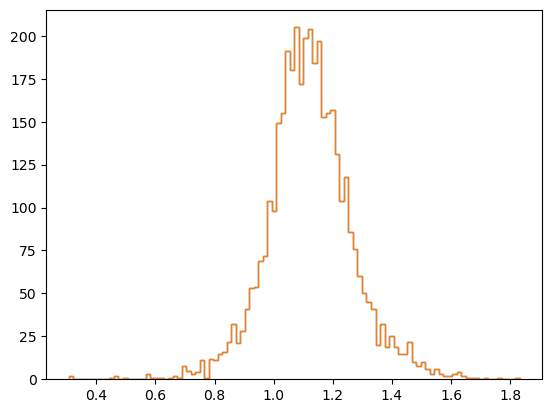

In [730]:
plt.hist(seg_flat_alphas, 100, histtype='step');
plt.hist(seg_flat_alphas_, 100, histtype='step');

In [737]:
# distributions match but one-to-one comparison fails after the 298th
np.isclose(seg_flat_alphas_,seg_flat_alphas).sum()

298

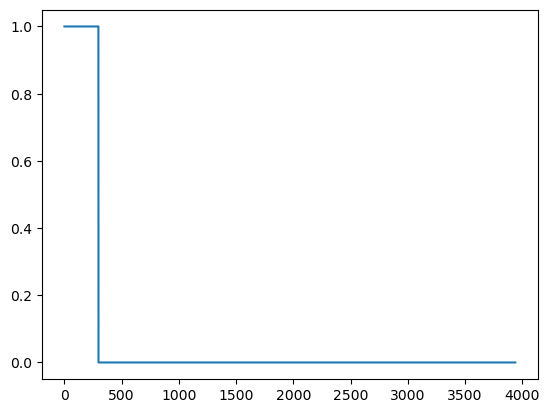

In [741]:
plt.plot(np.isclose(seg_flat_alphas_,seg_flat_alphas));

In [746]:
# they are disordered with respect to each other
np.isclose(np.unique(seg_flat_alphas), np.unique(seg_flat_alphas_)).sum()

3939

In [743]:
seg_flat_alphas[297:310], seg_flat_alphas_[297:310]

(array([1.0186728, 1.1774014, 1.357063 , 1.3578501, 1.2249979, 1.2149493,
        1.2148268, 1.2331158, 1.24126  , 1.2126133, 1.2168765, 1.0286618,
        1.0177909], dtype=float32),
 array([1.0186728, 1.197296 , 1.1977823, 1.197514 , 1.1964008, 1.0768305,
        1.053171 , 1.0517223, 1.0710745, 1.2172571, 1.325856 , 1.2153577,
        1.3331951]))

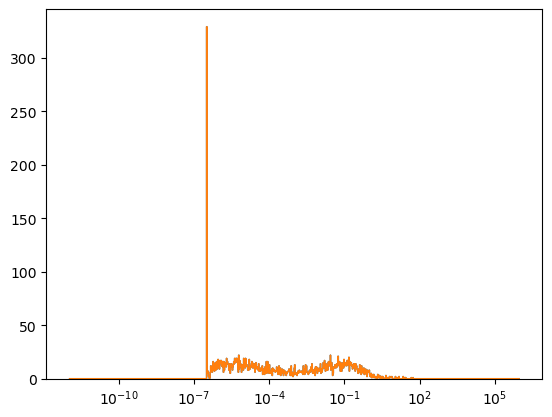

In [750]:
plt.hist(seg_flat_ks, np.geomspace(1e-12,1e6,1000), histtype='step');
plt.hist(seg_flat_ks_, np.geomspace(1e-12,1e6,1000), histtype='step');
plt.xscale('log')

In [751]:
# distributions match but one-to-one comparison fails after the 298th
np.isclose(seg_flat_ks_,seg_flat_ks).sum()

322

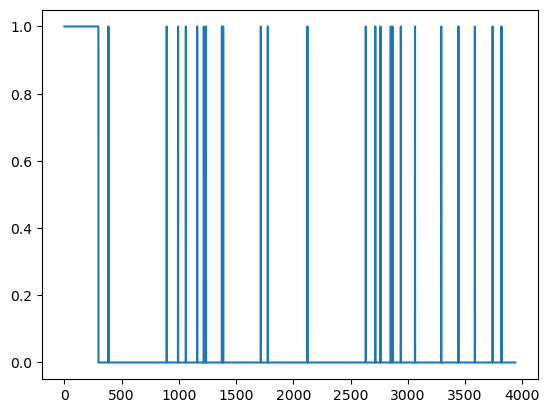

In [752]:
plt.plot(np.isclose(seg_flat_ks_,seg_flat_ks));

In [753]:
# they are disordered with respect to each other
np.isclose(np.unique(seg_flat_ks), np.unique(seg_flat_ks_)).sum()

3679

## Does the clustering (kmeans) depend on the ordering of the segments? Yes

In [ ]:
scaler = StandardScaler()
x = np.stack((np.log10(seg_flat_ks), seg_flat_alphas, seg_flat_states), axis=-1)
x = scaler.fit_transform(x)
kmeans = KMeans(init="k-means++", n_clusters=n_states,#kl.elbow,
                n_init=10, max_iter=300, random_state=42)
kmeans.fit(x)
seg_labels = kmeans.predict(x)
data = np.zeros((5,n_states))
assert n_states==kmeans.n_clusters
n_states_ = -1
for i in range(kmeans.n_clusters):
    if sum(seg_labels==i)/len(seg_labels)<.03: continue
    n_states_+=1
    data[0,i] = np.mean(seg_flat_alphas[seg_labels==i]) # weight with residence_time??
    data[1,i] = np.var (seg_flat_alphas[seg_labels==i])
    data[2,i] = np.mean(seg_flat_ks    [seg_labels==i])
    data[3,i] = np.var (seg_flat_ks    [seg_labels==i])
    data[4,i] = np.sum(seg_flat_res[seg_labels==i])/np.sum(seg_flat_res)
    # print(f'mu D = {np.mean(10**seg_flat_ks[seg_labels==i]):.3g}')
    print(f'mu  a = {data[0,i]:.3g}')
    print(f'var a = {data[1,i]:.3g}')
    print(f'mu  D = {data[2,i]:.3g}')
    print(f'var D = {data[3,i]:.3g}')
    print(f'res T = {data[4,i]:.1%}')
    print(f'label = {sum(seg_labels==i)/len(seg_labels):.1%}')
    print()
print('-'*8)

In [ ]:
scaler = StandardScaler()
x = np.stack((np.log10(seg_flat_ks), seg_flat_alphas, seg_flat_states), axis=-1)
x = scaler.fit_transform(x)
kmeans = KMeans(init="k-means++", n_clusters=n_states,#kl.elbow,
                n_init=10, max_iter=300, random_state=42)
kmeans.fit(x)
seg_labels = kmeans.predict(x)
data = np.zeros((5,n_states))
assert n_states==kmeans.n_clusters
n_states_ = -1
for i in range(kmeans.n_clusters):
    if sum(seg_labels==i)/len(seg_labels)<.03: continue
    n_states_+=1
    data[0,i] = np.mean(seg_flat_alphas[seg_labels==i]) # weight with residence_time??
    data[1,i] = np.var (seg_flat_alphas[seg_labels==i])
    data[2,i] = np.mean(seg_flat_ks    [seg_labels==i])
    data[3,i] = np.var (seg_flat_ks    [seg_labels==i])
    data[4,i] = np.sum(seg_flat_res[seg_labels==i])/np.sum(seg_flat_res)
    # print(f'mu D = {np.mean(10**seg_flat_ks[seg_labels==i]):.3g}')
    print(f'mu  a = {data[0,i]:.3g}')
    print(f'var a = {data[1,i]:.3g}')
    print(f'mu  D = {data[2,i]:.3g}')
    print(f'var D = {data[3,i]:.3g}')
    print(f'res T = {data[4,i]:.1%}')
    print(f'label = {sum(seg_labels==i)/len(seg_labels):.1%}')
    print()
print('-'*8)

In [ ]:
scaler = StandardScaler()
r = np.random.choice(x.shape[0], size=x.shape[0], replace=False)
x = np.stack((np.log10(seg_flat_ks), seg_flat_alphas, seg_flat_states), axis=-1)
x = x[r]
x = scaler.fit_transform(x)
kmeans = KMeans(init="k-means++", n_clusters=n_states,#kl.elbow,
                n_init=10, max_iter=300, random_state=42)
kmeans.fit(x)
seg_labels = kmeans.predict(x)
data = np.zeros((5,n_states))
assert n_states==kmeans.n_clusters
n_states_ = -1
for i in range(kmeans.n_clusters):
    if sum(seg_labels==i)/len(seg_labels)<.03: continue
    n_states_+=1
    data[0,i] = np.mean(seg_flat_alphas[seg_labels==i]) # weight with residence_time??
    data[1,i] = np.var (seg_flat_alphas[seg_labels==i])
    data[2,i] = np.mean(seg_flat_ks    [seg_labels==i])
    data[3,i] = np.var (seg_flat_ks    [seg_labels==i])
    data[4,i] = np.sum(seg_flat_res[seg_labels==i])/np.sum(seg_flat_res)
    # print(f'mu D = {np.mean(10**seg_flat_ks[seg_labels==i]):.3g}')
    print(f'mu  a = {data[0,i]:.3g}')
    print(f'var a = {data[1,i]:.3g}')
    print(f'mu  D = {data[2,i]:.3g}')
    print(f'var D = {data[3,i]:.3g}')
    print(f'res T = {data[4,i]:.1%}')
    print(f'label = {sum(seg_labels==i)/len(seg_labels):.1%}')
    print()
print('-'*8)

## Visualize ensembles

from https://github.com/AnDiChallenge/andi_datasets/blob/master/source_nbs/tutorials/challenge_two_benchmark.ipynb

| EXP | Model | # states |   | K (pixel²/frame^α) |        |  α   |        | Diff. class |                        Model-specific parameters                       |
|:---:|:-----:|:--------:|:-:|:-----------------:|:------:|:----:|:------:|:-----------:|:----------------------------------------------------------------------:|
|     |       |          |   |         **μ**         |   **σ²**   |   **μ**  |   **σ²**   |             |                                                                        |
|  1  |  MSM  |     3    | 1 |        0.15       |  0.01  |   1  | 0.0001 |      2      | M = [[0.946, 0.024, 0.03], [0.016, 0.92, 0.064], [0.037, 0.14, 0.823]] |
|     |       |          | 2 |        0.33       |  0.001 |   1  |  0.01  |      2      |                                                                        |
|     |       |          | 3 |        0.95       |  0.01  |   1  |  0.01  |      2      |                                                                        |
|  2  |  DIM  |     2    | 1 |        0.28       |  0.001 |   1  |   0.1  |      2      |                   r = 0.5, N = 750, Pb = 1, Pu = 0.1                   |
|     |       |          | 2 |       0.0035      | 0.0001 |  1.1 |  0.01  |      2      |                                                                        |
|  3  |  QTM  |     2    | 1 |         1         |   0.1  |   1  |  0.005 |      2      |                 rt = 0.4, Nt = 500, Pb = 0.7, Pu = 1/60                |
|     |       |          | 2 |         -         |    -   |   -  |    -   |      0      |                                                                        |
|  4  |  TCM  |     2    | 1 |         1         |   0.1  |   1  |  0.005 |      2      |                        rc = 2, Nc = 150, T = 0.1                       |
|     |       |          | 2 |        0.01       |  0.001 |  0.2 |  0.001 |      1      |                                                                        |
|  5  |  DIM  |     2    | 1 |         1         |   0.1  |   1  |  0.005 |      2      |                  r = 0.35, N = 500, Pb = 1, Pu = 1/60                  |
|     |       |          | 2 |        0.01       |  0.001 |  0.2 |  0.001 |      2      |                                                                        |
|  6  |  DIM  |     2    | 1 |        0.1        |   0.1  |  0.7 |   0.1  |      2      |                    r = 1, N = 100, Pb = 1, Pu = 0.05                   |
|     |       |          | 2 |         1         |  0.01  |  1.2 |  0.01  |      2      |                                                                        |
|  7  |  MSM  |     2    | 1 |        0.1        |   0.1  |  0.7 |   0.1  |      2      |                  M = [[0.9833, 0.0167], [0.05, 0.95]]                  |
|     |       |          | 2 |         1         |  0.01  |  1.2 |  0.01  |      2      |                                                                        |
|  8  |  SSM  |     1    | 1 |         1         |   100  |   1  |   10   |    2 / 3    |                                    -                                   |
|  9  |  QTM  |     2    | 1 |         1         |  0.01  | 1.99 |  0.01  |    2 / 3    |                 rc = 1.5, Nt = 1000, Pb = 0.7, Pu = 1/5                |
|     |       |          | 2 | -                 | -      | -    | -      | 0           |                                                                        |

In [891]:
x_alpha = np.linspace(0,2, 1_000_000)
x_D = np.geomspace(1e-12,1e6, 1_000_000)
min_var = 1e-9

In [984]:
for exp in range(1,N_EXP+1):
# exp=2

In [985]:
true_ensemble_label = np.loadtxt(public_data_path/ "track_2" / f"exp_{exp}" / 'ensemble_labels.txt',
                                 skiprows = 1, delimiter = ';')

In [986]:
path_submit = Path('../../data/submit/20250203/')  # 20240714/')  # 20240710/')  # 20240628/')
path_results = path_submit/'res/'
path_track = path_results / f'track_{track}/'
path_exp = path_track/f'exp_{exp}/'
file_name = path_exp / 'ensemble_labels.txt'
ensemble_label_ = np.loadtxt(file_name, skiprows = 1, delimiter = ';')

In [987]:
path_results = path_analysis/ "benchmark"
path_results.mkdir(exist_ok=True)
path_track = path_results / f'track_{track}/'
path_exp = path_track/f'exp_{exp}/';
ensemble_label = np.load(path_exp/"ensemble_labels.npy", allow_pickle=True)

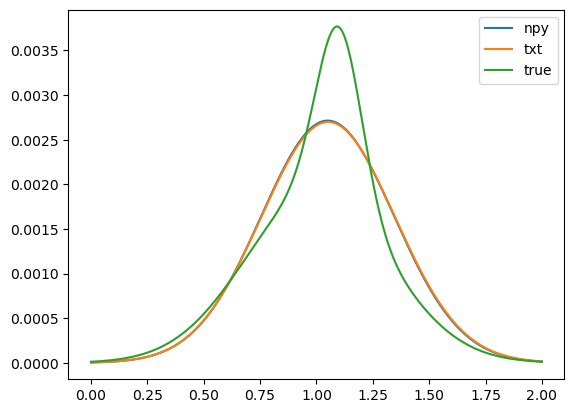

In [989]:
from scipy.stats import norm

# Generate x values
x = np.linspace(0,2, 1000)
y = np.zeros_like(x)
for i in range(ensemble_label.shape[-1]):
    var = ensemble_label[1,i]
    if var < min_var: var = min_var
    y += norm.pdf(x, loc=ensemble_label[0,i], scale=np.sqrt(var))*ensemble_label[-1,i]
y /= np.sum(y)
plt.plot(x, y,  label='npy');

y = np.zeros_like(x)
for i in range(ensemble_label_.shape[-1]):
    var = ensemble_label_[1,i]
    if var < min_var: var = min_var
    y += norm.pdf(x, loc=ensemble_label_[0,i], scale=np.sqrt(var))*ensemble_label_[-1,i]
y /= np.sum(y)
plt.plot(x, y, label='txt');

y = np.zeros_like(x)
for i in range(true_ensemble_label.shape[-1]):
    var = true_ensemble_label[1,i]
    if var < min_var: var = min_var
    y += norm.pdf(x, loc=true_ensemble_label[0,i], scale=np.sqrt(var))*true_ensemble_label[-1,i]
y /= np.sum(y)
plt.plot(x, y,  label='true');

plt.legend();

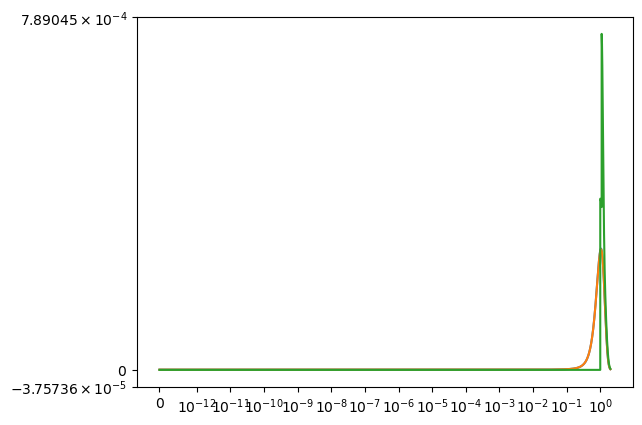

In [990]:
from scipy.stats import norm

# Generate x values
x = np.linspace(0,2, 1_0_000)
y = np.zeros_like(x)
for i in range(ensemble_label.shape[-1]):
    var = ensemble_label[1,i]
    if var < min_var: var = min_var
    weights  = ensemble_label[-1,i]
    if weights.sum() > 1: weights /= weights.sum()
    y += norm.pdf(x, loc=ensemble_label[0,i], scale=np.sqrt(var))*weights
y /= np.sum(y)
plt.plot(x, y,  label='npy');

y = np.zeros_like(x)
for i in range(ensemble_label_.shape[-1]):
    var = ensemble_label_[1,i]
    if var < min_var: var = min_var
    weights  = ensemble_label_[-1,i]
    if weights.sum() > 1: weights /= weights.sum()
    y += norm.pdf(x, loc=ensemble_label_[0,i], scale=np.sqrt(var))*weights
y /= np.sum(y)
plt.plot(x, y, label='txt');

y = np.zeros_like(x)
for i in range(true_ensemble_label.shape[-1]):
    var = true_ensemble_label[1,i]
    if var < min_var: var = min_var
    weights  = true_ensemble_label[-1,i]
    if weights.sum() > 1: weights /= weights.sum()
    y += truncnorm.pdf(x,1e-12,1e6,
                       # (1e-12-true_ensemble_label[0,i])/np.sqrt(var),
                       # (1e6-true_ensemble_label[0,i])/np.sqrt(var),
                       loc=true_ensemble_label[0,i], scale=np.sqrt(var))*weights
y /= np.sum(y)
plt.plot(x, y,  label='true');
plt.xscale('symlog',linthresh=1e-12)
plt.yscale('symlog',linthresh=1e-3)
# plt.legend();

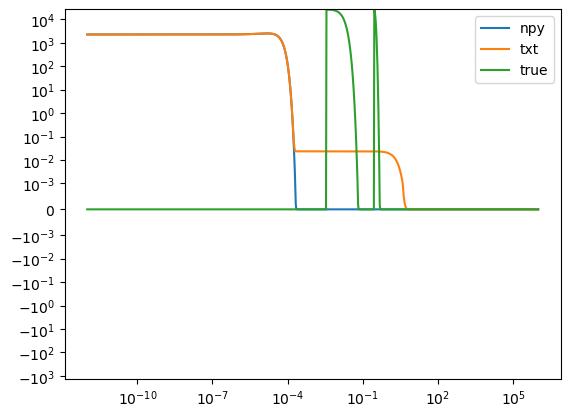

In [991]:
from scipy.stats import norm

# Generate x values
x = np.logspace(np.log10(1e-12), np.log10(1e6), int(1e3))
y = np.zeros_like(x)
for i in range(ensemble_label.shape[-1]):
    var = ensemble_label[3,i]
    if var < min_var: var = min_var
    weights  = ensemble_label[-1,i]
    if weights.sum() > 1: weights /= weights.sum()
    y += norm.pdf(x, loc=ensemble_label[2,i], scale=np.sqrt(var))*weights
y /= np.sum(y)
y *= 1e6
plt.plot(x, y,  label='npy');

y = np.zeros_like(x)
for i in range(ensemble_label_.shape[-1]):
    var = ensemble_label_[3,i]
    if var < min_var: var = min_var
    weights  = ensemble_label_[-1,i]
    if weights.sum() > 1: weights /= weights.sum()
    y += norm.pdf(x, loc=ensemble_label_[2,i], scale=np.sqrt(var))*weights
y /= np.sum(y)
y *= 1e6
plt.plot(x, y, label='txt');

y = np.zeros_like(x)
for i in range(true_ensemble_label.shape[-1]):
    var = true_ensemble_label[3,i]
    if var < min_var: var = min_var
    weights  = true_ensemble_label[-1,i]
    if weights.sum() > 1: weights /= weights.sum()
    y += truncnorm.pdf(x,1e-12,1e6,
                       # (1e-12-true_ensemble_label[0,i])/np.sqrt(var),
                       # (1e6-true_ensemble_label[0,i])/np.sqrt(var),
                       loc=true_ensemble_label[2,i],
                       scale=np.sqrt(var))*weights
y /= np.sum(y)
y *= 1e6
plt.plot(x, y, label='true');
plt.xscale('log')
plt.yscale('symlog',linthresh=1e-3)
plt.legend();

In [992]:
# these limits have no sense:
(1e-12-true_ensemble_label[0,i])/np.sqrt(var),(1e6-true_ensemble_label[0,i])/np.sqrt(var)

(-109.9999999999, 99999890.0)

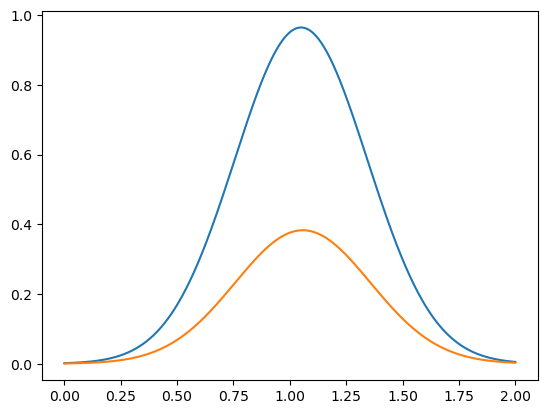

In [993]:
from scipy.stats import norm

# Generate x values
x = np.linspace(0,2, 1000)

# Calculate the probability density function (PDF)
for i in range(ensemble_label_.shape[-1]):
    y = norm.pdf(x, loc=ensemble_label_[0,i], scale=np.sqrt(ensemble_label_[1,i]) )*ensemble_label_[-1,i]
    plt.plot(x, y);

In [994]:
from andi_datasets.utils_challenge import error_Ensemble_dataset

In [996]:
distance_a_exp_, distance_d_exp_, dists_ = error_Ensemble_dataset(true_ensemble_label, ensemble_label_, return_distributions=True)

In [995]:
distance_a_exp, distance_d_exp, dists = error_Ensemble_dataset(true_ensemble_label, ensemble_label, return_distributions=True)

In [1001]:
print(distance_a_exp, distance_d_exp,distance_a_exp_, distance_d_exp_,)

0.031024428472620297 0.00293929677618315 0.032276873679754556 0.0029393172221742377


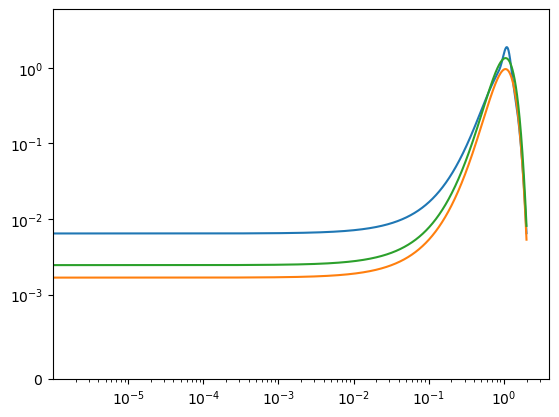

In [998]:
plt.plot(x_alpha,dists[0]);
plt.plot(x_alpha,dists[2]);plt.plot(x_alpha,dists_[2]);plt.ylim(0,6);
plt.xscale('log');plt.yscale('symlog',linthresh=.001);

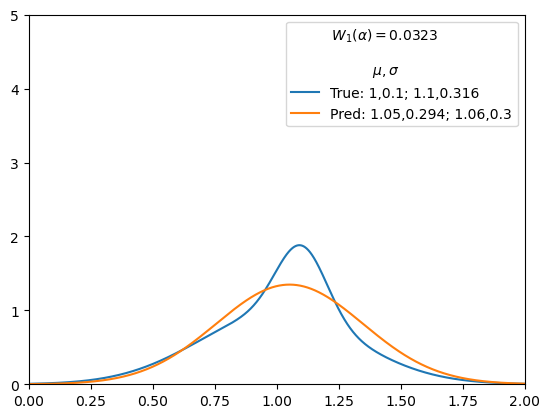

In [1054]:
plt.plot(x_alpha,dists[0], label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
# plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
plt.plot(x_alpha, dists_[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
plt.ylim(0,5);plt.xlim(0,2);plt.legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');

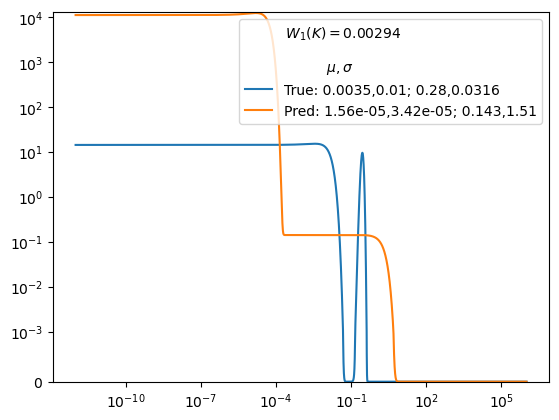

In [1055]:
plt.plot(x_D, dists[1], label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
# plt.plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
plt.plot(x_D, dists_[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
plt.xscale('log');plt.yscale('symlog',linthresh=1e-3); plt.ylim(0);
plt.legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');

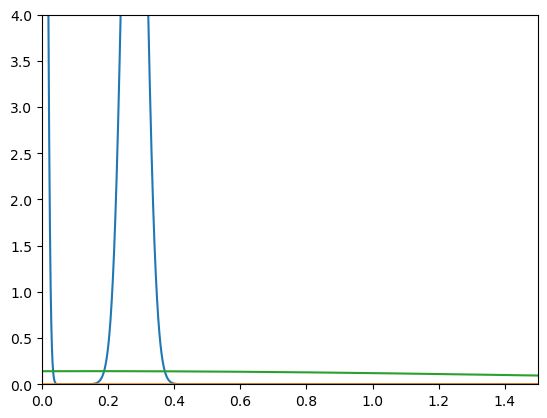

In [1000]:
plt.plot(x_D,dists[1]);plt.plot(x_D,dists[3]);plt.plot(x_D,dists_[3]);
plt.xlim(0,1.5);plt.ylim(0,4);

I think the issue is from our submissions having a zero state.
The way in which the distributions are computed when there is a zero variance introduces a minimum variance of 1e-9 and thus the distribution has a big peak centered at zero.

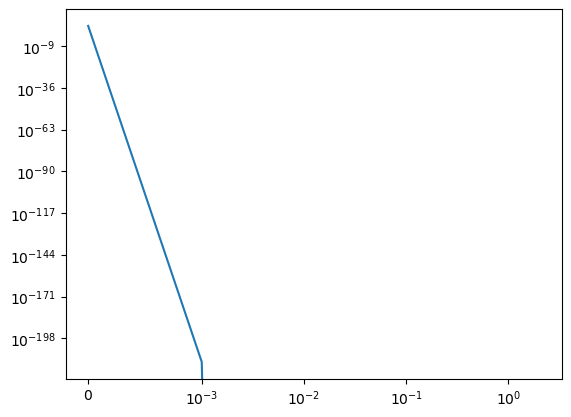

In [941]:
from scipy.stats import norm

x = np.linspace(0,2, 2_000)
y = norm.pdf(x, loc=0, scale=np.sqrt(1e-9 )) # happens in both distro for more than 1000 sample points
# y = truncnorm.pdf(x,1e-12,1e6, loc=0, scale=np.sqrt(1e-9 ))
plt.loglog(x, y);
plt.xscale('symlog', linthresh=1e-3)

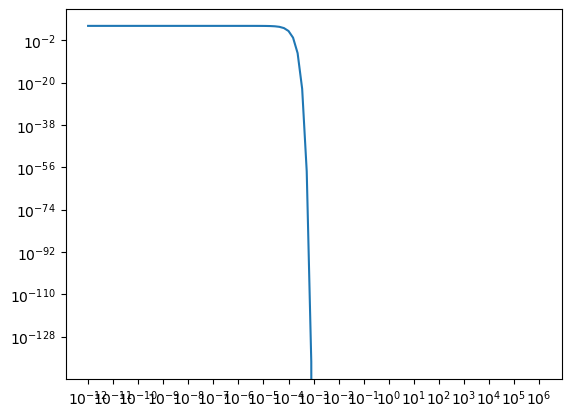

In [947]:
from scipy.stats import norm

x = np.geomspace(1e-12,1e6, 100)
y = norm.pdf(x, loc=0, scale=np.sqrt(1e-9 )) # happens in both distros
# y = truncnorm.pdf(x,1e-12,1e6, loc=0, scale=np.sqrt(1e-9 ))
plt.loglog(x, y);
plt.xscale('symlog', linthresh=1e-12)

(-1000000.0, 1000000.0)

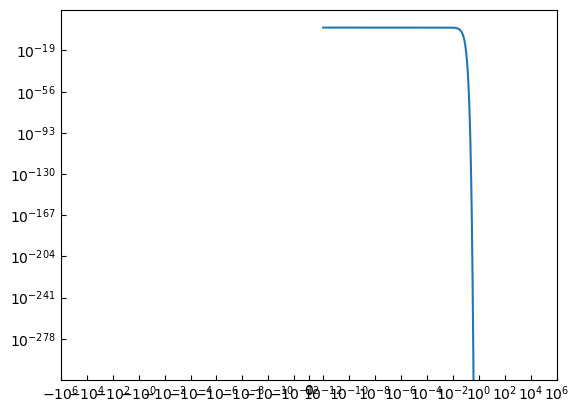

In [330]:
from scipy.stats import norm, truncnorm

x = np.geomspace(1e-12,1e6, 1000)
y = norm.pdf(x, loc=0.0035, scale=np.sqrt(0.0001)) # happens in both distros
# y = truncnorm.pdf(x,1e-12,1e6, loc=0, scale=np.sqrt(1e-9 ))
plt.loglog(x, y);
plt.xscale('symlog', linthresh=1e-12); plt.xlim(-1e6,1e6)

## Ensemble metrics

In [44]:
public_data_path = data_path/"benchmark"  #"challenge"

In [46]:
from andi_datasets.utils_challenge import error_Ensemble_dataset
distance_a_exp, distance_d_exp, dists  = [], [], []
W1_a_point_exp, W1_K_point_exp = [], []
track=2
for exp in trange(1,N_EXP+1):
    true_ensemble_label = np.loadtxt(public_data_path/ "track_2" / f"exp_{exp}" / 'ensemble_labels.txt',
                                     skiprows = 1, delimiter = ';')
    path_submit = Path('../../data/submit/20250203/')  # 20240714/')  # 20240710/')  # 20240628/')
    path_results = path_submit/'res/'
    path_track = path_results / f'track_{track}/'
    path_exp = path_track/f'exp_{exp}/'
    file_name = path_exp / 'ensemble_labels.txt'
    ensemble_label_ = np.loadtxt(file_name, skiprows = 1, delimiter = ';')


    distance_a_exp_, distance_d_exp_, dists_ = error_Ensemble_dataset(true_ensemble_label, ensemble_label_, return_distributions=True)
    W1_a_point_exp_, W1_K_point_exp_ = error_Ensemble_dataset_(true_ensemble_label, ensemble_label_)

    distance_a_exp.append(distance_a_exp_)
    distance_d_exp.append(distance_d_exp_)
    dists.append(dists_)
    W1_a_point_exp.append(W1_a_point_exp_)
    W1_K_point_exp.append(W1_K_point_exp_)

  0%|          | 0/9 [00:00<?, ?it/s]

In [398]:
w1_K

array([6.84607135e-02, 2.93931722e-03, 2.31859164e-05, 3.77574759e-03,
       6.72553762e-03, 2.22608233e-02, 2.54954012e-02, 4.51379806e-01,
       1.23538630e-05])

In [203]:
np.array(dists).shape

(9, 4, 1000000)

In [47]:
path_results = path_analysis/ "benchmark"
np.savez_compressed(path_results/'metrics_ensemble',
                    w1_a = np.array(distance_a_exp),
                    w1_K = np.array(distance_d_exp),
                    W1_a_point_exp = np.array(W1_a_point_exp),
                    W1_K_point_exp = np.array(W1_K_point_exp),
                   dists = np.array(dists))

In [401]:
path_results = path_analysis/ "benchmark"
with np.load(path_results/"metrics_ensemble.npz", allow_pickle=True) as f:
    w1_a=f['w1_a']; w1_K=f['w1_K']; dists=f['dists']
    W1_a_point_exp=f['W1_a_point_exp']
    W1_K_point_exp=f['W1_K_point_exp']

  0%|          | 0/9 [00:00<?, ?it/s]

Saved ../../data/figures/distro_alpha_ensemble
Saved ../../data/figures/distro_K_log_ensemble


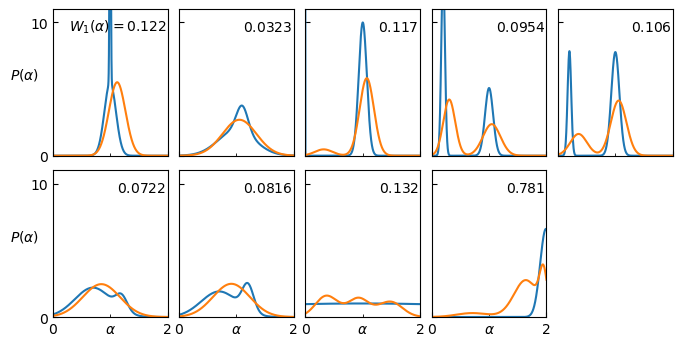

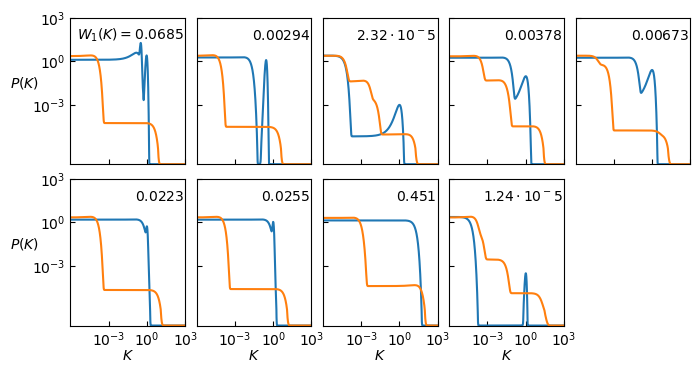

In [378]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)
x_D = np.geomspace(1e-12,1e6, 1_000_000)

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, dists_ = w1_a[exp], w1_K[exp], dists[exp]
    axs_a[exp].plot(x_alpha,dists_[0]/np.mean(dists_[0]),) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    axs_a[exp].plot(x_alpha, dists_[2]/np.mean(dists_[2]),) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(ylim=(0,11),
                     xlim=(0,2));
    axs_a[exp].set_yticks([0,10]); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    if exp==0:
        axs_a[exp].text(0.99,0.85,fr'$W_1(\alpha)={distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    else:
        axs_a[exp].text(0.99,0.85,fr'${distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    axs_K[exp].plot(x_D, dists_[1]/np.mean(dists_[1]),) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    axs_K[exp].plot(x_D, dists_[3]/np.mean(dists_[3]),) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    axs_K[exp].set_xscale('symlog',linthresh=1e-12); axs_K[exp].set_xlim(1e-6,1e3)
    axs_K[exp].set_yscale('symlog',linthresh=1e-6); axs_K[exp].set_ylim(0);
    axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    axs_K[exp].set_xticks([1e-3, 1e0, 1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    if exp==0:
        axs_K[exp].text(0.99,0.85,fr'$W_1(K)={distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
    elif exp in [2,8]:
        axs_K[exp].text(0.99,0.85,fr'${distance_d_exp_*1e5:.3g}\cdot10^{-5}$', ha='right', transform=axs_K[exp].transAxes)
    else:
        axs_K[exp].text(0.99,0.85,fr'${distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    ax.set_xticks(ticks=[1], labels=[], minor=True)
    # ax.set_axis_off()
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

#save_plot("distro_alpha_ensemble", fig_a)
#save_plot("distro_K_log_ensemble", fig_K)

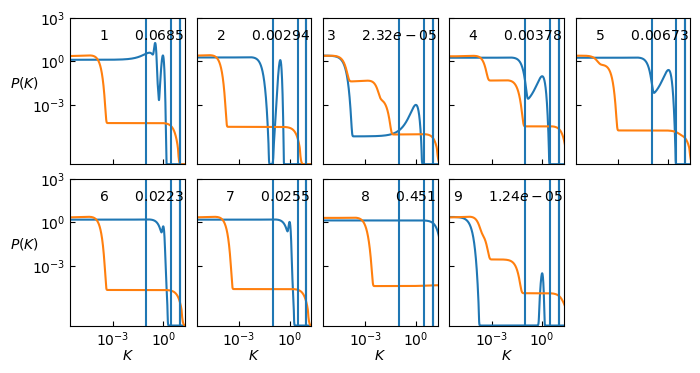

In [305]:
for ax in axs_K: ax.set_xlim(3e-6,2e1); ax.axvline(1e-1);ax.axvline(1e1);# ax.set_xscale('linear'); ax.set_yscale('linear')
fig_K

  0%|          | 0/9 [00:00<?, ?it/s]

0 68457.9208199123
1 2939.3894616365787
2 23.696333137741423
3 3775.613447216753
4 6725.340719564938
5 22259.987973224026
6 25494.472097575148
7 451361.6301709128
8 12.400382720958923


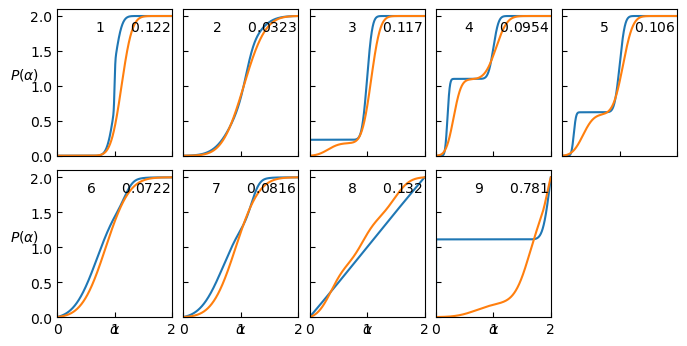

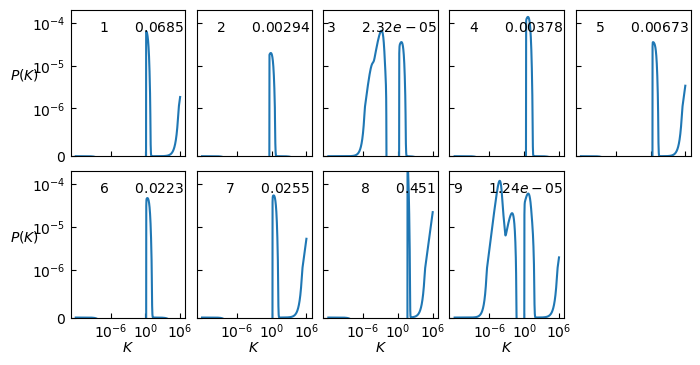

In [278]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)
x_D = np.geomspace(1e-12,1e6, 1_000_000)

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, dists_ = w1_a[exp], w1_K[exp], dists[exp]
    axs_a[exp].plot(x_alpha,np.cumsum(dists_[0])/np.mean(dists_[0])*2e-6,) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    axs_a[exp].plot(x_alpha, np.cumsum(dists_[2])/np.mean(dists_[2])*2e-6,) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(ylim=(0), #,1.1),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    y = (np.cumsum(dists_[1])[1:]/np.mean(dists_[1])-np.cumsum(dists_[3])[1:]/np.mean(dists_[3]))*np.diff(x_D)
    print(exp, np.sum(np.abs(y)))
    axs_K[exp].plot(x_D[1:], y); # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D[1:], np.cumsum(dists_[3])[1:]/np.mean(dists_[3])*np.diff(x_D),) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    axs_K[exp].set_xscale('symlog',linthresh=1e-12);
    axs_K[exp].set_yscale('symlog',linthresh=1e-6); axs_K[exp].set_ylim(0,);
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)

for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

  0%|          | 0/9 [00:00<?, ?it/s]

0 68457.9208199123
1 2939.3894616365787
2 23.696333137741423
3 3775.613447216753
4 6725.340719564938
5 22259.987973224026
6 25494.472097575148
7 451361.6301709128
8 12.400382720958923


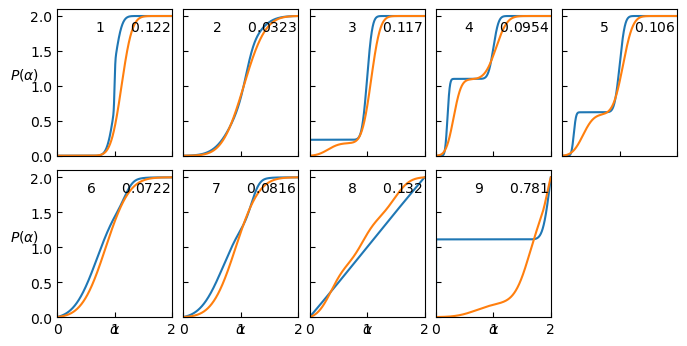

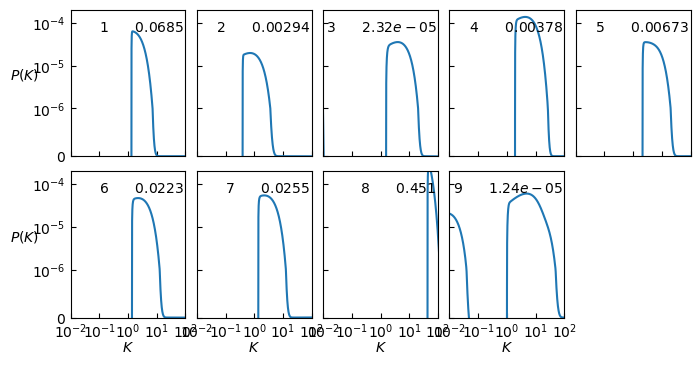

In [380]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)
x_D = np.geomspace(1e-12,1e6, 1_000_000)

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, dists_ = w1_a[exp], w1_K[exp], dists[exp]
    axs_a[exp].plot(x_alpha,np.cumsum(dists_[0])/np.mean(dists_[0])*2e-6,) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    axs_a[exp].plot(x_alpha, np.cumsum(dists_[2])/np.mean(dists_[2])*2e-6,) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(ylim=(0), #,1.1),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    y = (np.cumsum(dists_[1])[1:]/np.mean(dists_[1])-np.cumsum(dists_[3])[1:]/np.mean(dists_[3]))*np.diff(x_D)
    print(exp, np.sum(np.abs(y)))
    axs_K[exp].plot(x_D[1:], y); # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D[1:], np.cumsum(dists_[3])[1:]/np.mean(dists_[3])*np.diff(x_D),) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    axs_K[exp].set_xscale('symlog',linthresh=1e-12);
    axs_K[exp].set_yscale('symlog',linthresh=1e-6); axs_K[exp].set_ylim(0,);
    axs_K[exp].set_xlim(1e-2,1e3)
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)

for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

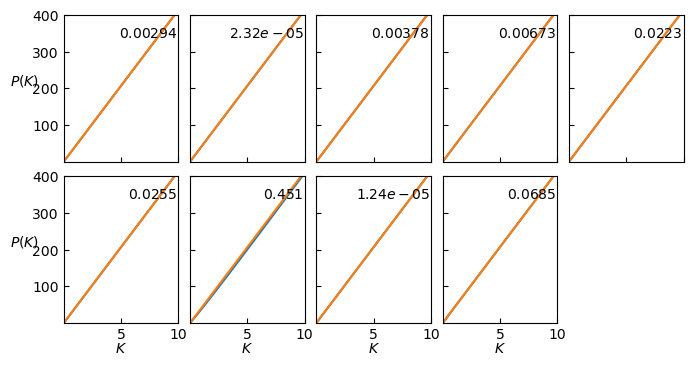

In [266]:
for ax in axs_K: ax.set_xlim(1e-6,10); ax.set_ylim(1e-5,4e2); ax.set_yscale('linear'); ax.set_xscale('linear')
fig_K

  0%|          | 0/9 [00:00<?, ?it/s]

1 0.6381138380868694
2 3.163756063349205e-05
3 0.0006124837664779697
4 0.05238010920472687
5 0.12864521387726685
6 0.2588026943231667
7 0.41450946133629324
8 8.028967850807634
9 0.0008711407760622677


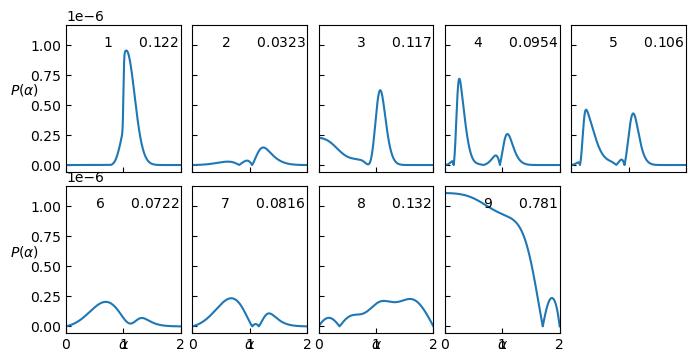

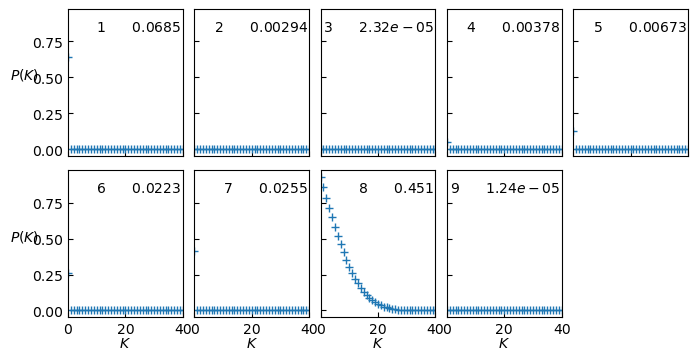

In [312]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)[:-1]
x_D = np.linspace(1e-12,1e6, 1_000_000)[:-1]

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, W1_a_point_exp, W1_K_point_exp = w1_a[exp], w1_K[exp], W1_a_point[exp], W1_K_point[exp]
    axs_a[exp].plot(x_alpha,W1_a_point_exp[1::2],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    # axs_a[exp].plot(x_alpha, dists[1],) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(#ylim=(0,4),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    print(exp+1, np.sum(W1_K_point_exp))
    # axs_K[exp].plot(x_D, dists_[1],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    axs_K[exp].plot(x_D, W1_K_point_exp[1::2],'+') # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    # axs_K[exp].set_xscale('log');axs_K[exp].set_yscale('symlog',linthresh=1e-3); axs_K[exp].set_ylim(0,6e-6);
    axs_K[exp].set_xlim(0,40);
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

  0%|          | 0/9 [00:00<?, ?it/s]

1 1.7434803483314805
2 1.0399768091833053
3 2.4609578160201013
4 1.59594308020397
5 3.5539262764565356
6 3.541478718387162
7 3.3915717572796553
8 12.337347762587944
9 6.717324890570643


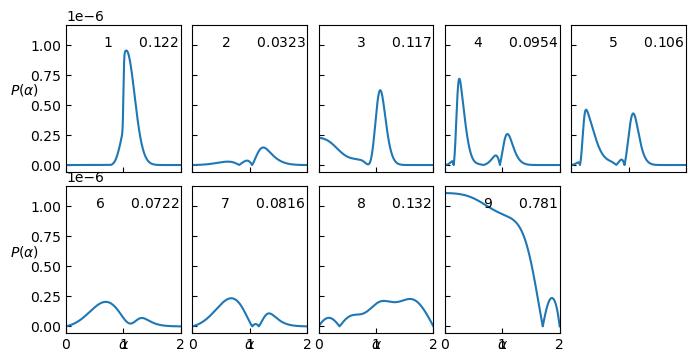

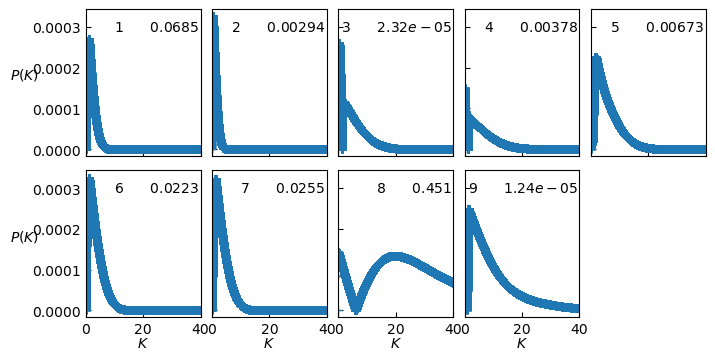

In [319]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)[:-1]
x_D = np.linspace(0,400, 1_000_000)[:-1]

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, W1_a_point_exp, W1_K_point_exp = w1_a[exp], w1_K[exp], W1_a_point[exp], W1_K_point[exp]
    axs_a[exp].plot(x_alpha,W1_a_point_exp[1::2],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    # axs_a[exp].plot(x_alpha, dists[1],) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(#ylim=(0,4),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    print(exp+1, np.sum(W1_K_point_exp))
    # axs_K[exp].plot(x_D, dists_[1],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    axs_K[exp].plot(x_D, W1_K_point_exp[1::2],'+') # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    # axs_K[exp].set_xscale('log');axs_K[exp].set_yscale('symlog',linthresh=1e-3); axs_K[exp].set_ylim(0,6e-6);
    axs_K[exp].set_xlim(0,40);
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

  0%|          | 0/9 [00:00<?, ?it/s]

1 1.7434803483314805
2 1.0399768091833053
3 2.4609578160201013
4 1.59594308020397
5 3.5539262764565356
6 3.541478718387162
7 3.3915717572796553
8 12.337347762587944
9 6.717324890570643


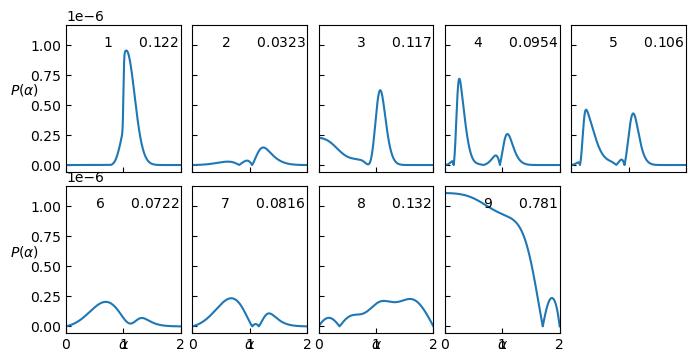

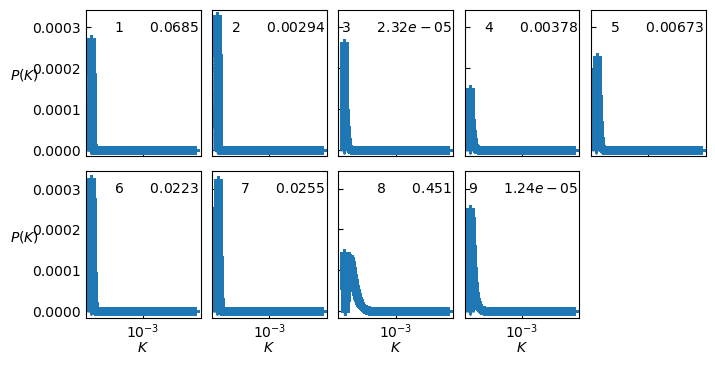

In [394]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)[:-1]
x_D = np.geomspace(1e-12,1e6, 1_000_000)[:-1]

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, W1_a_point_exp, W1_K_point_exp = w1_a[exp], w1_K[exp], W1_a_point[exp], W1_K_point[exp]
    axs_a[exp].plot(x_alpha,W1_a_point_exp[1::2],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    # axs_a[exp].plot(x_alpha, dists[1],) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(#ylim=(0,4),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)
    print(exp+1, np.sum(W1_K_point_exp))
    # axs_K[exp].plot(x_D, dists_[1],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    axs_K[exp].plot(x_D, W1_K_point_exp[1::2],'+') # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    axs_K[exp].set_xscale('log');
    # axs_K[exp].set_yscale('symlog',linthresh=1e-3); axs_K[exp].set_ylim(0,6e-6);
    # axs_K[exp].set_xlim(1,60);
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

  0%|          | 0/9 [00:00<?, ?it/s]

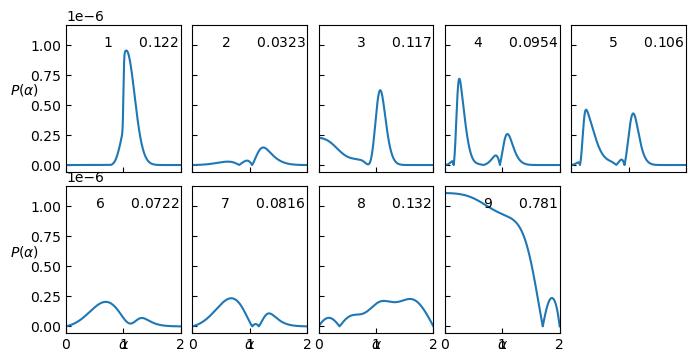

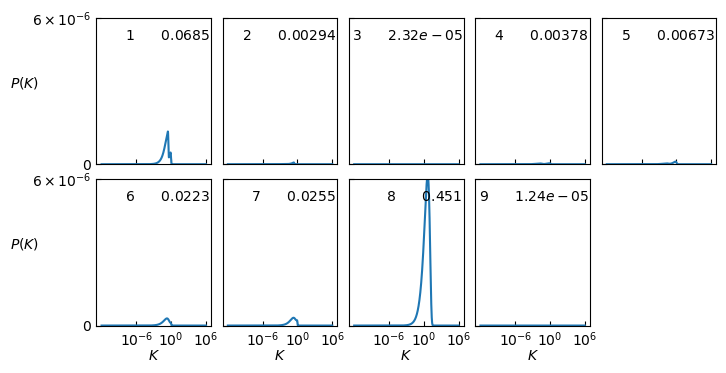

In [281]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)[:-1]
x_D = np.geomspace(1e-12,1e6, 1_000_000)[:-1]

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, W1_a_point_exp, W1_K_point_exp = w1_a[exp], w1_K[exp], W1_a_point[exp], W1_K_point[exp]
    axs_a[exp].plot(x_alpha,W1_a_point_exp[1::2],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    # axs_a[exp].plot(x_alpha, dists[1],) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(#ylim=(0,4),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)

    # axs_K[exp].plot(x_D, dists_[1],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    axs_K[exp].plot(x_D, W1_K_point_exp[1::2]) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    axs_K[exp].set_xscale('log');axs_K[exp].set_yscale('symlog',linthresh=1e-3); axs_K[exp].set_ylim(0,6e-6);
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

  0%|          | 0/9 [00:00<?, ?it/s]

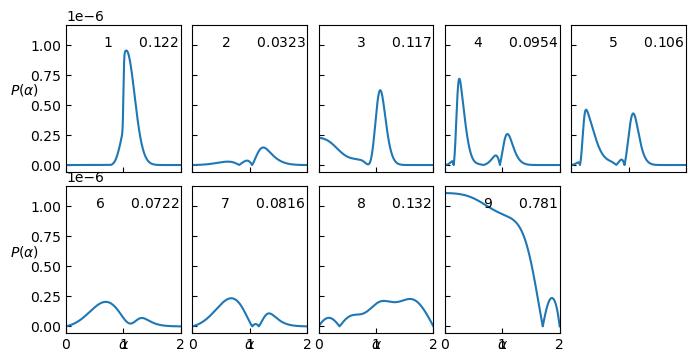

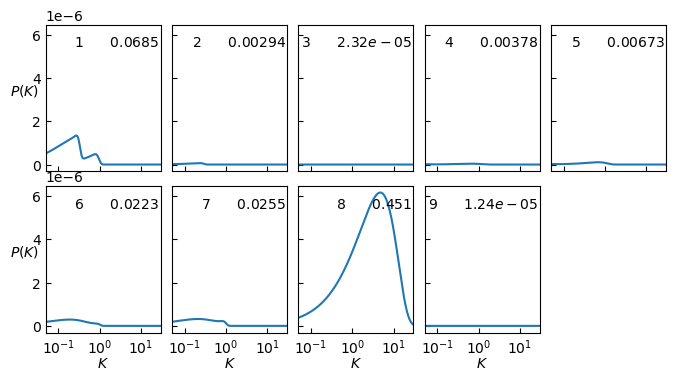

In [413]:
fig_a,axs_a = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_a[-1,-1].remove()
axs_a = axs_a.flatten()[:-1]
fig_K,axs_K = plt.subplots(2,5,figsize=(8,4), sharex=True, sharey=True,
                           gridspec_kw=dict(hspace=0.1, wspace=0.1))
axs_K[-1,-1].remove()
axs_K = axs_K.flatten()[:-1]

x_alpha = np.linspace(0,2, 1_000_000)[:-1]
x_D = np.geomspace(1e-12,1e6, 1_000_000)[:-1]

for exp in trange(N_EXP):
    distance_a_exp_, distance_d_exp_, W1_a_point_exp, W1_K_point_exp = w1_a[exp], w1_K[exp], W1_a_point[exp], W1_K_point[exp]
    axs_a[exp].plot(x_alpha,W1_a_point_exp[1::2],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[:2].T,axis=0)]));
    # plt.plot(x_alpha, dists[2], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[:2].T,axis=0)]));
    # axs_a[exp].plot(x_alpha, dists[1],) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[:2].T,axis=0)]));
    axs_a[exp].set(#ylim=(0,4),
                     xlim=(0,2));
    # axs_a[exp].set_yticks([2],['2']); axs_a[exp].set_xticks([0,2],['0','2']);
    # axs_a[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(\alpha)={distance_a_exp_:.3g}$'+ '\n'+ '\n' +r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_a[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_a_exp_:.3g}$', ha='right', transform=axs_a[exp].transAxes)

    # axs_K[exp].plot(x_D, dists_[1],) # label="True: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(true_ensemble_label[2:4].T,axis=0)]));
    # axs_K[exp].plot(x_D, dists[3], label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label[2:4].T,axis=0)]));
    axs_K[exp].plot(x_D, W1_K_point_exp[1::2]) # label="Pred: " + '; '.join([f"{mu:.3g},{np.sqrt(var):.3g}" for mu, var in np.sort(ensemble_label_[2:4].T,axis=0)]));
    axs_K[exp].set_xscale('log');#axs_K[exp].set_yscale('symlog',linthresh=1e-3); 
    #axs_K[exp].set_ylim(0,6e-6);
    axs_K[exp].set_xlim(5e-2,3e1)
    # axs_K[exp].set_yticks([1e-3,1e0,1e3],[r'$10^{-3}$',r'$10^{0}$',r'$10^{3}$']);
    # axs_K[exp].set_xticks([1e-6, 1e0, 1e6],[r'$10^{-6}$',r'$10^{0}$',r'$10^{6}$']);
    # axs_K[exp].legend(loc='upper right', title=fr'$\qquad\quad W_1(K)={distance_d_exp_:.3g}$' +'\n'+ '\n'+ r'$\qquad\qquad\qquad \mu, \sigma$', alignment='left');
    axs_K[exp].text(0.99,0.85,fr'${exp+1}\qquad {distance_d_exp_:.3g}$', ha='right', transform=axs_K[exp].transAxes)
for ax in axs_a[[0,5]]: ax.set_ylabel(r'$P(\alpha)$', rotation=0, );
for ax in axs_K[[0,5]]: ax.set_ylabel(r'$P(K)$', rotation=0, ha='right', labelpad=-5);
for ax in axs_a[-4:]: ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs_K[-4:]: ax.set_xlabel(r'$K$', labelpad=0);
for ax in axs_a:
    ax.tick_params(direction='in',)
    # ax.locator_params(nbins=1);
for ax in axs_K:
    ax.tick_params(direction='in',)
    ax.minorticks_off()

# save_plot("distro_alpha_ensemble", fig_a)
# save_plot("distro_K_log_ensemble", fig_K)

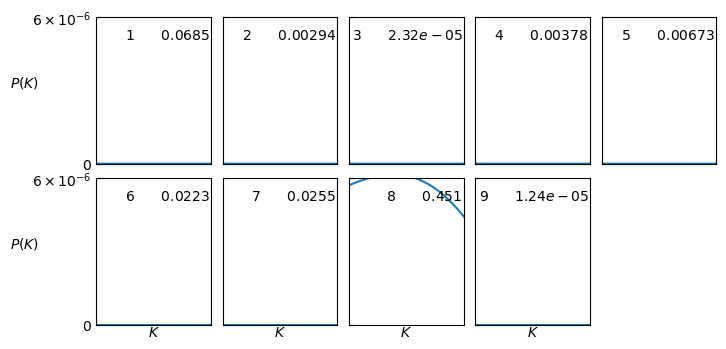

In [285]:
for ax in axs_K: ax.set_xlim(3e0,1e1)
fig_K

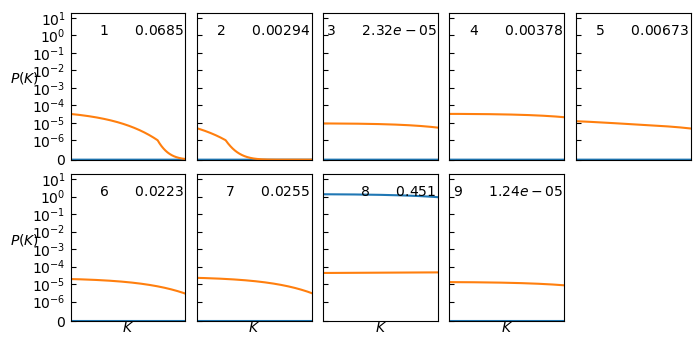

In [292]:
for ax in axs_K: ax.set_xlim(3e0,1e1)
fig_K

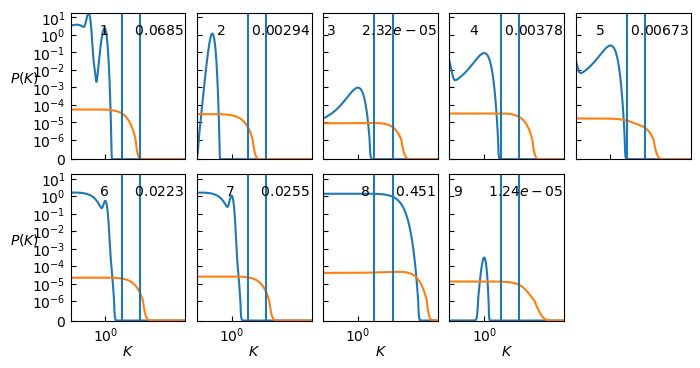

In [293]:
for ax in axs_K: ax.set_xlim(1e-1,2e2); ax.axvline(3e0);ax.axvline(1e1);
fig_K

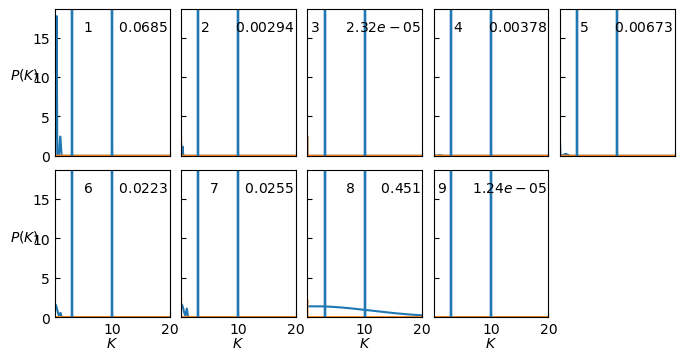

In [300]:
for ax in axs_K: ax.set_xlim(3e-6,2e1); ax.axvline(3e0);ax.axvline(1e1); ax.set_xscale('linear'); ax.set_yscale('linear')
fig_K

### Wasserstein distance at each point

In [1326]:
error_Ensemble_dataset??

Signature:
error_Ensemble_dataset(
    true_data,
    pred_data,
    size_support=1000000,
    metric='wasserstein',
    return_distributions=False,
)
Source:   
def error_Ensemble_dataset(true_data, pred_data,
                           size_support = int(1e6),
                           metric = 'wasserstein',
                           return_distributions = False):
    ''' 
    Calculates the ensemble metrics for the ANDI 2 challenge. The input are matrices of shape:
    
    | col1 (state 1) | col2 (state 2) | col3 (state 3) | ... |
    |:--------------:|:--------------:|:--------------:|:---:|
    | $\mu_a^1$      | $\mu_a^2$      | $\mu_a^3$      | ... |
    | $\sigma_a^1$   | $\sigma_a^2$   | $\sigma_a^3$   | ... |
    | $\mu_D^1$      | $\mu_D^2$      | $\mu_D^3$      | ... |        
    | $\sigma_D^1$   | $\sigma_D^2$   | $\sigma_D^3$   | ... |
    | $N_1$          | $N_2$          | $N_3$          | ... |
    
    Parameters
    ----------
    true_data : array
        Matri

In [1327]:
from scipy.stats import wasserstein_distance

In [1328]:
wasserstein_distance??

Signature: wasserstein_distance(u_values, v_values, u_weights=None, v_weights=None)
Source:   
def wasserstein_distance(u_values, v_values, u_weights=None, v_weights=None):
    r"""
    Compute the Wasserstein-1 distance between two 1D discrete distributions.

    The Wasserstein distance, also called the Earth mover's distance or the
    optimal transport distance, is a similarity metric between two probability
    distributions [1]_. In the discrete case, the Wasserstein distance can be
    understood as the cost of an optimal transport plan to convert one
    distribution into the other. The cost is calculated as the product of the
    amount of probability mass being moved and the distance it is being moved.
    A brief and intuitive introduction can be found at [2]_.

    .. versionadded:: 1.0.0

    Parameters
    ----------
    u_values : 1d array_like
        A sample from a probability distribution or the support (set of all
        possible values) of a probability distributi

In [1343]:
from scipy.stats._stats_py import _cdf_distance, _validate_distribution

In [1336]:
_cdf_distance??

Signature: _cdf_distance(p, u_values, v_values, u_weights=None, v_weights=None)
Source:   
def _cdf_distance(p, u_values, v_values, u_weights=None, v_weights=None):
    r"""
    Compute, between two one-dimensional distributions :math:`u` and
    :math:`v`, whose respective CDFs are :math:`U` and :math:`V`, the
    statistical distance that is defined as:

    .. math::

        l_p(u, v) = \left( \int_{-\infty}^{+\infty} |U-V|^p \right)^{1/p}

    p is a positive parameter; p = 1 gives the Wasserstein distance, p = 2
    gives the energy distance.

    Parameters
    ----------
    u_values, v_values : array_like
        Values observed in the (empirical) distribution.
    u_weights, v_weights : array_like, optional
        Weight for each value. If unspecified, each value is assigned the same
        weight.
        `u_weights` (resp. `v_weights`) must have the same length as
        `u_values` (resp. `v_values`). If the weight sum differs from 1, it
        must still be positive an

In [40]:
from scipy.stats._stats_py import _validate_distribution
def _cdf_distance(p, u_values, v_values, u_weights=None, v_weights=None):
    u_values, u_weights = _validate_distribution(u_values, u_weights)
    v_values, v_weights = _validate_distribution(v_values, v_weights)

    u_sorter = np.argsort(u_values)
    v_sorter = np.argsort(v_values)

    all_values = np.concatenate((u_values, v_values))
    all_values.sort(kind='mergesort')

    # Compute the differences between pairs of successive values of u and v.
    deltas = np.diff(all_values)

    # Get the respective positions of the values of u and v among the values of
    # both distributions.
    u_cdf_indices = u_values[u_sorter].searchsorted(all_values[:-1], 'right')
    v_cdf_indices = v_values[v_sorter].searchsorted(all_values[:-1], 'right')

    # Calculate the CDFs of u and v using their weights, if specified.
    if u_weights is None:
        u_cdf = u_cdf_indices / u_values.size
    else:
        u_sorted_cumweights = np.concatenate(([0],
                                              np.cumsum(u_weights[u_sorter])))
        u_cdf = u_sorted_cumweights[u_cdf_indices] / u_sorted_cumweights[-1]

    if v_weights is None:
        v_cdf = v_cdf_indices / v_values.size
    else:
        v_sorted_cumweights = np.concatenate(([0],
                                              np.cumsum(v_weights[v_sorter])))
        v_cdf = v_sorted_cumweights[v_cdf_indices] / v_sorted_cumweights[-1]

    # Compute the value of the integral based on the CDFs.
    # If p = 1 or p = 2, we avoid using np.power, which introduces an overhead
    # of about 15%.
    if p == 1:
        # return np.sum(np.multiply(np.abs(u_cdf - v_cdf), deltas))
        return np.multiply(np.abs(u_cdf - v_cdf), deltas)
def wasserstein_distance(u_values, v_values, u_weights=None, v_weights=None):
    return _cdf_distance(1, u_values, v_values, u_weights, v_weights)
def distribution_distance(p:np.array, # distribution 1
                          q:np.array, # distribution 2
                          x:np.array = None, # support of the distributions (not needed for MAE)
                          metric = 'wasserstein' # distance metric (either 'wasserstein' or 'mae')
                         )-> float:  # distance between distributions
    if metric == 'mae':
        return np.abs(p-q).mean()
    elif metric == 'wasserstein':
        return wasserstein_distance(x, x, p, q)
import scipy.stats
def multimode_dist(params, weights, bound, x, normalized = False, min_var = 1e-9):
    func = scipy.stats.truncnorm
    dist = np.zeros_like(x)
    lower, upper = bound
    # If we have single state, change values to list to still
    # have a loop:
    if isinstance(weights, float) or isinstance(weights, int):
        params = [params]
        weights = [weights]

    for param, w in zip(params, weights):
        mean, var  = param
        # introduce a cutoff to avoid nan when var = 0
        if var < min_var: var = min_var
        unimodal = func.pdf(x,
                            (lower-mean)/np.sqrt(var),
                            (upper-mean)/np.sqrt(var),
                            loc = mean,
                            scale = np.sqrt(var))
        dist += w*unimodal
    if normalized:
        dist /= np.sum(dist)
    return dist
from andi_datasets.utils_challenge import models_phenom
def error_Ensemble_dataset_(true_data, pred_data,
                           size_support = int(1e6),
                           metric = 'wasserstein',
                           return_distributions = False):
    # Define the support for the distributions
    x_alpha = np.linspace(models_phenom().bound_alpha[0],
                          models_phenom().bound_alpha[1], size_support)
    x_D = np.logspace(np.log10(models_phenom().bound_D[0]),
                      np.log10(models_phenom().bound_D[1]), size_support)

    dists = []
    for data in [true_data, pred_data]:
        if len(data.shape) > 1: # If we have more than one state
            alpha_info = np.delete(data, [2,3, -1], 0)
            d_info = data[2:-1,:]
            weights = data[-1,:]
            if weights.sum() > 1: weights /= weights.sum()
        else: # If single state
            alpha_info = data[:2]
            d_info = data[2:-1]
            weights = 1

        for idx, var in enumerate([alpha_info, d_info]):
            dists.append(multimode_dist(var.T, weights,
                                        bound  = models_phenom().bound_alpha if idx == 0 else models_phenom().bound_D, 
                                        x = x_alpha if idx == 0 else x_D))

    # Distance between alpha dists
    distance_alpha = distribution_distance(p = dists[0], q = dists[2],
                                           x = x_alpha, metric = metric)
    distance_D = distribution_distance(p = dists[1], q = dists[3],
                                       x = x_D, metric = metric)
    return distance_alpha, distance_D

In [320]:
true_ensemble_label, ensemble_label_

(array([[0.       , 1.99     ],
        [0.       , 0.01     ],
        [0.       , 1.       ],
        [0.       , 0.01     ],
        [0.5496585, 0.4503415]]),
 array([[1.62104572e+00, 1.64277140e+00, 7.07260088e-01, 1.94246664e+00,
         1.94679493e+00],
        [6.38539558e-02, 3.78275412e-02, 7.38953209e-02, 7.16438568e-03,
         3.65590267e-03],
        [1.07569732e+00, 3.98606468e-05, 2.19954151e-03, 6.42335759e+00,
         7.63872324e-05],
        [7.51048484e+01, 5.73422184e-09, 2.66057479e-04, 3.87160752e+02,
         4.01021526e-08],
        [2.20292913e-01, 4.77358478e-01, 1.00286700e-01, 8.46832387e-02,
         1.17378670e-01]]))

In [212]:
distance_a_exp_, distance_d_exp_ = error_Ensemble_dataset_(true_ensemble_label, ensemble_label_)

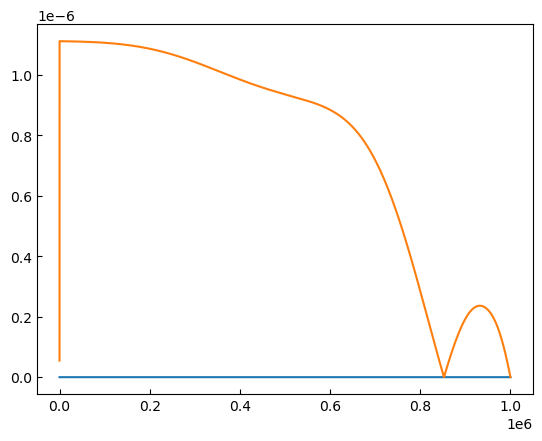

In [213]:
plt.plot(distance_a_exp_[::2]);plt.plot(distance_a_exp_[1::2]);

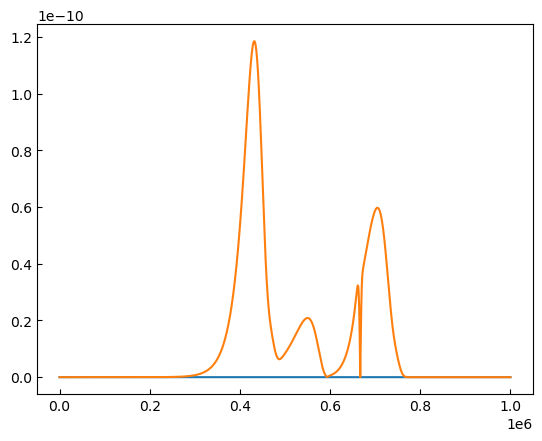

In [214]:
plt.plot(distance_d_exp_[::2]);plt.plot(distance_d_exp_[1::2]);

In [321]:
for exp in trange(1,N_EXP+1):
    true_ensemble_label = np.loadtxt(public_data_path/ "track_2" / f"exp_{exp}" / 'ensemble_labels.txt',
                                     skiprows = 1, delimiter = ';')
    path_submit = Path('../../data/submit/20250203/')  # 20240714/')  # 20240710/')  # 20240628/')
    path_results = path_submit/'res/'
    path_track = path_results / f'track_{track}/'
    path_exp = path_track/f'exp_{exp}/'
    file_name = path_exp / 'ensemble_labels.txt'
    ensemble_label_ = np.loadtxt(file_name, skiprows = 1, delimiter = ';')
    print(exp)
    print(true_ensemble_label)
    print(ensemble_label_)

  0%|          | 0/9 [00:00<?, ?it/s]

1
[[1.00000000e+00 1.00000000e+00 1.00000000e+00]
 [1.00000000e-04 1.00000000e-02 1.00000000e-02]
 [1.50000000e-01 3.30000000e-01 9.50000000e-01]
 [1.00000000e-02 1.00000000e-03 1.00000000e-02]
 [3.10425430e-01 4.73824728e-01 2.15749842e-01]]
[[1.12286262e+00 1.12010848e+00]
 [2.14715196e-02 2.01082276e-02]
 [3.74115135e-05 4.31656627e-01]
 [6.12490080e-09 6.22420359e+00]
 [6.31513850e-01 3.68486150e-01]]
2
[[1.00000000e+00 1.10000000e+00]
 [1.00000000e-01 1.00000000e-02]
 [2.80000000e-01 3.50000000e-03]
 [1.00000000e-03 1.00000000e-04]
 [7.57548591e-01 2.42451409e-01]]
[[1.04952438e+00 1.05736635e+00]
 [8.66821028e-02 9.02006197e-02]
 [1.56293953e-05 1.42577959e-01]
 [1.17301245e-09 2.26780951e+00]
 [7.11732687e-01 2.88267313e-01]]
3
[[0.         1.        ]
 [0.         0.005     ]
 [0.         1.        ]
 [0.         0.1       ]
 [0.11152176 0.88847824]]
[[1.07028150e+00 1.06228823e+00 0.00000000e+00 3.19668838e-01
  1.07420135e+00]
 [1.39663688e-02 1.59825649e-02 0.00000000e+00 2.

In [383]:
distance_d_exp

[0.06846071351971653,
 0.0029393172221742377,
 2.318591635468618e-05,
 0.0037757475859588724,
 0.006725537624652224,
 0.02226082328128671,
 0.025495401181847014,
 0.45137980560787344,
 1.235386303464281e-05]

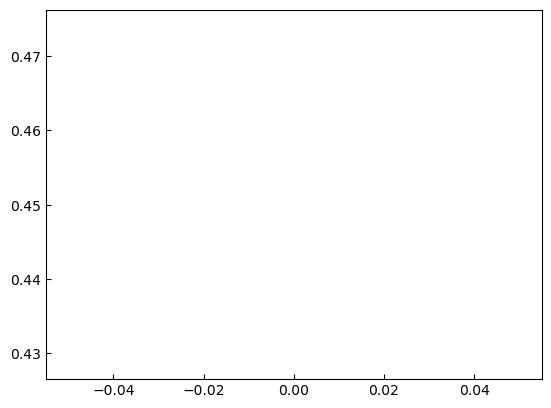

In [382]:
plt.plot(distance_d_exp[7]);

# Appendix plots

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm, trange
from tqdm.contrib import tenumerate

In [2]:
path_analysis = Path('../../data/analysis/')

In [3]:
path_results = path_analysis/ "benchmark"
with np.load(path_results/"metrics_ensemble.npz", allow_pickle=True) as f:
    w1_a=f['w1_a']; w1_K=f['w1_K']; dists=f['dists']
    W1_a_point_exp=f['W1_a_point_exp']
    W1_K_point_exp=f['W1_K_point_exp']

In [4]:
N_EXP=9

In [5]:
plt.rcParams.update({
    # 'axes.spines.right':False,
    # 'axes.spines.top':  False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    })

In [8]:
def plot_Wa(exp, axs):
    x_alpha = np.linspace(0,2, 1_000_000)
    distance_a_exp_, dists_ = w1_a[exp], dists[exp]
    W1_a_exp = np.concatenate((np.zeros(1),W1_a_point_exp[exp][1::2]))
    axs[0].plot(x_alpha, W1_a_exp, c='C2');
    axs[0].set_ylim(-1e-7,12e-7)
    axs[1].plot(x_alpha,np.cumsum(dists_[0])/np.sum(dists_[0]));
    axs[1].plot(x_alpha,np.cumsum(dists_[2])/np.sum(dists_[2]));
    axs[1].set_ylim(-0.05,1.05)
    axs[2].plot(x_alpha, dists_[0]/np.mean(dists_[0])/2,)
    axs[2].plot(x_alpha, dists_[2]/np.mean(dists_[2])/2,)
    axs[2].set_ylim(-0.1,5)
    shift = ' '*6 if exp==3 else ''
    axs[0].text(0.075,0.45, f"EXP {exp+1} {exp_model[exp]}\n"+shift+fr'${distance_a_exp_:.3g}$',
                va='bottom',ha='left', transform=axs[0].transAxes)

0it [00:00, ?it/s]

Saved ../../data/figures/W1a_distro_segment


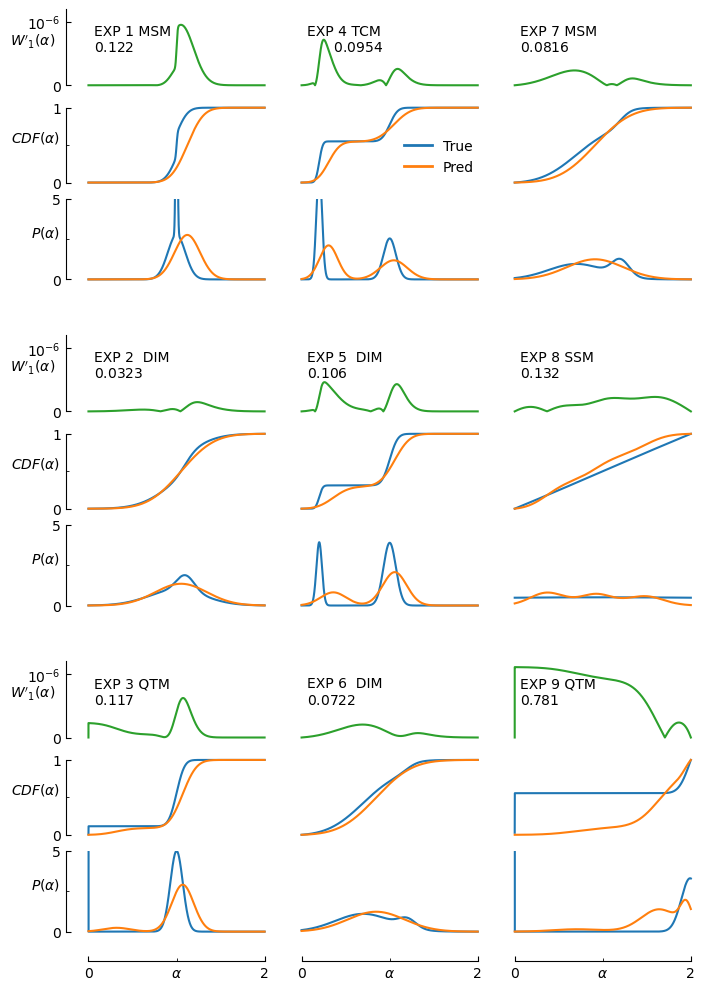

In [13]:
exp_model = ["MSM", " DIM", "QTM", "TCM", " DIM", " DIM","MSM","SSM","QTM"]
from matplotlib.lines import Line2D
legend_h = [
            # Line2D([0], [0], color='C2', marker='o',lw=0, label='Ensemble',),
            Line2D([0], [0], color='C0', label='True', lw=2, ),
            Line2D([0], [0], color='C1', label='Pred', lw=2),#marker='|', ms=15, markeredgewidth=2, lw=0, ),
           ]
fig = plt.figure(figsize=(8,12),)
# outer grid
gs0 = fig.add_gridspec(3, 3,hspace=0.2, wspace=0.1)
# inner grids
gs = np.array([gs0[i].subgridspec(3, 1, hspace=0.15) for i in [0,3,6,1,4,7,2,5,8]])
# Create all subplots for the inner grids
axs = np.array([g.subplots(sharex=True) for g in gs]) # 9,3
# populate the subplots
for i,axs_ in tqdm(enumerate(axs)): plot_Wa(i,axs_);
# edit all axes
# for ax in axs.flatten(): ax.set_axis_off();

# Hide all unnecesary spines
for ax in axs[[3,4,6,7]].flatten(): ax.set_axis_off()
# last row
for ax in axs[[2,5,8],:-1].flatten():
    ax.spines[['bottom','left','right', 'top']].set_visible(False)
    ax.tick_params(which='both',left=False,labelleft=False, bottom=False, labelbottom=False)
for ax in axs[[2,5,8],-1].flatten():
    ax.spines[['left','right', 'top']].set_visible(False)
    ax.tick_params(which='both',left=False,labelleft=False)
    # Disjoin bottom spine by moving it outwards
    ax.spines['bottom'].set_position(('outward', 20))
    ax.spines['bottom'].set_bounds(0,2)
    ax.set_xticks(ticks=[0,2], labels=['0', '2'])
    ax.set_xticks(ticks=[1], labels=[], minor=True)
    ax.set_xlabel(r'$\alpha$', labelpad=-10);
for ax in axs[2,:]:
    ax.spines['left'].set_visible(True)
# first column
for ax in axs[[0,1,2]]:
    for a in ax:
        a.spines[['bottom','right', 'top']].set_visible(False)
        a.tick_params(which='both',bottom=False,labelbottom=False,left=True, labelleft=True,)
        a.spines['left'].set_position(('outward', 10))
    ax[0].spines['left'].set_bounds(0,12e-7)
    ax[1].spines['left'].set_bounds(0,1)
    ax[2].spines['left'].set_bounds(0,5)
    ax[0].set_yticks(ticks=[0,1e-6], labels=['0',r'$10^{-6}$'])
    ax[1].set_yticks(ticks=[0,1])
    ax[2].set_yticks(ticks=[0,5])
    # ax[0].set_yticks(ticks=[1e-3], labels=[], minor=True)
    ax[1].set_yticks(ticks=[.5], labels=[], minor=True)
    ax[2].set_yticks(ticks=[2.5], labels=[], minor=True)
    ax[0].set_ylabel(r"$W'_1(\alpha)$", rotation=0, labelpad=-20, ha='right');
    ax[1].set_ylabel(r'$CDF(\alpha)$', rotation=0, labelpad=-6, ha='right');
    ax[2].set_ylabel(r'$P(\alpha)$', rotation=0, labelpad=-6, ha='right');
# bottomleft corner
for ax in [axs[2,-1]]:
    ax.spines['bottom'].set_visible(True)
    ax.tick_params(which='both',bottom=True,labelbottom=True,left=True, labelleft=True,)

axs[3,1].legend(handles=legend_h, loc='lower right', frameon=False, );
#save_plot("W1a_distro_segment", fig)

In [14]:
def plot_WK(exp, axs):
    x_D = np.geomspace(1e-12,1e6, 1_000_000)
    distance_d_exp_, dists_ =  w1_K[exp], dists[exp]
    W1_K_exp = np.concatenate((np.zeros(1),W1_K_point_exp[exp][1::2]))
    axs[0].plot(x_D, W1_K_exp, c='C2');
    axs[0].set_ylim(-1e-8,33e-8)
    axs[1].plot(x_D,np.cumsum(dists_[1])/np.sum(dists_[1]));
    axs[1].plot(x_D,np.cumsum(dists_[3])/np.sum(dists_[3]));
    axs[1].set_ylim(-0.05,1.05)
    axs[2].plot(x_D,dists_[1]/np.mean(dists_[1]),)
    axs[2].plot(x_D, dists_[3]/np.mean(dists_[3]),)
    axs[2].set_ylim(-0.1,2.6)
    d = fr'${distance_d_exp_*1e5:.3g}\cdot 10^{-5}$' if exp in [2,8] else fr'${distance_d_exp_:.3g}$'
    axs[0].text(0.075,0.45, f"EXP {exp+1} {exp_model[exp]}\n"+d,
                va='bottom',ha='left', transform=axs[0].transAxes)
    for ax in axs: ax.set_xscale('log')

0it [00:00, ?it/s]

Saved ../../data/figures/W1K_distro_segment


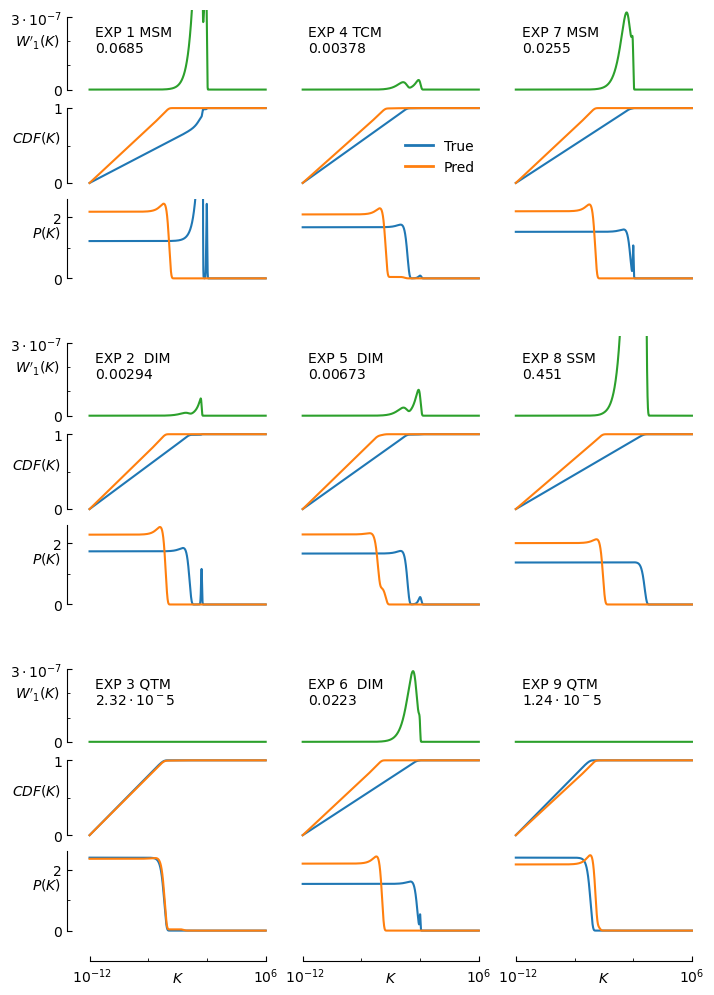

In [15]:
exp_model = ["MSM", " DIM", "QTM", "TCM", " DIM", " DIM","MSM","SSM","QTM"]
from matplotlib.lines import Line2D
legend_h = [
            # Line2D([0], [0], color='C2', marker='o',lw=0, label='Ensemble',),
            Line2D([0], [0], color='C0', label='True', lw=2, ),
            Line2D([0], [0], color='C1', label='Pred', lw=2),#marker='|', ms=15, markeredgewidth=2, lw=0, ),
           ]
fig = plt.figure(figsize=(8,12),)
# outer grid
gs0 = fig.add_gridspec(3, 3,hspace=0.2, wspace=0.1)
# inner grids
gs = np.array([gs0[i].subgridspec(3, 1, hspace=0.15) for i in [0,3,6,1,4,7,2,5,8]])
# Create all subplots for the inner grids
axs = np.array([g.subplots(sharex='col') for g in gs]) # 9,3
# populate the subplots
for i,axs_ in tqdm(enumerate(axs)): plot_WK(i,axs_);
# edit all axes
# for ax in axs.flatten(): ax.set_axis_off();

# Hide all unnecesary spines
for ax in axs[[3,4,6,7]].flatten(): ax.set_axis_off()
# last row
for ax in axs[[2,5,8],:-1].flatten():
    ax.spines[['bottom','left','right', 'top']].set_visible(False)
    ax.tick_params(which='both',left=False,labelleft=False,bottom=False, labelbottom=False)
for ax in axs[[2,5,8],-1]:
    ax.spines[['left','right', 'top']].set_visible(False)
    ax.tick_params(which='both',left=False,labelleft=False,)
    # Disjoin bottom spine by moving it outwards
    ax.spines['bottom'].set_position(('outward', 20))
    ax.spines['bottom'].set_bounds(1e-12,1e6)
    ax.set_xticks(ticks=[1e-12,1e6], labels=[r' $10^{-12}$', r'$10^{6}$'])
    ax.set_xticks(ticks=[1e-6, 1e0], labels=[], minor=True)
    ax.set_xlabel(r'$K$', labelpad=-10);
for ax in axs[2,:]:        ax.spines['left'].set_visible(True)
# first column
for ax in axs[[0,1,2]]:
    for a in ax:
        a.spines[['bottom','right', 'top']].set_visible(False)
        a.tick_params(which='both',bottom=False,labelbottom=False,left=True, labelleft=True,)
        a.spines['left'].set_position(('outward', 10))
    ax[0].spines['left'].set_bounds(0,3e-7)
    ax[1].spines['left'].set_bounds(0,1)
    ax[2].spines['left'].set_bounds(0,2.6)
    ax[0].set_yticks(ticks=[0,3e-7], labels=['0',r'$3\cdot 10^{-7}$'])
    ax[1].set_yticks(ticks=[0,1])
    ax[2].set_yticks(ticks=[0,2])
    ax[0].set_yticks(ticks=[1e-7,2e-7], labels=[], minor=True)
    ax[1].set_yticks(ticks=[.5], labels=[], minor=True)
    ax[2].set_yticks(ticks=[1], labels=[], minor=True)
    ax[0].set_ylabel(r"$W'_1(K)$", rotation=0, labelpad=-36, ha='right');
    ax[1].set_ylabel(r'$CDF(K)$', rotation=0, labelpad=-6, ha='right');
    ax[2].set_ylabel(r'$P(K)$', rotation=0, labelpad=-6, ha='right');
# bottomleft corner
for ax in [axs[2,-1]]:
    ax.spines['bottom'].set_visible(True)
    ax.tick_params(which='both',bottom=True,labelbottom=True,left=True, labelleft=True,)

axs[3,1].legend(handles=legend_h, loc='lower right', frameon=False, );
#save_plot("W1K_distro_segment", fig)